# Curriculum 2: effect of long-term training rollout 

# Pendulum

## Metrics

In [4]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from networks import *
from forecasters import * 
import seaborn as sns

In [1]:
def compute_metrics(data, compute_phy=True, eps=0.01):
    data["y_true"] = data["y_true"].apply(lambda x: np.array(x))
    data["y_pred"] = data["y_pred"].apply(lambda x: np.array(x))
    #data = compute_trajectories(F_model, y0_list, dt=0.5, t1=400)
    data["L1"] = data.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
    data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
    data["L2_20s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:41] - x["y_pred"][:,:41])**2)), axis=1)
    data["L2_40s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:81] - x["y_pred"][:,:81])**2)), axis=1)
    data["L2_50s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:101] - x["y_pred"][:,:101])**2)), axis=1)
    data["L2_100s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:201] - x["y_pred"][:,:201])**2)), axis=1)
    data["stationary_index"] = data.apply(lambda x: np.where((np.abs(np.array(x["y_true"][1,::-1])).cumsum()[::-1] > eps)==False)[0][0], axis=1)
    max_stat = data["stationary_index"].max()
    data["L2_stationary"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:max_stat] - x["y_pred"][:,:max_stat])**2)), axis=1)
    data["L2_dynamic"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:x["stationary_index"]] - x["y_pred"][:,:x["stationary_index"]])**2)), axis=1)
    data["p_inf_true"] = data.apply(lambda x: x["y_true"][1,-1:], axis=1)
    data["p_inf_pred"] = data.apply(lambda x: x["y_pred"][1,-1:], axis=1)
    data["q_inf_true"] = data.apply(lambda x: x["y_true"][0,-1:], axis=1)
    data["q_inf_pred"] = data.apply(lambda x: x["y_pred"][0,-1:], axis=1)
    data["p_inf_pred_mean"] = data.apply(lambda x: np.mean(np.abs(x["y_pred"][1,-20:])), axis=1)
    data["p_inf_true_mean"] = data.apply(lambda x: np.mean(np.abs(x["y_true"][1,-20:])), axis=1)
    data["q_inf_pred_mean"] = data.apply(lambda x: np.mean(x["y_pred"][0,-20:]), axis=1)
    data["q_inf_true_mean"] = data.apply(lambda x: np.mean(x["y_true"][0,-20:]), axis=1)

    if compute_phy:
        # "max" is where p changes sign for the first time
        p_lim_true = data.apply(lambda x: np.where(np.sign(x["y_true"][1,:-1]) - np.sign(x["y_true"][1,1:]) != 0)[0][0], axis=1)
        p_lim_pred = data.apply(lambda x: np.where(np.sign(x["y_pred"][1,:-1]) - np.sign(x["y_pred"][1,1:]) != 0)[0][0], axis=1)
        data["p_lim_true"] = p_lim_true
        data["p_lim_pred"] = p_lim_pred
        #print(p_lim_true.max(), p_lim_pred.max())
        data["q_max_pred"] = data.apply(lambda x: x["y_pred"][0,x["p_lim_pred"]], axis=1)
        data["q_max_true"] = data.apply(lambda x: x["y_true"][0,x["p_lim_true"]], axis=1)
        #data["q_max_pred"] = data.apply(lambda x: np.max(np.abs(x["y_pred"][0,1:])), axis=1)
        #data["q_max_true"] = data.apply(lambda x: np.max(np.abs(x["y_true"][0,1:])), axis=1)
        data["q_inf_modulo2pi_pred"] = data.apply(lambda x: min(np.abs(x["q_inf_pred"]%(2*np.pi)), np.abs(x["q_inf_pred"]%(-2*np.pi))), axis=1)
        data["q_inf_modulo2pi_true"] = data.apply(lambda x: min(np.abs(x["q_inf_true"]%(2*np.pi)), np.abs(x["q_inf_true"]%(-2*np.pi))), axis=1)
        data["pred_isphysical"] = np.abs(data["q_inf_pred"]-data["q_max_pred"]) < np.pi
        data["true_isphysical"] = np.abs(data["q_inf_true"]-data["q_max_true"]) < np.pi
    return data

In [3]:
from datasets import * 
import os

In [166]:
# test on T=40 trajectories ie test set of pendulum T=40
from datasets import * 
import os
path = 'data/pendulum_curriculum'
dataset_name = 'pendulum'
data_integration_method = 'RK4'
duration = 40
dt_num = 0.5
_, _, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(path, dataset_name+str(duration)), dt_num=dt_num, duration=duration)

In [150]:
def get_y_states40s(test=test):
    y_list = []
    for i,data in enumerate(test):
        states = jnp.array(data['states'])
        for j in range(states.shape[2]):
            y_list.append(states[0,:,j])
        # if i == 24:
        #     break
    y_list = np.array(y_list)
    print(y_list.shape, y_list[0].shape)
    return y_list

y_40s = get_y_states40s(test)

(16200, 2) (2,)


In [151]:
def get_y_states40s_pred(data):
    y_list = []
    for i in range(len(data)):
        pred_states = data["y_pred"][i]
        for j in range(81):
            y_list.append(pred_states[:,j])
    y_list = np.array(y_list)
    return y_list

In [4]:
def make_jacobian_norm_fn(model):
    """Returns a batched, JIT-compiled function to compute Jacobian norms."""
    # JIT compile jacobian computation
    jac_fn = jax.jit(jax.jacfwd(model))

    def jacobian_norm(y0):
        return jnp.linalg.norm(jac_fn(y0))

    return jax.vmap(jacobian_norm)  # vectorized over batch of y0

def compute_jacobian_test(model, y, bool_true=False):
    if bool_true:
        jacobian_norms_fn = make_jacobian_norm_fn(model)
    else:
        jacobian_norms_fn = make_jacobian_norm_fn(model.model_aug)
    return jacobian_norms_fn(y)  # y shape: (N, features)

In [163]:
def load_model_40s(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, data_integration_method="RK4", dt_num=0.5, duration=40):
    """Compute trajectory losses and Fa loss for a given model, on its duration of training data."""
    # load test data 
    _, _, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(data_path, dataset_name+str(duration)), dt_num=dt_num, duration=duration)

    # load model
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        hyperparameters_dict = json.load(f)
    min_op = hyperparameters_dict['min_op']
    dt = hyperparameters_dict["dt"]
    dt_factor = int(dt/test.dataset.dt)
    print(dt, dt_factor)
    if dataset_name == 'pendulum':
        if model_phy_option == 'true': # true damped pendulum
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params, is_true=True)
        elif model_phy_option == 'complete': # damped pendulum
            model_phy = PendulumParamPDE(is_damped=True)
        else: 
            model_phy = PendulumParamPDE(is_damped=False)
    
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt,
                num_steps=int(test.dataset.num_steps/dt_factor),
                integration_method=integration_method, # error scheme exp
            )
            model = eqx.tree_deserialise_leaves(f, net)
    elif dataset_name == "lorenz":
        model_phy = None # Neural ODE 
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey, ikey = jax.random.split(jax.random.PRNGKey(0))
            model_aug = MLP(key=mkey, state_c=3, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt_factor * test.dataset.dt, # enabling comparison with GT for error scheme experiment 
                num_steps=int(test.dataset.num_steps / dt_factor), 
                integration_method=integration_method, # RK2 for error scheme experiment
            )
            model = eqx.tree_deserialise_leaves(f, net)
    return model

## Load data and models

In [2]:
path_5_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_5_54_e0f4gs2q/model_1.509e-03_longrun_200.json"

In [3]:
path_10 = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_10_7_wni7d7vw/model_4.474e-03.json"
path_10_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_10_7_wni7d7vw/model_4.474e-03_longrun.json"
path_15_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_15_11_tuagzu2h/model_8.605e-03_longrun.json"
path_20_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_20_3_7r3pt5i6/model_7.232e-03_longrun.json"
path_25_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_25_15_mwuh5fu7/model_5.600e-03_longrun.json"
path_30_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_30_19_1px44q94/model_4.379e-03_longrun.json"
path_35_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_35_23_dvo9pd8k/model_3.710e-03_longrun.json"
path_40_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_40_30_2mrv9dnr/model_3.301e-03_longrun.json"
path_50_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_aug_50_34_26unnadg/model_2.637e-03_longrun.json"


In [153]:
path_10_lipsupX_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_10_42_tuhrn6ch/model_4.911e-03_longrun.json"
path_20_lipsupX_long_l1000 = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_20_35_stgfld1q/model_9.422e-03_longrun.json"
#path_20_lipsupX_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_20_36_ddvssrzw/model_3.826e-03_longrun.json"
#path_20_lipsupX_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_20_37_l71dirtf/model_6.073e-03_longrun.json"
path_20_lipsupX_long ="/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_20_38_e32f6kk3/model_3.211e-03_longrun.json"
#path_20_lipsupX_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_20_40_mji7rtrw/model_6.262e-03_longrun.json"
path_25_lipsupX_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_25_43_l64do47n/model_3.125e-03_longrun.json"
path_30_lipsupX_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_30_41_azh5fjat/model_2.338e-03_longrun.json"
path_40_lipsupX_long = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_40_39_p089jjoy/model_1.758e-03_longrun.json"
path_40_lipsupX_long_l10_tau10 = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_40_47_wuwh8czs/model_1.552e-03_longrun.json"
path_20_lipsupX_long_l10_tau10 = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_prime_supX_aug_20_48_y401ldbf/model_4.090e-03_longrun.json"

In [154]:
path_20_aph_long_l10_tau10 = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_aug_20_44_x5syrqwn/model_1.341e-02_longrun.json"
path_40_aph_long_l10_tau10 = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_aug_40_46_msaprmil/model_4.450e-03_longrun.json"
path_20_aph_long_l100 = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_aug_20_45_y2asmpno/model_3.839e-02_longrun.json"
path_40_aph_long_l100 = "/Users/mayajanvier/jax-phynity/data/pendulum_curriculum/none_Fa_aug_40_49_vfcnhnan/model_1.920e-02_longrun.json"

In [6]:
durations = [10, 15, 20, 25, 30, 35, 40, 50]
results5 = pd.read_json(path_5_long).T
results10 = pd.read_json(path_10).T
results10_long = pd.read_json(path_10_long).T
results15_long = pd.read_json(path_15_long).T
results20_long = pd.read_json(path_20_long).T
results25_long = pd.read_json(path_25_long).T
results30_long = pd.read_json(path_30_long).T
results35_long = pd.read_json(path_35_long).T
results40_long = pd.read_json(path_40_long).T
results50_long = pd.read_json(path_50_long).T

In [157]:
results10_lipsupX_long = pd.read_json(path_10_lipsupX_long).T
results20_lipsupX_long = pd.read_json(path_20_lipsupX_long).T
results25_lipsupX_long = pd.read_json(path_25_lipsupX_long).T
results30_lipsupX_long = pd.read_json(path_30_lipsupX_long).T
results40_lipsupX_long = pd.read_json(path_40_lipsupX_long).T
results40_lipsupX_long_l10_tau10 = pd.read_json(path_40_lipsupX_long_l10_tau10).T
results20_lipsupX_long_l10_tau10 = pd.read_json(path_20_lipsupX_long_l10_tau10).T
results20_lipsupX_long_l1000 = pd.read_json(path_20_lipsupX_long_l1000).T

In [158]:
results20_aph_long_l10_tau10 = pd.read_json(path_20_aph_long_l10_tau10).T
results40_aph_long_l10_tau10 = pd.read_json(path_40_aph_long_l10_tau10).T
results20_aph_long_l100 = pd.read_json(path_20_aph_long_l100).T
results40_aph_long_l100 = pd.read_json(path_40_aph_long_l100).T

In [196]:
data_none_aug5 = compute_metrics(results5, compute_phy=False)


In [7]:
data_none_aug10 = compute_metrics(results10_long, compute_phy=False)
data_none_aug15 = compute_metrics(results15_long, compute_phy=False)
data_none_aug20 = compute_metrics(results20_long, compute_phy=False)
data_none_aug25 = compute_metrics(results25_long, compute_phy=False)
data_none_aug30 = compute_metrics(results30_long, compute_phy=False)
data_none_aug35 = compute_metrics(results35_long, compute_phy=False)
data_none_aug40 = compute_metrics(results40_long, compute_phy=False)
data_none_aug50 = compute_metrics(results50_long, compute_phy=False)

In [160]:
data_fa_prime_supX10 = compute_metrics(results10_lipsupX_long, compute_phy=False)
data_fa_prime_supX20 = compute_metrics(results20_lipsupX_long, compute_phy=False)
data_fa_prime_supX25 = compute_metrics(results25_lipsupX_long, compute_phy=False)
data_fa_prime_supX30 = compute_metrics(results30_lipsupX_long, compute_phy=False)
data_fa_prime_supX40 = compute_metrics(results40_lipsupX_long, compute_phy=False)
data_fa_prime_supX40_l10_tau10 = compute_metrics(results40_lipsupX_long_l10_tau10, compute_phy=False)
data_fa_prime_supX20_l10_tau10 = compute_metrics(results20_lipsupX_long_l10_tau10, compute_phy=False)
data_fa_prime_supX20_l1000 = compute_metrics(results20_lipsupX_long_l1000, compute_phy=False)

In [161]:
data_aph_20_l10_tau10 = compute_metrics(results20_aph_long_l10_tau10, compute_phy=False)
data_aph_40_l10_tau10 = compute_metrics(results40_aph_long_l10_tau10, compute_phy=False)
data_aph_20_l100 = compute_metrics(results20_aph_long_l100, compute_phy=False)
data_aph_40_l100 = compute_metrics(results40_aph_long_l100, compute_phy=False)

In [234]:
model_none_aug5 = load_model_40s("model_1.509e-03.eqx", "none_aug_5_54_e0f4gs2q", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5)

data/pendulum_curriculum/none_aug_5_54_e0f4gs2q/model_1.509e-03.eqx
0.5 1


In [167]:
model_none_aug10 = load_model_40s("model_4.474e-03.eqx", "none_aug_10_7_wni7d7vw", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5)
model_none_aug15 = load_model_40s("model_8.605e-03.eqx", "none_aug_15_11_tuagzu2h", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5)
model_none_aug20 = load_model_40s("model_7.232e-03.eqx", "none_aug_20_3_7r3pt5i6", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5)
model_none_aug25 = load_model_40s("model_5.600e-03.eqx", "none_aug_25_15_mwuh5fu7", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5)
model_none_aug30 = load_model_40s("model_4.379e-03.eqx", "none_aug_30_19_1px44q94", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5)
model_none_aug35 = load_model_40s("model_3.710e-03.eqx", "none_aug_35_23_dvo9pd8k", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5)
model_none_aug40 = load_model_40s("model_3.301e-03.eqx", "none_aug_40_30_2mrv9dnr", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5)
model_none_aug50 = load_model_40s("model_2.637e-03.eqx", "none_aug_50_34_26unnadg", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5)

data/pendulum_curriculum/none_aug_10_7_wni7d7vw/model_4.474e-03.eqx
0.5 1
data/pendulum_curriculum/none_aug_15_11_tuagzu2h/model_8.605e-03.eqx
0.5 1
data/pendulum_curriculum/none_aug_20_3_7r3pt5i6/model_7.232e-03.eqx
0.5 1
data/pendulum_curriculum/none_aug_25_15_mwuh5fu7/model_5.600e-03.eqx
0.5 1
data/pendulum_curriculum/none_aug_30_19_1px44q94/model_4.379e-03.eqx
0.5 1
data/pendulum_curriculum/none_aug_35_23_dvo9pd8k/model_3.710e-03.eqx
0.5 1
data/pendulum_curriculum/none_aug_40_30_2mrv9dnr/model_3.301e-03.eqx
0.5 1
data/pendulum_curriculum/none_aug_50_34_26unnadg/model_2.637e-03.eqx
0.5 1


In [168]:
model_lipsupX10 = load_model_40s("model_4.911e-03.eqx", "none_Fa_prime_supX_aug_10_42_tuhrn6ch", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
model_lipsupX20_l1000 = load_model_40s("model_9.422e-03.eqx", "none_Fa_prime_supX_aug_20_35_stgfld1q", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
#model_lipsupX20 = load_model_40s("model_3.826e-03.eqx", "none_Fa_prime_supX_aug_20_36_ddvssrzw", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
#model_lipsupX20 = load_model_40s("model_6.073e-03.eqx", "none_Fa_prime_supX_aug_20_37_l71dirtf", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
model_lipsupX20 = load_model_40s("model_3.211e-03.eqx", "none_Fa_prime_supX_aug_20_38_e32f6kk3", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
#model_lipsupX20 = load_model_40s("model_6.262e-03.eqx", "none_Fa_prime_supX_aug_20_40_mji7rtrw", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
model_lipsupX25 = load_model_40s("model_3.125e-03.eqx", "none_Fa_prime_supX_aug_25_43_l64do47n", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
model_lipsupX30 = load_model_40s("model_2.338e-03.eqx", "none_Fa_prime_supX_aug_30_41_azh5fjat", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
model_lipsupX40 = load_model_40s("model_1.758e-03.eqx", "none_Fa_prime_supX_aug_40_39_p089jjoy", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
model_lipsupX40_l10_tau10 = load_model_40s("model_1.552e-03.eqx", "none_Fa_prime_supX_aug_40_47_wuwh8czs", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)
model_lipsupX20_l10_tau10 = load_model_40s("model_4.090e-03.eqx", "none_Fa_prime_supX_aug_20_48_y401ldbf", "data/pendulum_curriculum", "none_Fa_prime_supX", True, "pendulum", "RK4", dt_num=0.5)

data/pendulum_curriculum/none_Fa_prime_supX_aug_10_42_tuhrn6ch/model_4.911e-03.eqx
0.5 1
data/pendulum_curriculum/none_Fa_prime_supX_aug_20_35_stgfld1q/model_9.422e-03.eqx
0.5 1
data/pendulum_curriculum/none_Fa_prime_supX_aug_20_38_e32f6kk3/model_3.211e-03.eqx
0.5 1
data/pendulum_curriculum/none_Fa_prime_supX_aug_25_43_l64do47n/model_3.125e-03.eqx
0.5 1
data/pendulum_curriculum/none_Fa_prime_supX_aug_30_41_azh5fjat/model_2.338e-03.eqx
0.5 1
data/pendulum_curriculum/none_Fa_prime_supX_aug_40_39_p089jjoy/model_1.758e-03.eqx
0.5 1
data/pendulum_curriculum/none_Fa_prime_supX_aug_40_47_wuwh8czs/model_1.552e-03.eqx
0.5 1
data/pendulum_curriculum/none_Fa_prime_supX_aug_20_48_y401ldbf/model_4.090e-03.eqx
0.5 1


In [169]:
model_aph_20_l10_tau10 = load_model_40s("model_1.341e-02.eqx", "none_Fa_aug_20_44_x5syrqwn", "data/pendulum_curriculum", "none_Fa", True, "pendulum", "RK4", dt_num=0.5)
model_aph_40_l10_tau10 = load_model_40s("model_4.450e-03.eqx", "none_Fa_aug_40_46_msaprmil", "data/pendulum_curriculum", "none_Fa", True, "pendulum", "RK4", dt_num=0.5)
model_aph_20_l100 = load_model_40s("model_3.839e-02.eqx", "none_Fa_aug_20_45_y2asmpno", "data/pendulum_curriculum", "none_Fa", True, "pendulum", "RK4", dt_num=0.5)
model_aph_40_l100 = load_model_40s("model_1.920e-02.eqx", "none_Fa_aug_40_49_vfcnhnan", "data/pendulum_curriculum", "none_Fa", True, "pendulum", "RK4", dt_num=0.5)

data/pendulum_curriculum/none_Fa_aug_20_44_x5syrqwn/model_1.341e-02.eqx
0.5 1
data/pendulum_curriculum/none_Fa_aug_40_46_msaprmil/model_4.450e-03.eqx
0.5 1
data/pendulum_curriculum/none_Fa_aug_20_45_y2asmpno/model_3.839e-02.eqx
0.5 1
data/pendulum_curriculum/none_Fa_aug_40_49_vfcnhnan/model_1.920e-02.eqx
0.5 1


## Trajectories

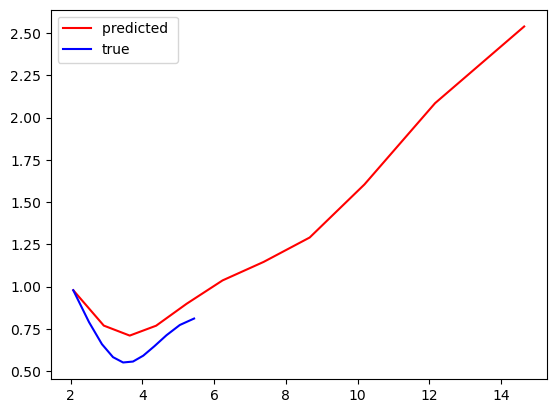

In [230]:
#k = data_none_aug5["L2_20s"].idxmax() # worst traj
k=136 # inf l2
k=167 # fine
k=129 #nan l2
time = 11
plt.plot(data_none_aug5["y_pred"][k][0,:time], data_none_aug5["y_pred"][k][1,:time], label=f"predicted ", color="red")
plt.plot(data_none_aug5["y_true"][k][0,:time], data_none_aug5["y_true"][k][1,:time], label=f"true", color="blue")
plt.legend()
#print(data_none_aug5["L2_20s"][k])



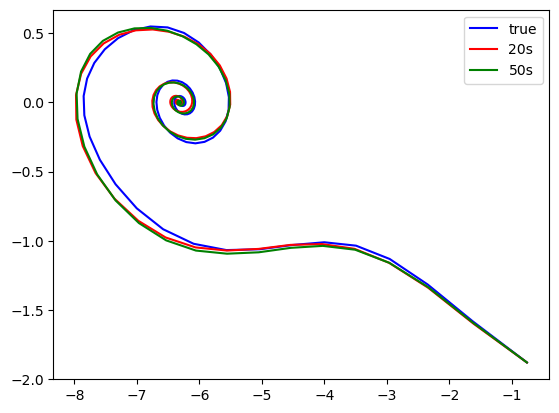

In [11]:
k=198
plt.plot(data_none_aug50["y_true"][k][0,:], data_none_aug50["y_true"][k][1,:], color="blue", label="true")

plt.plot(data_none_aug20["y_pred"][k][0,:], data_none_aug20["y_pred"][k][1,:], color="red", label="20s")
plt.plot(data_none_aug50["y_pred"][k][0,:], data_none_aug50["y_pred"][k][1,:], color="green", label="50s")
plt.legend()

In [227]:
type(data_none_aug5["y_pred"][k][0,0])
np.isinf(data_none_aug5["y_pred"][k][0,:]).any()

TypeError: isinf() got an unexpected keyword argument 'equal_nan'

9.310396687741868
17.843388359163058


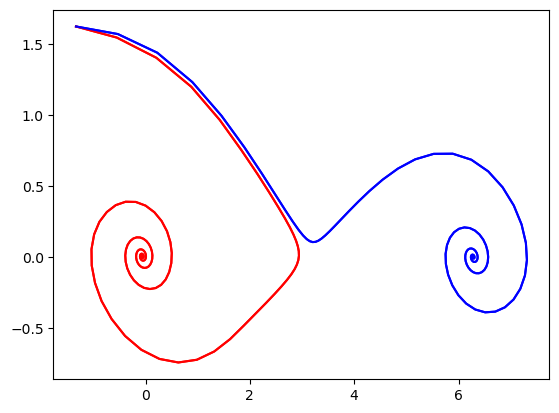

In [184]:
k = data_none_aug10["L2_20s"].idxmax() # worst traj
plt.plot(data_none_aug10["y_pred"][k][0,:], data_none_aug10["y_pred"][k][1,:], label=f"predicted ", color="red")
plt.plot(data_none_aug10["y_true"][k][0,:], data_none_aug10["y_true"][k][1,:], label=f"true", color="blue")
print(data_none_aug10["L2_20s"][k])

k = data_none_aug10["L2_100s"].idxmax() # worst traj
plt.plot(data_none_aug10["y_pred"][k][0,:], data_none_aug10["y_pred"][k][1,:], label=f"predicted ", color="red")
plt.plot(data_none_aug10["y_true"][k][0,:], data_none_aug10["y_true"][k][1,:], label=f"true", color="blue")
print(data_none_aug10["L2_100s"][k])

## MSE on dynamic trajectories ($\epsilon$=0.01)

MSE on trajectories, duration of each trajectories is "dynamic", we evaluate pu until the index where true $p \leq 0.01$

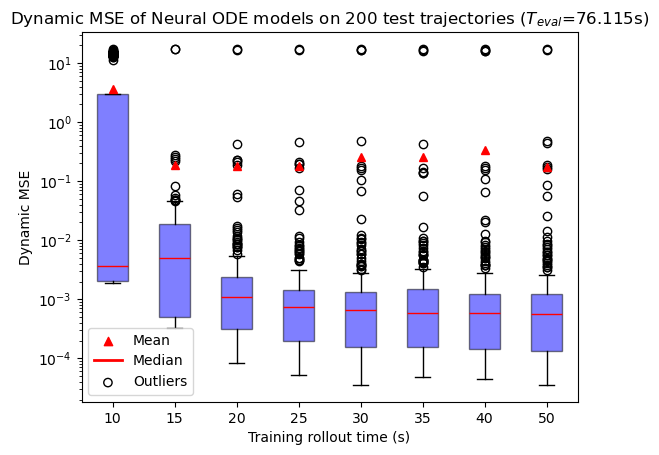

In [110]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10["L2_dynamic"],
    data_none_aug15["L2_dynamic"],
    data_none_aug20["L2_dynamic"],
    data_none_aug25["L2_dynamic"],
    data_none_aug30["L2_dynamic"],
    data_none_aug35["L2_dynamic"],
    data_none_aug40["L2_dynamic"],
    data_none_aug50["L2_dynamic"],
]
labels = [
          r'10',
            r'15',
            r'20',
            r'25',
            r'30',
            r'35',
            r'40',
            r'50',
          ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8])
ax.set_xticklabels(labels, rotation=0) #, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for patch in bplot['boxes']:
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor='blue', alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'={mean_T}s)')
plt.show()

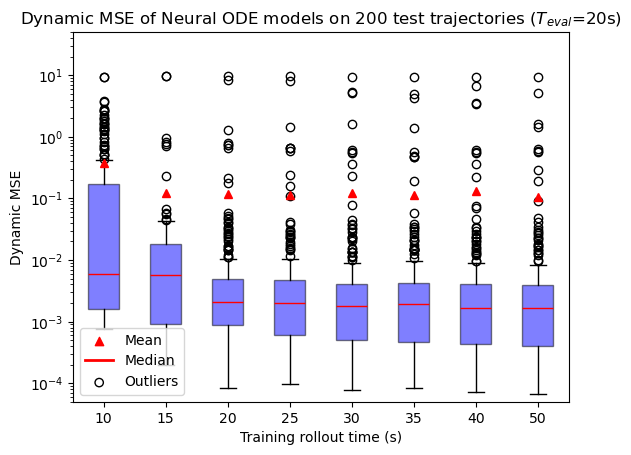

In [171]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10["L2_20s"],
    data_none_aug15["L2_20s"],
    data_none_aug20["L2_20s"],
    data_none_aug25["L2_20s"],
    data_none_aug30["L2_20s"],
    data_none_aug35["L2_20s"],
    data_none_aug40["L2_20s"],
    data_none_aug50["L2_20s"],
]
labels = [
          r'10',
            r'15',
            r'20',
            r'25',
            r'30',
            r'35',
            r'40',
            r'50',
          ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8])
ax.set_xticklabels(labels, rotation=0) #, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for patch in bplot['boxes']:
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor='blue', alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.ylim(5e-5,1e2)
plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=20s)')
plt.show()

In [52]:
data_none_aug20["L2_20s"].median(), data_none_aug40["L2_20s"].median(), data_none_aug50["L2_20s"].median()
#data_none_aug20["L2_20s"].max(), data_none_aug40["L2_20s"].max(), data_none_aug50["L2_20s"].max()
#data_none_aug20["L2_20s"].min(), data_none_aug40["L2_20s"].min(), data_none_aug50["L2_20s"].min()

(0.0020522369703076288, 0.0016620653316368724, 0.0016650097715524728)

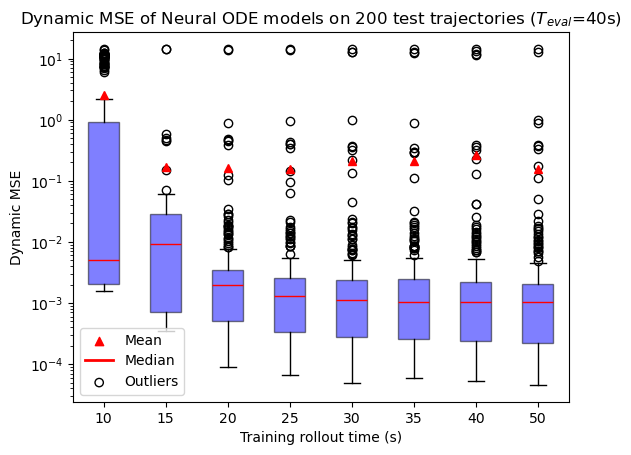

In [113]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10["L2_40s"],
    data_none_aug15["L2_40s"],
    data_none_aug20["L2_40s"],
    data_none_aug25["L2_40s"],
    data_none_aug30["L2_40s"],
    data_none_aug35["L2_40s"],
    data_none_aug40["L2_40s"],
    data_none_aug50["L2_40s"],
]
labels = [
          r'10',
            r'15',
            r'20',
            r'25',
            r'30',
            r'35',
            r'40',
            r'50',
          ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8])
ax.set_xticklabels(labels, rotation=0) #, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for patch in bplot['boxes']:
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor='blue', alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=40s)')
plt.show()

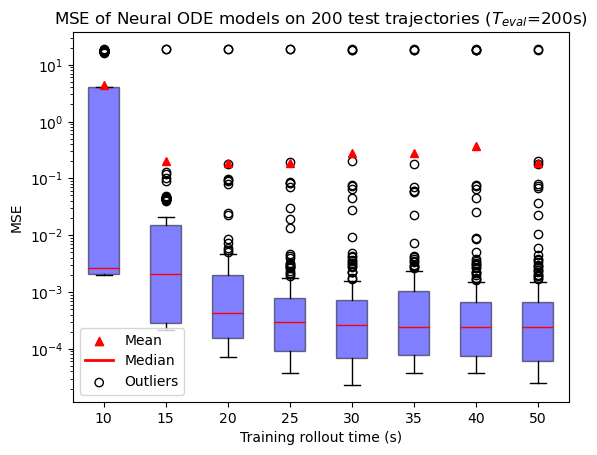

In [112]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10["L2"],
    data_none_aug15["L2"],
    data_none_aug20["L2"],
    data_none_aug25["L2"],
    data_none_aug30["L2"],
    data_none_aug35["L2"],
    data_none_aug40["L2"],
    data_none_aug50["L2"],
]
labels = [
          r'10',
            r'15',
            r'20',
            r'25',
            r'30',
            r'35',
            r'40',
            r'50',
          ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8])
ax.set_xticklabels(labels, rotation=0) #, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for patch in bplot['boxes']:
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor='blue', alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=200s)')
plt.show()

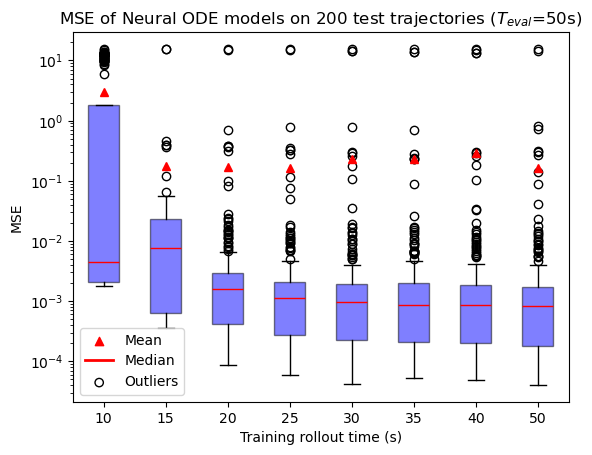

In [150]:
# boxplot meilleur
metric = "L2_50s"
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10[metric],
    data_none_aug15[metric],
    data_none_aug20[metric],
    data_none_aug25[metric],
    data_none_aug30[metric],
    data_none_aug35[metric],
    data_none_aug40[metric],
    data_none_aug50[metric],
]
labels = [
          r'10',
            r'15',
            r'20',
            r'25',
            r'30',
            r'35',
            r'40',
            r'50',
          ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8])
ax.set_xticklabels(labels, rotation=0) #, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for patch in bplot['boxes']:
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor='blue', alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=50s)')
plt.show()

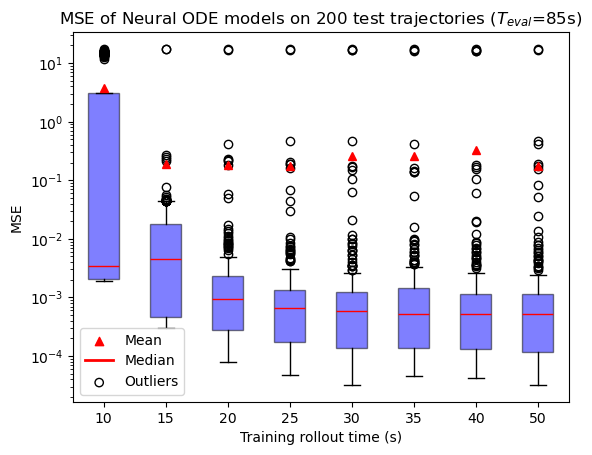

In [154]:
# boxplot meilleur
metric = "L2_stationary"
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10[metric],
    data_none_aug15[metric],
    data_none_aug20[metric],
    data_none_aug25[metric],
    data_none_aug30[metric],
    data_none_aug35[metric],
    data_none_aug40[metric],
    data_none_aug50[metric],
]
labels = [
          r'10',
            r'15',
            r'20',
            r'25',
            r'30',
            r'35',
            r'40',
            r'50',
          ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8])
ax.set_xticklabels(labels, rotation=0) #, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for patch in bplot['boxes']:
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor='blue', alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=85s)')
plt.show()

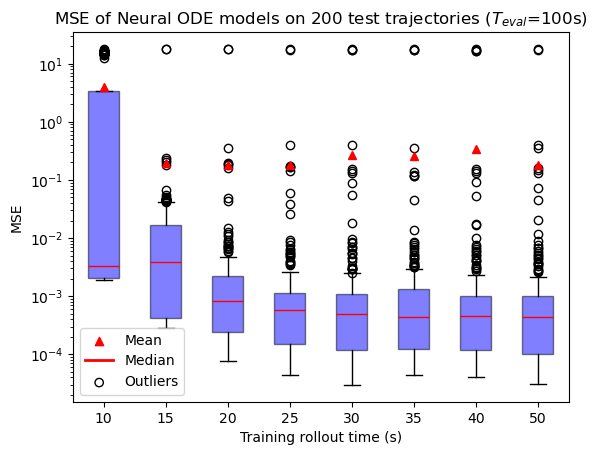

In [159]:
# boxplot meilleur
metric = "L2_100s"
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10[metric],
    data_none_aug15[metric],
    data_none_aug20[metric],
    data_none_aug25[metric],
    data_none_aug30[metric],
    data_none_aug35[metric],
    data_none_aug40[metric],
    data_none_aug50[metric],
]
labels = [
          r'10',
            r'15',
            r'20',
            r'25',
            r'30',
            r'35',
            r'40',
            r'50',
          ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2, 3, 4,5,6,7,8])
ax.set_xticklabels(labels, rotation=0) #, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for patch in bplot['boxes']:
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor='blue', alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=100s)')
plt.show()

In [68]:
data_fa_prime_supX20["L2_dynamic"].median(), data_none_aug20["L2_dynamic"].median()

(0.0015257707744237704, 0.0010769683821402268)

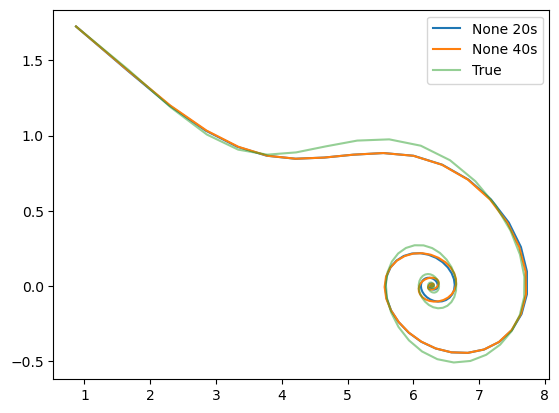

In [114]:
k=100
#plt.plot(data_fa_prime_supX20["y_pred"][k][0,:], data_fa_prime_supX20["y_pred"][k][1,:], label='Fa prime supX')
plt.plot(data_none_aug20["y_pred"][k][0,:], data_none_aug20["y_pred"][k][1,:], label='None 20s')
plt.plot(data_none_aug40["y_pred"][k][0,:], data_none_aug20["y_pred"][k][1,:], label='None 40s')
plt.plot(data_none_aug20["y_true"][k][0,:], data_none_aug20["y_true"][k][1,:], label='True', alpha=0.5)

plt.legend()

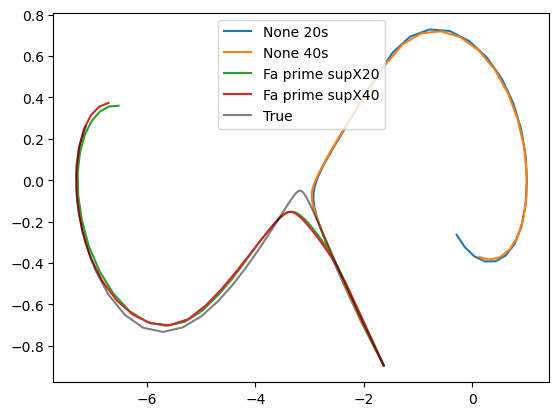

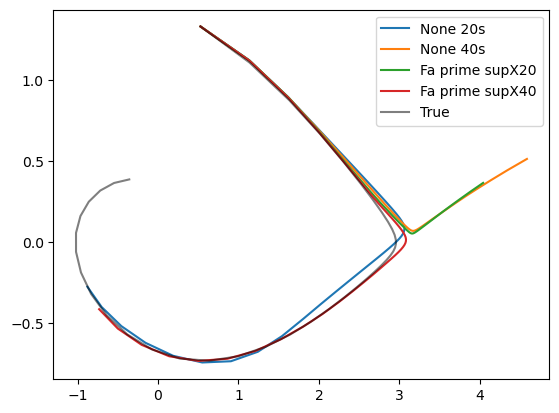

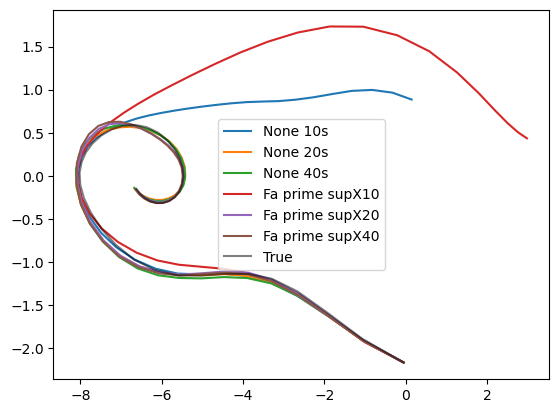

In [190]:
k=187
time = 41
plt.plot(data_none_aug20["y_pred"][k][0,:time], data_none_aug20["y_pred"][k][1,:time], label='None 20s')
plt.plot(data_none_aug40["y_pred"][k][0,:time], data_none_aug40["y_pred"][k][1,:time], label='None 40s')
plt.plot(data_fa_prime_supX20["y_pred"][k][0,:time], data_fa_prime_supX20["y_pred"][k][1,:time], label='Fa prime supX20')
plt.plot(data_fa_prime_supX40["y_pred"][k][0,:time], data_fa_prime_supX40["y_pred"][k][1,:time], label='Fa prime supX40')
plt.plot(data_none_aug20["y_true"][k][0,:time], data_none_aug20["y_true"][k][1,:time], label='True', alpha=0.5, color='black')
plt.legend()
plt.figure()
k=22
plt.plot(data_none_aug20["y_pred"][k][0,:time], data_none_aug20["y_pred"][k][1,:time], label='None 20s')
plt.plot(data_none_aug40["y_pred"][k][0,:time], data_none_aug40["y_pred"][k][1,:time], label='None 40s')
plt.plot(data_fa_prime_supX20["y_pred"][k][0,:time], data_fa_prime_supX20["y_pred"][k][1,:time], label='Fa prime supX20')
plt.plot(data_fa_prime_supX40["y_pred"][k][0,:time], data_fa_prime_supX40["y_pred"][k][1,:time], label='Fa prime supX40')
plt.plot(data_none_aug20["y_true"][k][0,:time], data_none_aug20["y_true"][k][1,:time], label='True', alpha=0.5, color='black')
plt.legend()
plt.figure()
k=199
plt.plot(data_none_aug10["y_pred"][k][0,:time], data_none_aug10["y_pred"][k][1,:time], label='None 10s')
plt.plot(data_none_aug20["y_pred"][k][0,:time], data_none_aug20["y_pred"][k][1,:time], label='None 20s')
plt.plot(data_none_aug40["y_pred"][k][0,:time], data_none_aug40["y_pred"][k][1,:time], label='None 40s')
plt.plot(data_fa_prime_supX10["y_pred"][k][0,:time], data_fa_prime_supX10["y_pred"][k][1,:time], label='Fa prime supX10')
plt.plot(data_fa_prime_supX20["y_pred"][k][0,:time], data_fa_prime_supX20["y_pred"][k][1,:time], label='Fa prime supX20')
plt.plot(data_fa_prime_supX40["y_pred"][k][0,:time], data_fa_prime_supX40["y_pred"][k][1,:time], label='Fa prime supX40')
plt.plot(data_none_aug20["y_true"][k][0,:time], data_none_aug20["y_true"][k][1,:time], label='True', alpha=0.5, color='black')
plt.legend()

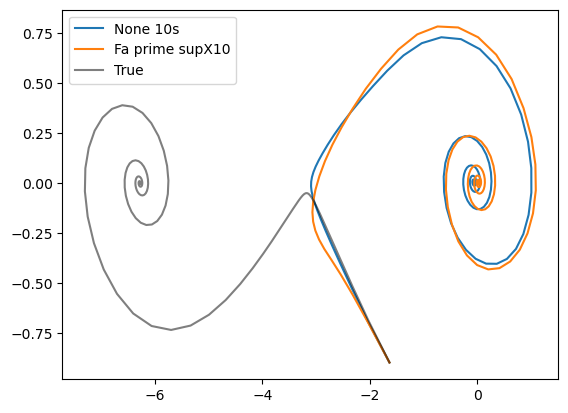

In [187]:
k=187
time = 10001
#time = 21
plt.plot(data_none_aug10["y_pred"][k][0,:time], data_none_aug10["y_pred"][k][1,:time], label='None 10s')
#plt.plot(data_none_aug20["y_pred"][k][0,:time], data_none_aug20["y_pred"][k][1,:time], label='None 20s')
#plt.plot(data_none_aug40["y_pred"][k][0,:time], data_none_aug40["y_pred"][k][1,:time], label='None 40s')
plt.plot(data_fa_prime_supX10["y_pred"][k][0,:time], data_fa_prime_supX10["y_pred"][k][1,:time], label='Fa prime supX10')
#plt.plot(data_fa_prime_supX20["y_pred"][k][0,:time], data_fa_prime_supX20["y_pred"][k][1,:time], label='Fa prime supX20')
#plt.plot(data_fa_prime_supX40["y_pred"][k][0,:time], data_fa_prime_supX40["y_pred"][k][1,:time], label='Fa prime supX40')
plt.plot(data_none_aug20["y_true"][k][0,:time], data_none_aug20["y_true"][k][1,:time], label='True', alpha=0.5, color='black')
plt.legend()

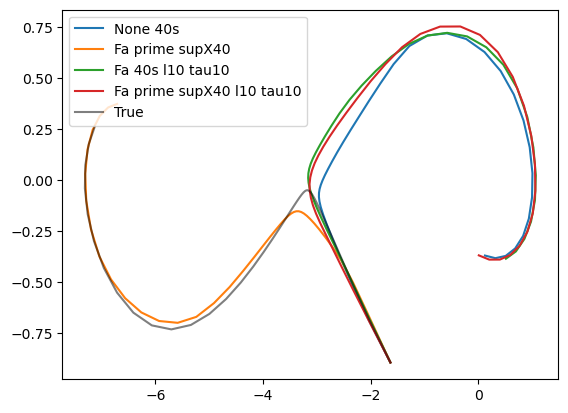

In [410]:
k=187
time = 41
plt.plot(data_none_aug40["y_pred"][k][0,:time], data_none_aug40["y_pred"][k][1,:time], label='None 40s')
plt.plot(data_fa_prime_supX40["y_pred"][k][0,:time], data_fa_prime_supX40["y_pred"][k][1,:time], label='Fa prime supX40')
plt.plot(data_aph_40_l10_tau10["y_pred"][k][0,:time], data_aph_40_l10_tau10["y_pred"][k][1,:time], label='Fa 40s l10 tau10')
plt.plot(data_fa_prime_supX40_l10_tau10["y_pred"][k][0,:time], data_fa_prime_supX40_l10_tau10["y_pred"][k][1,:time], label='Fa prime supX40 l10 tau10')
plt.plot(data_none_aug20["y_true"][k][0,:time], data_none_aug20["y_true"][k][1,:time], label='True', alpha=0.5, color='black')
plt.legend()

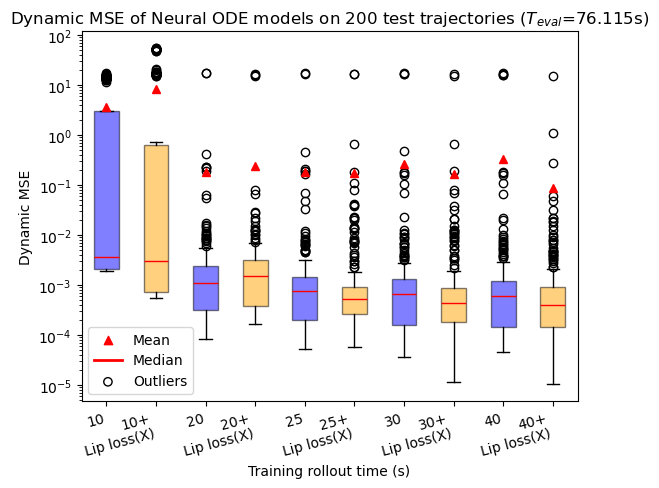

In [207]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10["L2_dynamic"],
    data_fa_prime_supX10["L2_dynamic"],
    data_none_aug20["L2_dynamic"],
    data_fa_prime_supX20["L2_dynamic"],
    data_none_aug25["L2_dynamic"],
    data_fa_prime_supX25["L2_dynamic"],
    data_none_aug30["L2_dynamic"],
    data_fa_prime_supX30["L2_dynamic"],
    data_none_aug40["L2_dynamic"],
    data_fa_prime_supX40["L2_dynamic"],
]
labels = [
    r'10',
    r'10+'+'\n'+'Lip loss(X)',
    r'20',
    r'20+'+'\n'+'Lip loss(X)',
    r'25',
    r'25+'+'\n'+'Lip loss(X)',
    r'30',
    r'30+'+'\n'+'Lip loss(X)',
    r'40',
    r'40+'+'\n'+'Lip loss(X)',
          ]


fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,9,10])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

colors =['blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange']
# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'={mean_T}s)')
plt.show()

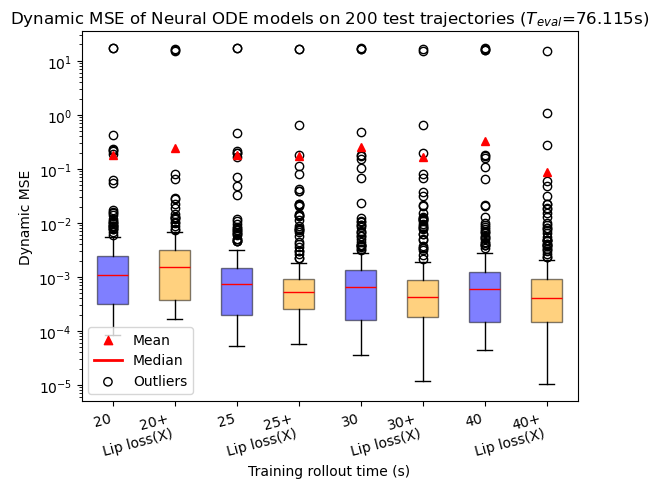

In [217]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    # data_none_aug10["L2_dynamic"],
    # data_fa_prime_supX10["L2_dynamic"],
    data_none_aug20["L2_dynamic"],
    data_fa_prime_supX20["L2_dynamic"],
    data_none_aug25["L2_dynamic"],
    data_fa_prime_supX25["L2_dynamic"],
    data_none_aug30["L2_dynamic"],
    data_fa_prime_supX30["L2_dynamic"],
    data_none_aug40["L2_dynamic"],
    data_fa_prime_supX40["L2_dynamic"],
]
labels = [
    # r'10',
    # r'10+'+'\n'+'Lip loss(X)',
    r'20',
    r'20+'+'\n'+'Lip loss(X)',
    r'25',
    r'25+'+'\n'+'Lip loss(X)',
    r'30',
    r'30+'+'\n'+'Lip loss(X)',
    r'40',
    r'40+'+'\n'+'Lip loss(X)',
          ]


fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

colors =['blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange']
# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'={mean_T}s)')
plt.show()

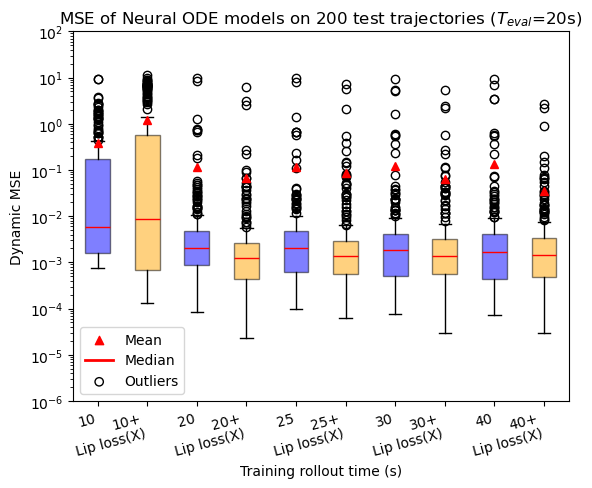

In [176]:
# boxplot meilleur
metric = "L2_20s"
losses_traj = [
    data_none_aug10[metric],
    data_fa_prime_supX10[metric],
    data_none_aug20[metric],
    data_fa_prime_supX20[metric],
    data_none_aug25[metric],
    data_fa_prime_supX25[metric],
    data_none_aug30[metric],
    data_fa_prime_supX30[metric],
    data_none_aug40[metric],
    data_fa_prime_supX40[metric],
]
labels = [
    r'10',
    r'10+'+'\n'+'Lip loss(X)',
    r'20',
    r'20+'+'\n'+'Lip loss(X)',
    r'25',
    r'25+'+'\n'+'Lip loss(X)',
    r'30',
    r'30+'+'\n'+'Lip loss(X)',
    r'40',
    r'40+'+'\n'+'Lip loss(X)',
          ]


fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,9,10])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

colors =['blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange']
# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')
plt.ylim(1e-6,1e2)
plt.title(r'MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=20s)')
plt.show()

In [412]:
data_none_aug20["L2_dynamic"][:25].max(), data_none_aug20["L2_dynamic"][:].max()

(0.23019372775883434, 17.118232759527952)

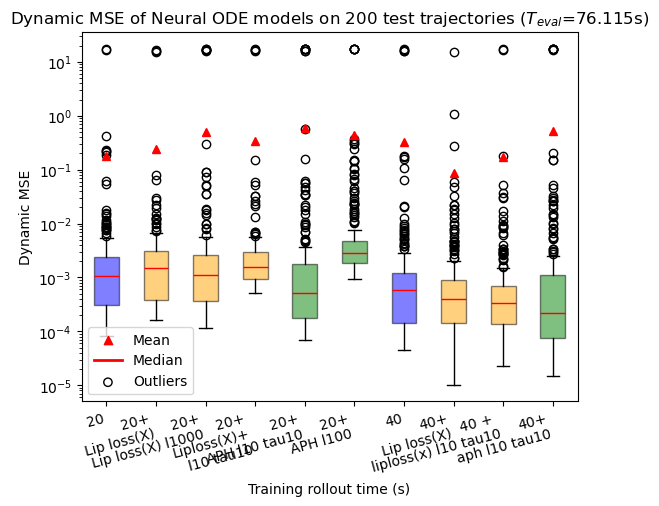

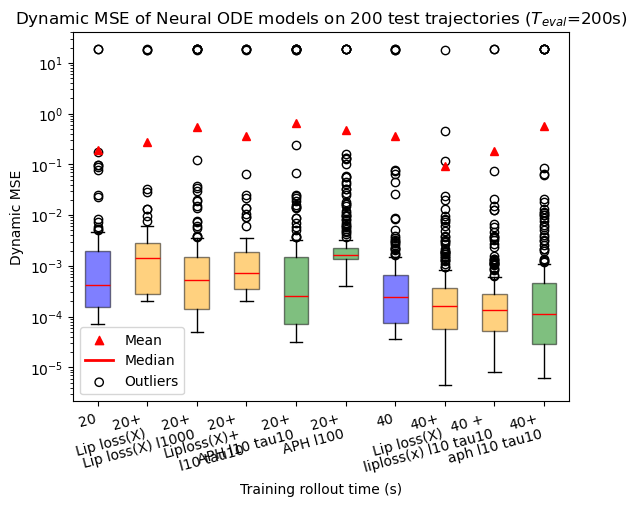

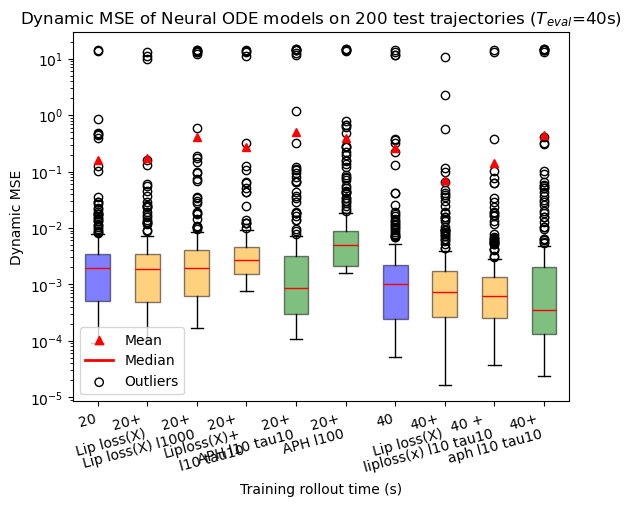

In [164]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    # data_none_aug10["L2_dynamic"],
    # data_fa_prime_supX10["L2_dynamic"],
    data_none_aug20["L2_dynamic"],
    data_fa_prime_supX20["L2_dynamic"],
    data_fa_prime_supX20_l1000["L2_dynamic"],
    data_fa_prime_supX20_l10_tau10["L2_dynamic"],
    data_aph_20_l10_tau10["L2_dynamic"],
    data_aph_20_l100["L2_dynamic"],
    # data_none_aug25["L2_dynamic"],
    # data_fa_prime_supX25["L2_dynamic"],
    # data_none_aug30["L2_dynamic"],
    # data_fa_prime_supX30["L2_dynamic"],
    data_none_aug40["L2_dynamic"],
    data_fa_prime_supX40["L2_dynamic"],
    data_fa_prime_supX40_l10_tau10["L2_dynamic"],
    data_aph_40_l10_tau10["L2_dynamic"],
]
labels = [
    # r'10',
    # r'10+'+'\n'+'Lip loss(X)',
    r'20',
    r'20+'+'\n'+'Lip loss(X)',
    r'20+'+'\n'+'Lip loss(X) l1000',
    r'20+' +'\n'+'Liploss(X)+'+'\n'+ 'l10 tau10',
    r'20+' +'\n'+'APH l10 tau10',
    r'20+' +'\n'+ 'APH l100',
    # r'25',
    # r'25+'+'\n'+'Lip loss(X)',
    # r'30',
    # r'30+'+'\n'+'Lip loss(X)',
    r'40',
    r'40+'+'\n'+'Lip loss(X)',
    '40 + '+'\n'+'liploss(x) l10 tau10',
    '40+'+'\n'+ 'aph l10 tau10'
          ]


fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,9,10])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

colors =['blue', 'orange','orange', 'orange', 'green','green','blue', 'orange', "orange", 'green', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange']
# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'={mean_T}s)')
plt.show()

# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    # data_none_aug10["L2_dynamic"],
    # data_fa_prime_supX10["L2_dynamic"],
    data_none_aug20["L2"],
    data_fa_prime_supX20["L2"],
    data_fa_prime_supX20_l1000["L2"],
    data_fa_prime_supX20_l10_tau10["L2"],
    data_aph_20_l10_tau10["L2"],
    data_aph_20_l100["L2"],
    # data_none_aug25["L2_dynamic"],
    # data_fa_prime_supX25["L2_dynamic"],
    # data_none_aug30["L2_dynamic"],
    # data_fa_prime_supX30["L2_dynamic"],
    data_none_aug40["L2"],
    data_fa_prime_supX40["L2"],
    data_fa_prime_supX40_l10_tau10["L2"],
    data_aph_40_l10_tau10["L2"],
]



fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,9,10])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=200s)')
plt.show()


# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    # data_none_aug10["L2_dynamic"],
    # data_fa_prime_supX10["L2_dynamic"],
    data_none_aug20["L2_40s"],
    data_fa_prime_supX20["L2_40s"],
    data_fa_prime_supX20_l1000["L2_40s"],
    data_fa_prime_supX20_l10_tau10["L2_40s"],
    data_aph_20_l10_tau10["L2_40s"],
    data_aph_20_l100["L2_40s"],
    # data_none_aug25["L2_dynamic"],
    # data_fa_prime_supX25["L2_dynamic"],
    # data_none_aug30["L2_dynamic"],
    # data_fa_prime_supX30["L2_dynamic"],
    data_none_aug40["L2_40s"],
    data_fa_prime_supX40["L2_40s"],
    data_fa_prime_supX40_l10_tau10["L2_40s"],
    data_aph_40_l10_tau10["L2_40s"],
]



fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,9,10])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=40s)')
plt.show()

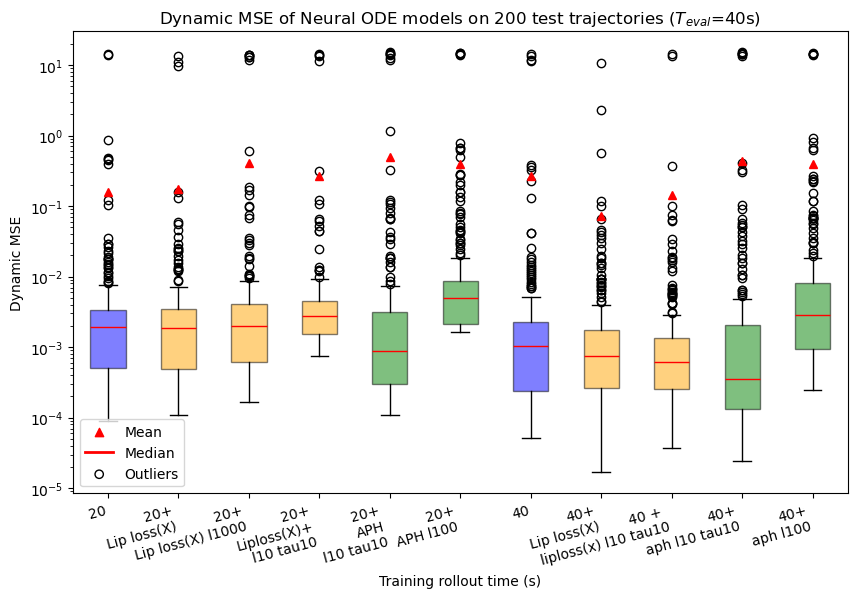

In [180]:
losses_traj = [
    # data_none_aug10["L2_dynamic"],
    # data_fa_prime_supX10["L2_dynamic"],
    data_none_aug20["L2_40s"],
    data_fa_prime_supX20["L2_40s"],
    data_fa_prime_supX20_l1000["L2_40s"],
    data_fa_prime_supX20_l10_tau10["L2_40s"],
    data_aph_20_l10_tau10["L2_40s"],
    data_aph_20_l100["L2_40s"],
    # data_none_aug25["L2_dynamic"],
    # data_fa_prime_supX25["L2_dynamic"],
    # data_none_aug30["L2_dynamic"],
    # data_fa_prime_supX30["L2_dynamic"],
    data_none_aug40["L2_40s"],
    data_fa_prime_supX40["L2_40s"],
    data_fa_prime_supX40_l10_tau10["L2_40s"],
    data_aph_40_l10_tau10["L2_40s"],
    data_aph_40_l100["L2_40s"],
]

labels = [
    # r'10',
    # r'10+'+'\n'+'Lip loss(X)',
    r'20',
    r'20+'+'\n'+'Lip loss(X)',
    r'20+'+'\n'+'Lip loss(X) l1000',
    r'20+' +'\n'+'Liploss(X)+'+'\n'+ 'l10 tau10',
    r'20+' +'\n'+'APH'+'\n' +'l10 tau10',
    r'20+' +'\n'+ 'APH l100',
    # r'25',
    # r'25+'+'\n'+'Lip loss(X)',
    # r'30',
    # r'30+'+'\n'+'Lip loss(X)',
    r'40',
    r'40+'+'\n'+'Lip loss(X)',
    '40 + '+'\n'+'liploss(x) l10 tau10',
    '40+'+'\n'+ 'aph l10 tau10',
    '40+'+'\n'+ 'aph l100'
          ]



fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,9,10,11])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')
colors =['blue', 'orange','orange', 'orange', 'green','green','blue', 'orange', "orange", 'green', 'green']

# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=40s)')
plt.show()

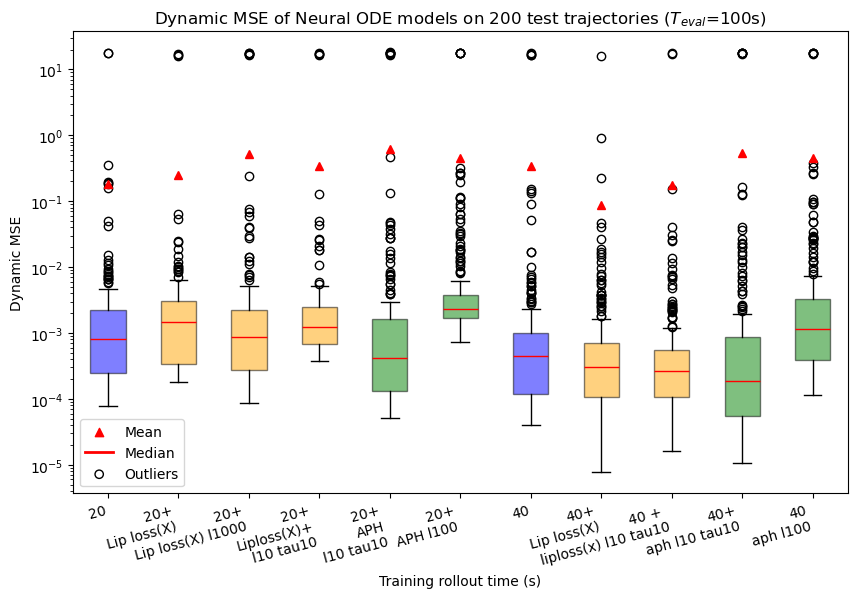

In [183]:
metric = "L2_100s"
losses_traj = [
    # data_none_aug10["L2_dynamic"],
    # data_fa_prime_supX10["L2_dynamic"],
    data_none_aug20[metric],
    data_fa_prime_supX20[metric],
    data_fa_prime_supX20_l1000[metric],
    data_fa_prime_supX20_l10_tau10[metric],
    data_aph_20_l10_tau10[metric],
    data_aph_20_l100[metric],
    # data_none_aug25["L2_dynamic"],
    # data_fa_prime_supX25["L2_dynamic"],
    # data_none_aug30["L2_dynamic"],
    # data_fa_prime_supX30["L2_dynamic"],
    data_none_aug40[metric],
    data_fa_prime_supX40[metric],
    data_fa_prime_supX40_l10_tau10[metric],
    data_aph_40_l10_tau10[metric],
    data_aph_40_l100[metric],
]

labels = [
    # r'10',
    # r'10+'+'\n'+'Lip loss(X)',
    r'20',
    r'20+'+'\n'+'Lip loss(X)',
    r'20+'+'\n'+'Lip loss(X) l1000',
    r'20+' +'\n'+'Liploss(X)+'+'\n'+ 'l10 tau10',
    r'20+' +'\n'+'APH'+'\n' +'l10 tau10',
    r'20+' +'\n'+ 'APH l100',
    # r'25',
    # r'25+'+'\n'+'Lip loss(X)',
    # r'30',
    # r'30+'+'\n'+'Lip loss(X)',
    r'40',
    r'40+'+'\n'+'Lip loss(X)',
    '40 + '+'\n'+'liploss(x) l10 tau10',
    '40+'+'\n'+ 'aph l10 tau10',
    '40' + '\n' + 'aph l100',
          ]



fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,9,10,11])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=100s)')
plt.show()

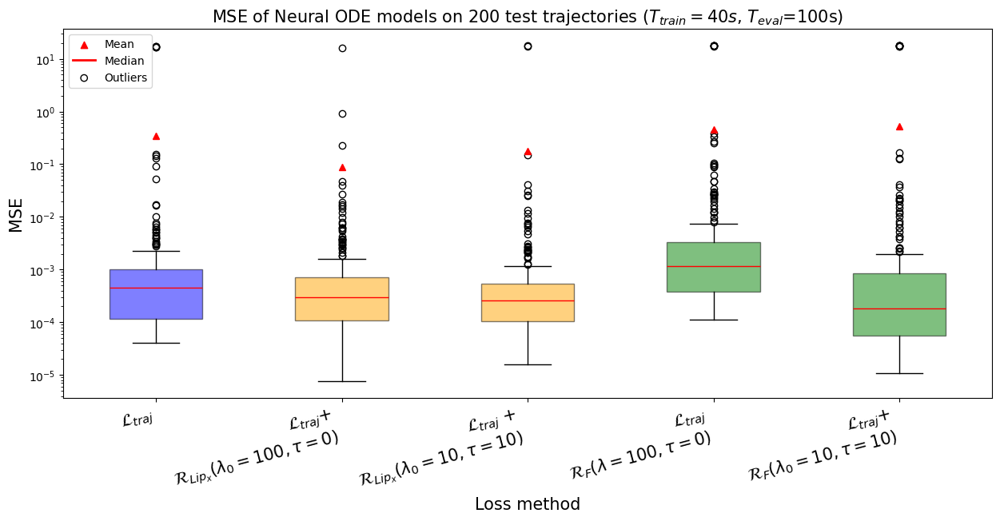

In [282]:
metric = "L2_100s"
losses_traj = [
    # data_none_aug10["L2_dynamic"],
    # data_fa_prime_supX10["L2_dynamic"],
    # data_none_aug20[metric],
    # data_fa_prime_supX20[metric],
    # data_fa_prime_supX20_l1000[metric],
    # data_fa_prime_supX20_l10_tau10[metric],
    # data_aph_20_l10_tau10[metric],
    # data_aph_20_l100[metric],
    # data_none_aug25["L2_dynamic"],
    # data_fa_prime_supX25["L2_dynamic"],
    # data_none_aug30["L2_dynamic"],
    # data_fa_prime_supX30["L2_dynamic"],
    data_none_aug40[metric],
    data_fa_prime_supX40[metric],
    data_fa_prime_supX40_l10_tau10[metric],
    data_aph_40_l100[metric],
    data_aph_40_l10_tau10[metric],
]

labels = [
    # r'10',
    # r'10+'+'\n'+'Lip loss(X)',
    # r'20',
    # r'20+'+'\n'+'Lip loss(X)',
    # r'20+'+'\n'+'Lip loss(X) l1000',
    # r'20+' +'\n'+'Liploss(X)+'+'\n'+ 'l10 tau10',
    # r'20+' +'\n'+'APH'+'\n' +'l10 tau10',
    # r'20+' +'\n'+ 'APH l100',
    # r'25',
    # r'25+'+'\n'+'Lip loss(X)',
    # r'30',
    # r'30+'+'\n'+'Lip loss(X)',
    r'$\mathcal{L}_{traj}$',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$',
    r'$\mathcal{L}_{traj}$ + '+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10,\tau=10)$ ',
    r'$\mathcal{L}_{traj}$' + '\n' + r'$\mathcal{R}_F(\lambda=100, \tau=0)$',
    r'$\mathcal{L}_{traj}$+'+'\n'+ r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$',
    
          ]



fig, ax = plt.subplots(figsize=(15, 6))
ax.set_yscale('log')
ax.set_ylabel('MSE', fontsize=15)
ax.set_xlabel('Loss method',fontsize=15)

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

colors =['blue','orange', 'orange', 'green','green','blue', 'orange', "orange", 'green', 'green']


ax.set_xticks([1, 2,3,4,5])
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=15)
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='upper left', fontsize=10)

# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'MSE of Neural ODE models on 200 test trajectories ($T_{train}=40s$, $T_{eval}$'+f'=100s)', fontsize=15)
plt.show()

## tipping points 

In [171]:
# get index traj with loss > threshold
def get_bad_traj(data, loss_name, threshold):
    bad_traj = data[data[loss_name] > threshold].index.tolist()
    return bad_traj

#get_bad_traj(data_none_aug20, "L2_40s", 1), get_bad_traj(data_none_aug20, "L2_dynamic", 1), get_bad_traj(data_none_aug20, "L2", 1)
#get_bad_traj(data_none_aug25, "L2_40s", 1), get_bad_traj(data_none_aug25, "L2_dynamic", 1), get_bad_traj(data_none_aug25, "L2", 1)
#get_bad_traj(data_none_aug30, "L2_40s", 1), get_bad_traj(data_none_aug30, "L2_dynamic", 1), get_bad_traj(data_none_aug30, "L2", 1)
#get_bad_traj(data_none_aug35, "L2_40s", 1), get_bad_traj(data_none_aug35, "L2_dynamic", 1), get_bad_traj(data_none_aug35, "L2", 1)
get_bad_traj(data_none_aug40, "L2_40s", 0.1), get_bad_traj(data_none_aug40, "L2_40s", 1)


([12, 22, 38, 60, 91, 109, 142, 187, 190], [22, 38, 60, 187])

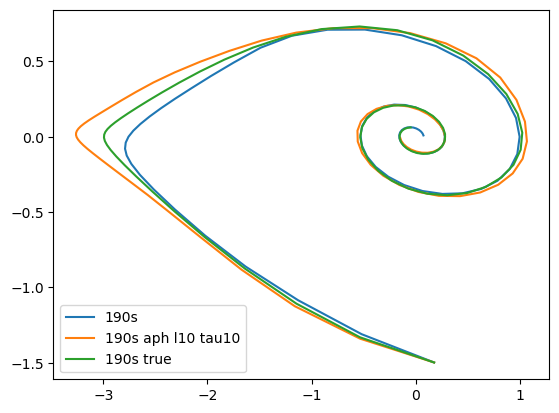

In [499]:
# plt.plot(data_none_aug40["y_pred"][91][0,:81], data_none_aug40["y_pred"][91][1,:81], label='91s')
# plt.plot(data_none_aug40["y_true"][91][0,:81], data_none_aug40["y_true"][91][1,:81], label='91s true')

# plt.plot(data_none_aug40["y_pred"][109][0,:81], data_none_aug40["y_pred"][109][1,:81], label='109s')
# plt.plot(data_none_aug40["y_true"][109][0,:81], data_none_aug40["y_true"][109][1,:81], label='109s true')

# plt.plot(data_none_aug40["y_pred"][142][0,:81], data_none_aug40["y_pred"][142][1,:81], label='109s')
# plt.plot(data_none_aug40["y_true"][142][0,:81], data_none_aug40["y_true"][142][1,:81], label='109s true')

# plt.plot(data_none_aug40["y_pred"][190][0,:81], data_none_aug40["y_pred"][190][1,:81], label='190s')
# plt.plot(data_aph_40_l10_tau10["y_pred"][190][0,:81], data_aph_40_l10_tau10["y_pred"][190][1,:81], label='190s aph l10 tau10')
# plt.plot(data_none_aug40["y_true"][190][0,:81], data_none_aug40["y_true"][190][1,:81], label='190s true')
# plt.legend()

k=190
plt.plot(data_none_aug40["y_pred"][k][0,:81], data_none_aug40["y_pred"][k][1,:81], label='190s')
plt.plot(data_aph_40_l10_tau10["y_pred"][k][0,:81], data_aph_40_l10_tau10["y_pred"][k][1,:81], label='190s aph l10 tau10')
plt.plot(data_none_aug40["y_true"][k][0,:81], data_none_aug40["y_true"][k][1,:81], label='190s true')
plt.legend()

In [468]:
print("nb bad traj 40s", len(get_bad_traj(data_none_aug40, "L2_40s", 1)))
print("nb bad traj 40s aph l10 tau10", len(get_bad_traj(data_aph_40_l10_tau10, "L2_40s", 1)))
print("nb bad traj 40s fa prime supX", len(get_bad_traj(data_fa_prime_supX40, "L2_40s", 1)))
print("nb bad traj 40s fa prime supX l10 tau10", len(get_bad_traj(data_fa_prime_supX40_l10_tau10, "L2_40s", 1)))
get_bad_traj(data_aph_40_l10_tau10, "L2_40s", 1), get_bad_traj(data_fa_prime_supX40, "L2_40s", 1), get_bad_traj(data_fa_prime_supX40_l10_tau10, "L2_40s", 1)

nb bad traj 40s 4
nb bad traj 40s aph l10 tau10 6
nb bad traj 40s fa prime supX 2
nb bad traj 40s fa prime supX l10 tau10 2


([12, 22, 38, 60, 142, 187], [38, 60], [142, 187])

In [172]:
print("nb bad traj 40s", len(get_bad_traj(data_none_aug40, "L2_40s", 3)))
print("nb bad traj 40s aph l10 tau10", len(get_bad_traj(data_aph_40_l10_tau10, "L2_40s", 3)))
print("nb bad traj 40s fa prime supX", len(get_bad_traj(data_fa_prime_supX40, "L2_40s", 3)))
print("nb bad traj 40s fa prime supX l10 tau10", len(get_bad_traj(data_fa_prime_supX40_l10_tau10, "L2_40s", 3)))
get_bad_traj(data_aph_40_l10_tau10, "L2_40s", 3), get_bad_traj(data_fa_prime_supX40, "L2_40s", 3), get_bad_traj(data_fa_prime_supX40_l10_tau10, "L2_40s", 3)

nb bad traj 40s 4
nb bad traj 40s aph l10 tau10 6
nb bad traj 40s fa prime supX 1
nb bad traj 40s fa prime supX l10 tau10 2


([12, 22, 38, 60, 142, 187], [60], [142, 187])

In [500]:
get_bad_traj(data_aph_40_l10_tau10, "L2_40s", 3), get_bad_traj(data_fa_prime_supX40, "L2_40s",3), get_bad_traj(data_fa_prime_supX40_l10_tau10, "L2_40s", 3)

([12, 22, 38, 60, 142, 187], [60], [142, 187])

au dessus de 3 on a un critere pour trajectoire tipping point that failed for 40s 

In [480]:
np.mean((data_fa_prime_supX40["y_pred"][38][:,:81]- data_fa_prime_supX40["y_true"][38][:,:81])**2), data_fa_prime_supX40["L2_40s"][38]

(2.2684652280755757, 2.2684652280755757)

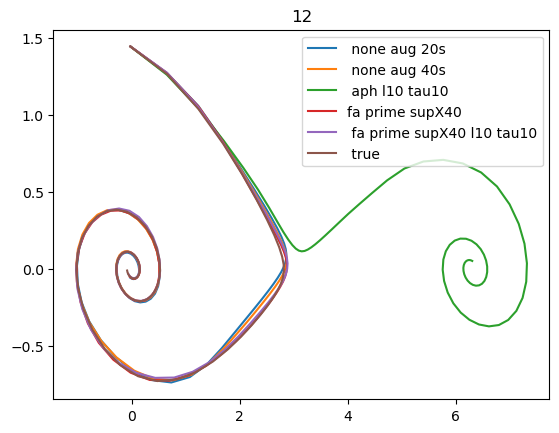

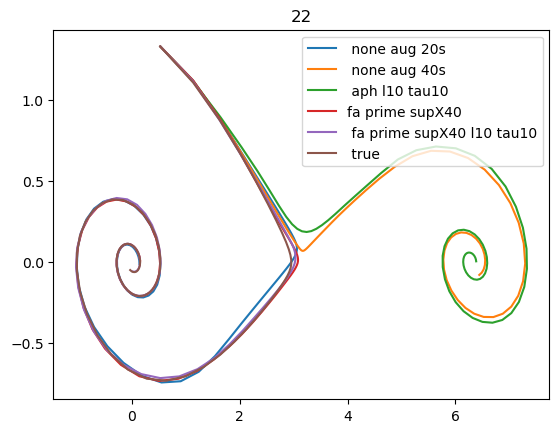

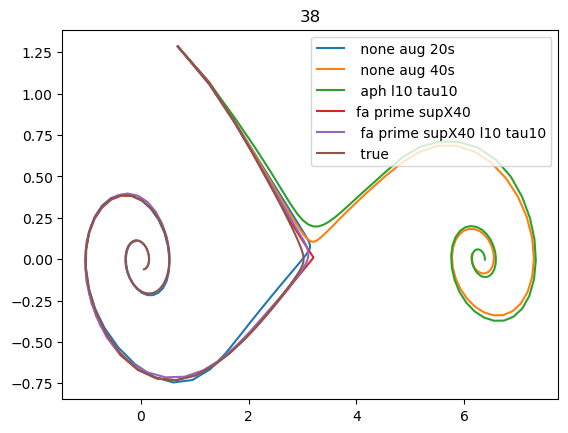

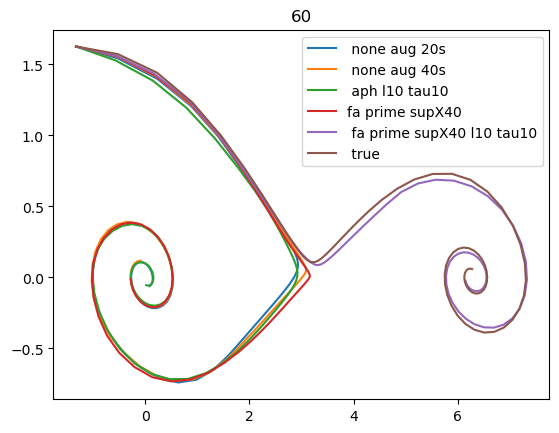

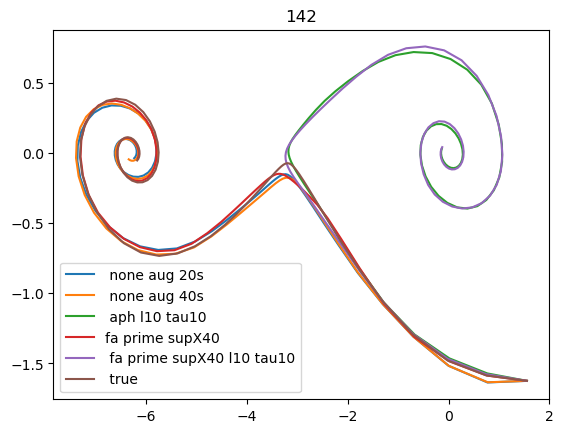

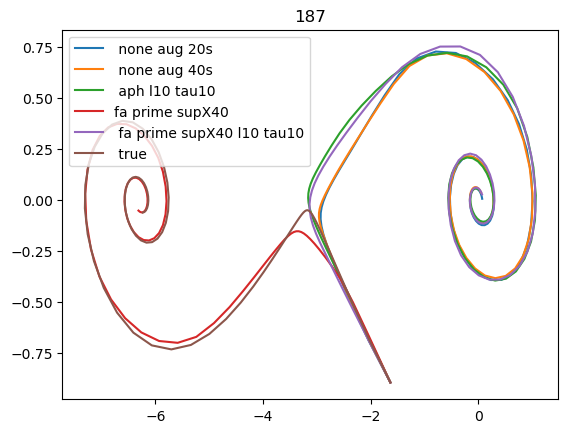

In [504]:
for traj_id in [12,22,38,60,142,187]:
    plt.figure()
    plt.title(traj_id)
    plt.plot(data_none_aug20["y_pred"][traj_id][0,:81], data_none_aug20["y_pred"][traj_id][1,:81], label=' none aug 20s')
    plt.plot(data_none_aug40["y_pred"][traj_id][0,:81], data_none_aug40["y_pred"][traj_id][1,:81], label=' none aug 40s')
    plt.plot(data_aph_40_l10_tau10["y_pred"][traj_id][0,:81], data_aph_40_l10_tau10["y_pred"][traj_id][1,:81], label=' aph l10 tau10')
    plt.plot(data_fa_prime_supX40["y_pred"][traj_id][0,:81], data_fa_prime_supX40["y_pred"][traj_id][1,:81], label='fa prime supX40')
    plt.plot(data_fa_prime_supX40_l10_tau10["y_pred"][traj_id][0,:81], data_fa_prime_supX40_l10_tau10["y_pred"][traj_id][1,:81], label=' fa prime supX40 l10 tau10')
    plt.plot(data_aph_40_l10_tau10["y_true"][traj_id][0,:81], data_aph_40_l10_tau10["y_true"][traj_id][1,:81], label=' true')
    plt.legend()
    


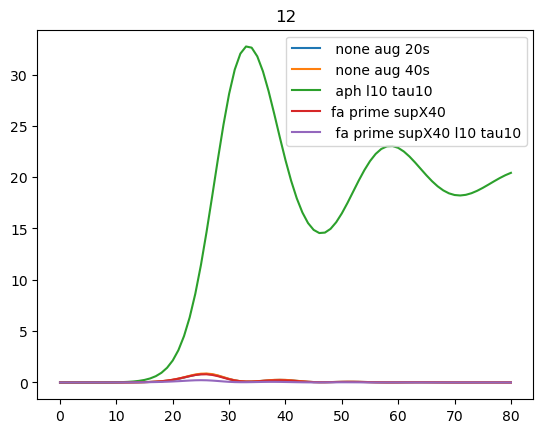

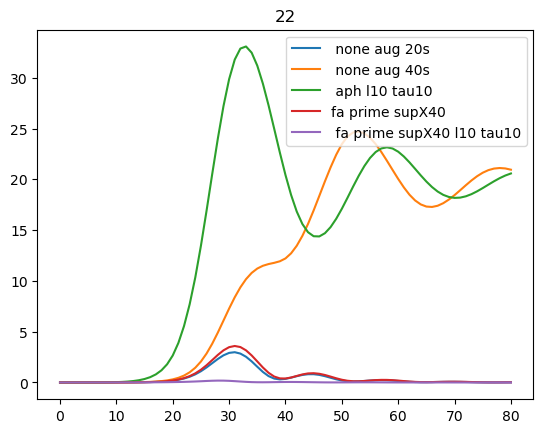

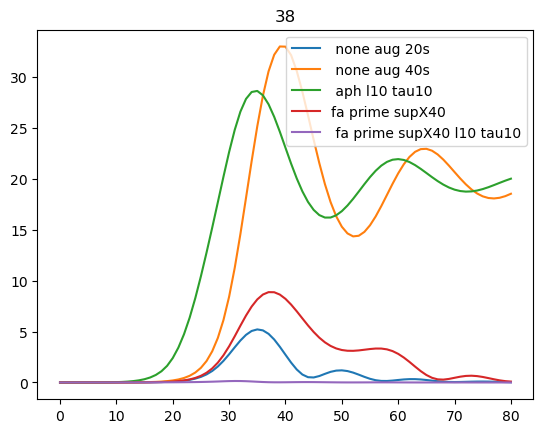

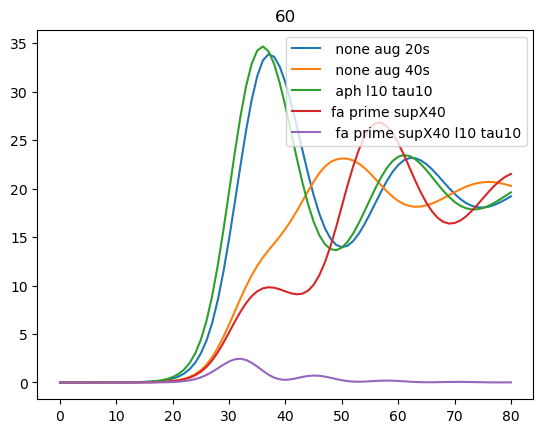

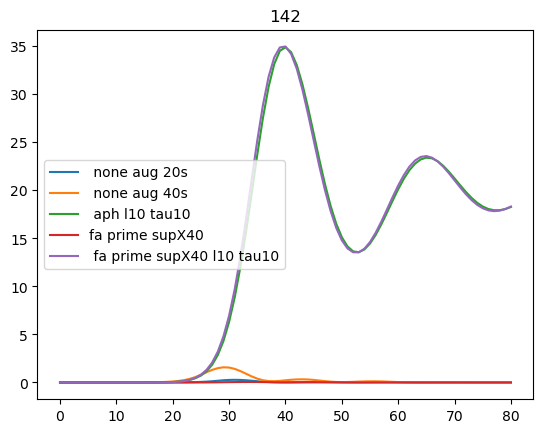

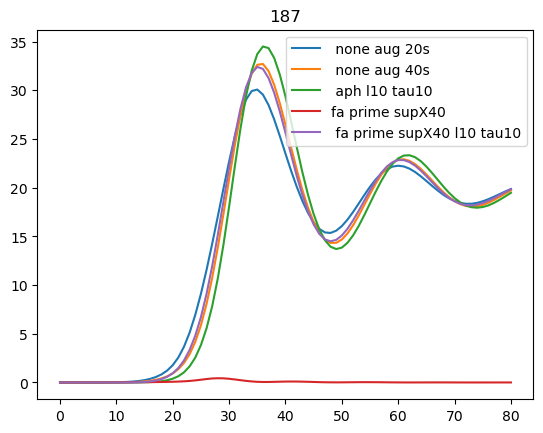

In [508]:
for traj_id in [12,22,38,60,142,187]:
    plt.figure()
    plt.title(traj_id)
    plt.plot(np.mean((data_none_aug20["y_pred"][traj_id][:,:81]-data_none_aug20["y_true"][traj_id][:,:81])**2, axis=0), label=' none aug 20s')
    plt.plot(np.mean((data_none_aug40["y_pred"][traj_id][:,:81]-data_none_aug40["y_true"][traj_id][:,:81])**2, axis=0), label=' none aug 40s')
    plt.plot(np.mean((data_aph_40_l10_tau10["y_pred"][traj_id][:,:81]-data_aph_40_l10_tau10["y_true"][traj_id][:,:81])**2, axis=0), label=' aph l10 tau10')
    plt.plot(np.mean((data_fa_prime_supX40["y_pred"][traj_id][:,:81]-data_fa_prime_supX40["y_true"][traj_id][:,:81])**2, axis=0), label='fa prime supX40')
    plt.plot(np.mean((data_fa_prime_supX40_l10_tau10["y_pred"][traj_id][:,:81]-data_fa_prime_supX40_l10_tau10["y_true"][traj_id][:,:81])**2, axis=0), label=' fa prime supX40 l10 tau10')
    plt.legend()
    


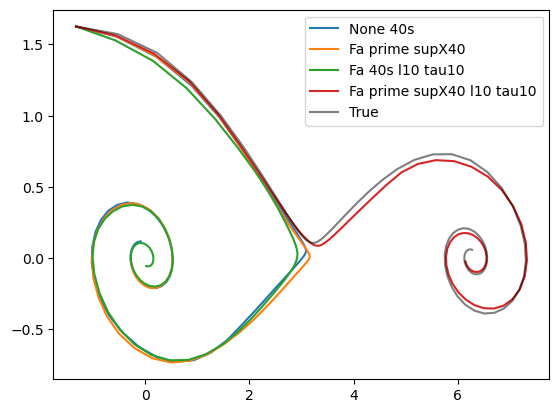

In [466]:
k=60
time = 81
plt.plot(data_none_aug40["y_pred"][k][0,:time], data_none_aug40["y_pred"][k][1,:time], label='None 40s')
plt.plot(data_fa_prime_supX40["y_pred"][k][0,:time], data_fa_prime_supX40["y_pred"][k][1,:time], label='Fa prime supX40')
plt.plot(data_aph_40_l10_tau10["y_pred"][k][0,:time], data_aph_40_l10_tau10["y_pred"][k][1,:time], label='Fa 40s l10 tau10')
plt.plot(data_fa_prime_supX40_l10_tau10["y_pred"][k][0,:time], data_fa_prime_supX40_l10_tau10["y_pred"][k][1,:time], label='Fa prime supX40 l10 tau10')
plt.plot(data_none_aug20["y_true"][k][0,:time], data_none_aug20["y_true"][k][1,:time], label='True', alpha=0.5, color='black')
plt.legend()

In [503]:
# 20s
get_bad_traj(data_none_aug20, "L2_40s", 1), get_bad_traj(data_none_aug20, "L2_dynamic", 1), get_bad_traj(data_none_aug20, "L2", 1)

([60, 187], [60, 187], [60, 187])

In [501]:
print("nb bad traj 20s", len(get_bad_traj(data_none_aug20, "L2_40s", 1)))
print("nb bad traj 20s aph l10 tau10", len(get_bad_traj(data_aph_20_l10_tau10, "L2_40s", 1)))
print("nb bad traj 20s fa prime supX", len(get_bad_traj(data_fa_prime_supX20, "L2_40s", 1)))
print("nb bad traj 20s fa prime supX l10 tau10", len(get_bad_traj(data_fa_prime_supX20_l10_tau10, "L2_40s", 1)))
get_bad_traj(data_aph_20_l10_tau10, "L2_40s", 1), get_bad_traj(data_fa_prime_supX20, "L2_40s", 1), get_bad_traj(data_fa_prime_supX20_l10_tau10, "L2_40s", 1)

nb bad traj 20s 2
nb bad traj 20s aph l10 tau10 8
nb bad traj 20s fa prime supX 3
nb bad traj 20s fa prime supX l10 tau10 4


([12, 22, 38, 60, 109, 142, 187, 190], [22, 38, 60], [54, 60, 142, 187])

Neural ODE simple
- 20s, 25s a que 60 et 187 au dessus de 1
- 30s, 35s a 38 en plus
-  40s a 22 et 38 en plus

## Confidence interval and stat test 

In [418]:
from scipy import stats
from scipy.stats import t
def confidence_interval(data):
    interv = t.interval(0.95, len(data)-1, loc=np.mean(data), scale=stats.sem(data))
    return np.mean(data), interv 

In [450]:
print("20s")
confidence_interval(np.log(data_none_aug20["L2_dynamic"])), confidence_interval(np.log(data_fa_prime_supX20["L2_dynamic"])), confidence_interval(np.log(data_aph_20_l10_tau10["L2_dynamic"])), confidence_interval(np.log(data_aph_20_l100["L2_dynamic"]))

20s


((-6.7469548899726535, (-7.0154484628491565, -6.4784613170961505)),
 (-6.592332152844185, (-6.838764220712021, -6.345900084976349)),
 (-6.902244112262314, (-7.252771317727514, -6.551716906797114)),
 (-5.3183195319378385, (-5.573015918656397, -5.06362314521928)))

In [449]:
print("40s")
confidence_interval(np.log(data_none_aug40["L2_dynamic"])), confidence_interval(np.log(data_fa_prime_supX40["L2_dynamic"])), confidence_interval(np.log(data_fa_prime_supX40_l10_tau10["L2_dynamic"])), confidence_interval(np.log(data_aph_40_l10_tau10["L2_dynamic"]))

40s


((-7.318762395439069, (-7.626859554760196, -7.010665236117942)),
 (-7.742234305905787, (-8.033666534502746, -7.450802077308828)),
 (-7.818718007311406, (-8.090486206282147, -7.546949808340664)),
 (-7.733630677906126, (-8.11265536827915, -7.354605987533102)))

In [515]:
# test if 2 models are significantly different
from scipy.stats import ttest_ind
def test_significant_difference(data1, data2, alternative='two-sided'):
    t_stat, p_value = ttest_ind(data1, data2, alternative=alternative)
    return t_stat, p_value

print("20s")
t_stat, p_value = test_significant_difference(data_aph_40_l10_tau10["L2_40s"], data_fa_prime_supX40["L2_40s"], alternative='less')
print(f"T-statistic: {t_stat}, P-value: {p_value}")


20s
T-statistic: 2.0281673044415416, P-value: 0.9783956398755352


In [526]:
t_stat, p_value = test_significant_difference(data_aph_20_l10_tau10["L2_40s"], data_fa_prime_supX20["L2_40s"], alternative='less')
print(f"T-statistic: {t_stat}, P-value: {p_value}")

t_stat, p_value = test_significant_difference(data_none_aug20["L2_40s"],data_aph_20_l10_tau10["L2_40s"], alternative='less')
print(f"T-statistic: {t_stat}, P-value: {p_value}")


T-statistic: 1.5590125565760593, P-value: 0.9401059057128777
T-statistic: -1.6435009838295491, P-value: 0.050534506143238116


In [121]:
#data_fa_prime_supX20["L2_20s"].median(),data_fa_prime_supX40["L2_20s"].median(), data_none_aug20["L2_20s"].median(), data_none_aug40["L2_20s"].median(), data_none_aug50["L2_20s"].median()
data_fa_prime_supX20["L2_20s"].mean(), data_none_aug20["L2_20s"].mean(), data_none_aug40["L2_20s"].mean(), data_none_aug50["L2_20s"].mean()

(0.06743454619873353,
 0.11849418345331354,
 0.13132972684856056,
 0.1034229845667464)

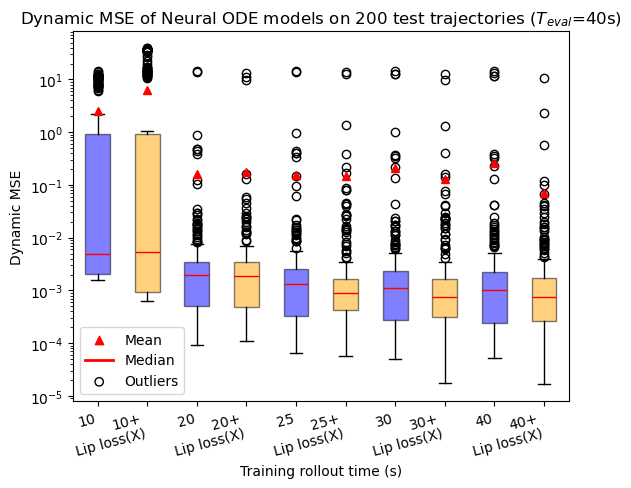

In [209]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10["L2_40s"],
    data_fa_prime_supX10["L2_40s"],
    data_none_aug20["L2_40s"],
    data_fa_prime_supX20["L2_40s"],
    data_none_aug25["L2_40s"],
    data_fa_prime_supX25["L2_40s"],
    data_none_aug30["L2_40s"],
    data_fa_prime_supX30["L2_40s"],
    data_none_aug40["L2_40s"],
    data_fa_prime_supX40["L2_40s"],
]
labels = [
    r'10',
    r'10+'+'\n'+'Lip loss(X)',
    r'20',
    r'20+'+'\n'+'Lip loss(X)',
    r'25',
    r'25+'+'\n'+'Lip loss(X)',
    r'30',
    r'30+'+'\n'+'Lip loss(X)',
    r'40',
    r'40+'+'\n'+'Lip loss(X)',
          ]


fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,9,10])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

colors =['blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange']
# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=40s)')
plt.show()

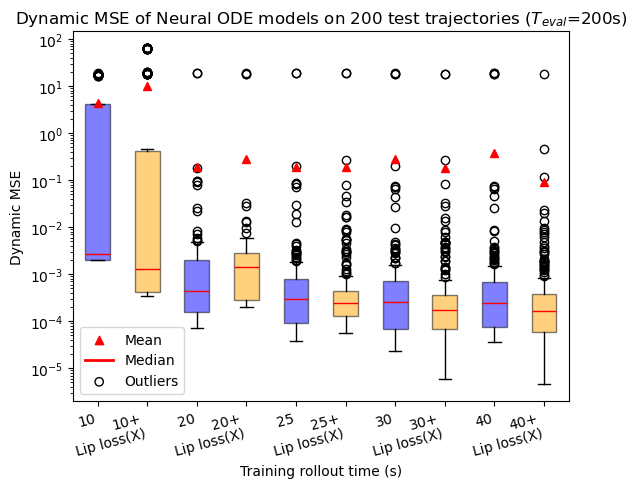

In [210]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    data_none_aug10["L2"],
    data_fa_prime_supX10["L2"],
    data_none_aug20["L2"],
    data_fa_prime_supX20["L2"],
    data_none_aug25["L2"],
    data_fa_prime_supX25["L2"],
    data_none_aug30["L2"],
    data_fa_prime_supX30["L2"],
    data_none_aug40["L2"],
    data_fa_prime_supX40["L2"],
]
labels = [
    r'10',
    r'10+'+'\n'+'Lip loss(X)',
    r'20',
    r'20+'+'\n'+'Lip loss(X)',
    r'25',
    r'25+'+'\n'+'Lip loss(X)',
    r'30',
    r'30+'+'\n'+'Lip loss(X)',
    r'40',
    r'40+'+'\n'+'Lip loss(X)',
          ]


fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,9,10])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

colors =['blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange']
# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=200s)')
plt.show()

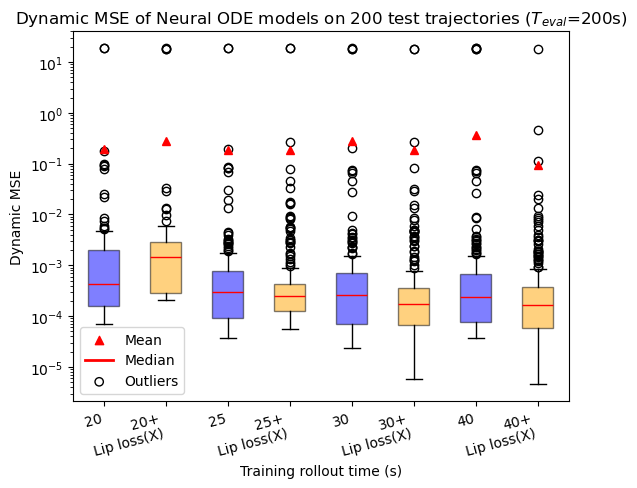

In [216]:
# boxplot meilleur
mean_T = data_none_aug10["stationary_index"].mean()*0.5
losses_traj = [
    # data_none_aug10["L2"],
    # data_fa_prime_supX10["L2"],
    data_none_aug20["L2"],
    data_fa_prime_supX20["L2"],
    data_none_aug25["L2"],
    data_fa_prime_supX25["L2"],
    data_none_aug30["L2"],
    data_fa_prime_supX30["L2"],
    data_none_aug40["L2"],
    data_fa_prime_supX40["L2"],
]
labels = [
    # r'10',
    # r'10+'+'\n'+'Lip loss(X)',
    r'20',
    r'20+'+'\n'+'Lip loss(X)',
    r'25',
    r'25+'+'\n'+'Lip loss(X)',
    r'30',
    r'30+'+'\n'+'Lip loss(X)',
    r'40',
    r'40+'+'\n'+'Lip loss(X)',
          ]


fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8,])
ax.set_xticklabels(labels, rotation=15, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

colors =['blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange', 'blue', 'orange']
# fill with colors
for i, patch in enumerate(bplot['boxes']):
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=200s)')
plt.show()

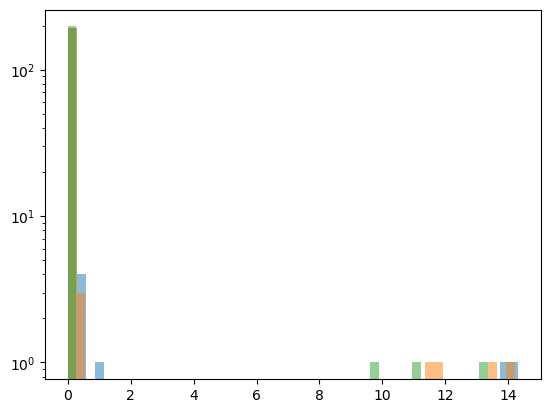

In [102]:
plt.hist(data_none_aug20["L2_40s"], bins=50, alpha=0.5, label='None 20s')
plt.hist(data_none_aug40["L2_40s"], bins=50, alpha=0.5, label='None 40s')
plt.hist(data_fa_prime_supX20["L2_40s"], bins=50, alpha=0.5, label='Fa prime supX 20s')
plt.yscale('log')

In [95]:
data_none_aug20["L2_40s"].median(), data_none_aug40["L2_40s"].median(), data_none_aug50["L2_40s"].median(), data_fa_prime_supX20["L2_40s"].median()

(0.001945331477468447,
 0.001033021609002331,
 0.0010225572937060964,
 0.0018916849019014997)

## Jacobian norms

In [241]:
def F_y(x):
    """Returns the dynamics of the pendulum."""
    return jnp.array([x[1], -((2*jnp.pi/12)**2) *jnp.sin(x[0]) - 0.2*x[1]])

def F(x,t):
    """Returns the dynamics of the pendulum."""
    return jnp.array([x[1], -((2*jnp.pi/12)**2) *jnp.sin(x[0]) - 0.2*x[1]])

### On true trajectories

In [235]:
lip_data_none_aug5 = compute_jacobian_test(model_none_aug5, y_40s)

In [238]:
lip_data_none_aug10 = compute_jacobian_test(model_none_aug10, y_40s)
lip_data_none_aug15 = compute_jacobian_test(model_none_aug15, y_40s)
lip_data_none_aug20 = compute_jacobian_test(model_none_aug20, y_40s)
lip_data_none_aug25 = compute_jacobian_test(model_none_aug25, y_40s)
lip_data_none_aug30 = compute_jacobian_test(model_none_aug30, y_40s)
lip_data_none_aug35 = compute_jacobian_test(model_none_aug35, y_40s)
lip_data_none_aug40 = compute_jacobian_test(model_none_aug40, y_40s)
lip_data_none_aug50 = compute_jacobian_test(model_none_aug50, y_40s)

In [237]:
lip_data_lipsupX10 = compute_jacobian_test(model_lipsupX10, y_40s)
lip_data_lipsupX20 = compute_jacobian_test(model_lipsupX20, y_40s)
lip_data_lipsupX25 = compute_jacobian_test(model_lipsupX25, y_40s)
lip_data_lipsupX30 = compute_jacobian_test(model_lipsupX30, y_40s)
lip_data_lipsupX40 = compute_jacobian_test(model_lipsupX40, y_40s)
lip_data_lipsupX_40_l10_tau10 = compute_jacobian_test(model_lipsupX40_l10_tau10, y_40s)

In [195]:
lip_data_aph20_l10_tau10 = compute_jacobian_test(model_aph_20_l10_tau10, y_40s)
lip_data_aph_40_l10_tau10 = compute_jacobian_test(model_aph_40_l10_tau10, y_40s)
lip_data_aph_40_l100 = compute_jacobian_test(model_aph_40_l100, y_40s)

In [242]:
lip_data_true = compute_jacobian_test(F_y,y_40s, bool_true=True)

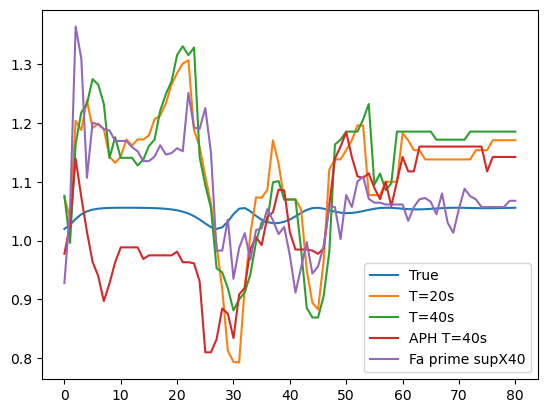

In [444]:
k=187
200 * 81, lip_data_true.shape
plt.plot(lip_data_true[(k)*81:(k+1)*81], label="True")
#plt.plot(lip_data_true[81:162])
plt.plot(lip_data_none_aug20[(k)*81:(k+1)*81],label="T=20s")
plt.plot(lip_data_none_aug40[(k)*81:(k+1)*81],label="T=40s")
plt.plot(lip_data_aph_40_l10_tau10[(k)*81:(k+1)*81], label="APH T=40s")
plt.plot(lip_data_lipsupX40[(k)*81:(k+1)*81], label="Fa prime supX40")
plt.legend()



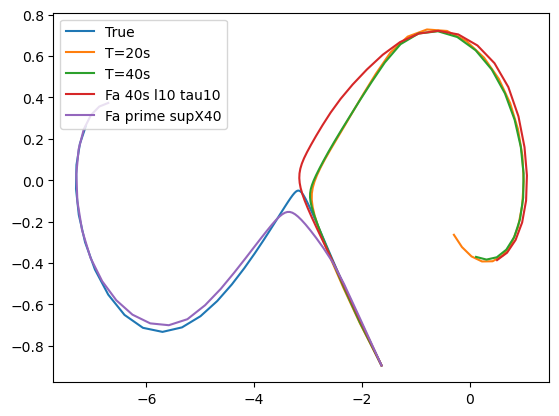

In [445]:
k=187
time = 41
plt.plot(data_none_aug20["y_true"][k][0,:time], data_none_aug20["y_true"][k][1,:time], label='True')
plt.plot(data_none_aug20["y_pred"][k][0,:time], data_none_aug20["y_pred"][k][1,:time], label='T=20s')
plt.plot(data_none_aug40["y_pred"][k][0,:time], data_none_aug40["y_pred"][k][1,:time], label='T=40s')
plt.plot(data_aph_40_l10_tau10["y_pred"][k][0,:time], data_aph_40_l10_tau10["y_pred"][k][1,:time], label='Fa 40s l10 tau10')

plt.plot(data_fa_prime_supX40["y_pred"][k][0,:time], data_fa_prime_supX40["y_pred"][k][1,:time], label='Fa prime supX40')
#plt.plot(data_fa_prime_supX40_l10_tau10["y_pred"][k][0,:time], data_fa_prime_supX40_l10_tau10["y_pred"][k][1,:time], label='Fa prime supX40 l10 tau10')
plt.legend()

In [243]:
df_lip_curr = pd.DataFrame({
    "5": lip_data_none_aug5,
    "10": lip_data_none_aug10,  
    "15": lip_data_none_aug15,
    "20": lip_data_none_aug20,
    "25": lip_data_none_aug25,
    "30": lip_data_none_aug30,
    "35": lip_data_none_aug35,
    "40": lip_data_none_aug40,
    "50": lip_data_none_aug50,
    "true": lip_data_true
})

In [123]:
df_lip_curr_lipsupX = pd.DataFrame({
    "10": lip_data_lipsupX10,
    "20": lip_data_lipsupX20,
    "25": lip_data_lipsupX25,
    "30": lip_data_lipsupX30,
    "40": lip_data_lipsupX40,
    "true": lip_data_true
})

In [245]:
L_true = np.sqrt(1+ 0.2**2 + (2*np.pi/12)**4)

Text(0.5, 1.0, 'Jacobian norm of Neural ODE models on 200 test trajectories ($T_{eval}$=40s)')

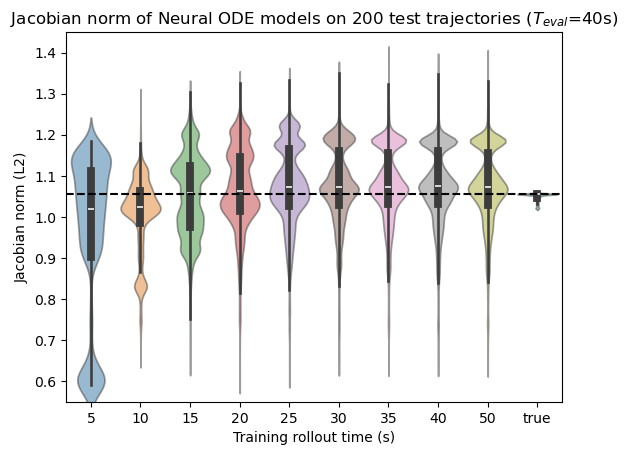

In [246]:
sns.violinplot(df_lip_curr, alpha=0.5)#, color="blue", alpha=0.5) 
plt.ylim(0.55,1.45)
plt.axhline(L_true, color='black', linestyle='--', label='True Lipschitz constant')
plt.ylabel("Jacobian norm (L2)")
plt.xlabel("Training rollout time (s)")
plt.title(r"Jacobian norm of Neural ODE models on 200 test trajectories ($T_{eval}$=40s)")

Text(0.5, 1.0, 'Jacobian norm of Neural ODE models on 200 test trajectories ($T_{eval}$=40s)')

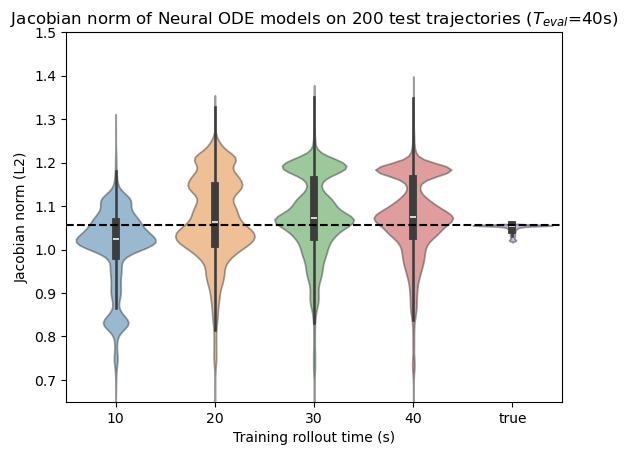

In [83]:
sns.violinplot(df_lip_curr[["10", "20", "30", "40", "true"]], alpha=0.5)#, color="blue", alpha=0.5) 
plt.ylim(0.65,1.5)
plt.axhline(L_true, color='black', linestyle='--', label='True Lipschitz constant')
plt.ylabel("Jacobian norm (L2)")
plt.xlabel("Training rollout time (s)")
plt.title(r"Jacobian norm of Neural ODE models on 200 test trajectories ($T_{eval}$=40s)")

Text(0.5, 1.0, 'Jacobian norm of Neural ODE models on 200 test trajectories ($T_{eval}$=40s)')

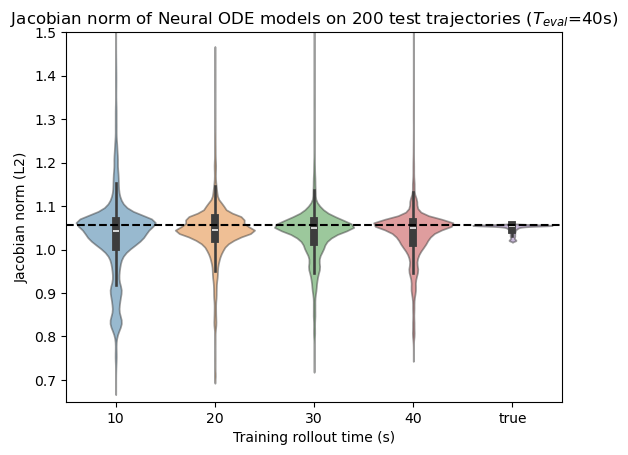

In [215]:
sns.violinplot(df_lip_curr_lipsupX[["10", "20", "30", "40", "true"]], alpha=0.5)#, color="blue", alpha=0.5) 
plt.ylim(0.65,1.5)
plt.axhline(L_true, color='black', linestyle='--', label='True Lipschitz constant')
plt.ylabel("Jacobian norm (L2)")
plt.xlabel("Training rollout time (s)")
plt.title(r"Jacobian norm of Neural ODE models on 200 test trajectories ($T_{eval}$=40s)")

<Axes: >

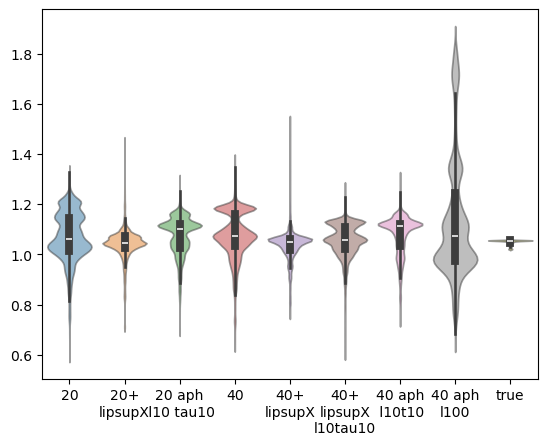

In [196]:
sns.violinplot(pd.DataFrame({
    "20":lip_data_none_aug20,
    "20+"+"\n"+"lipsupX": lip_data_lipsupX20,
    "20 aph"+"\n"+" l10 tau10": lip_data_aph20_l10_tau10,
    "40":lip_data_none_aug40,
    "40+"+"\n"+"lipsupX": lip_data_lipsupX40,
    "40+"+"\n"+"lipsupX"+"\n"+"l10tau10": lip_data_lipsupX_40_l10_tau10,
    "40 aph"+"\n"+" l10t10": lip_data_aph_40_l10_tau10, 
    "40 aph"+"\n"+ "l100": lip_data_aph_40_l100,
    "true": lip_data_true}), alpha=0.5)#, color="blue", alpha=0.5)

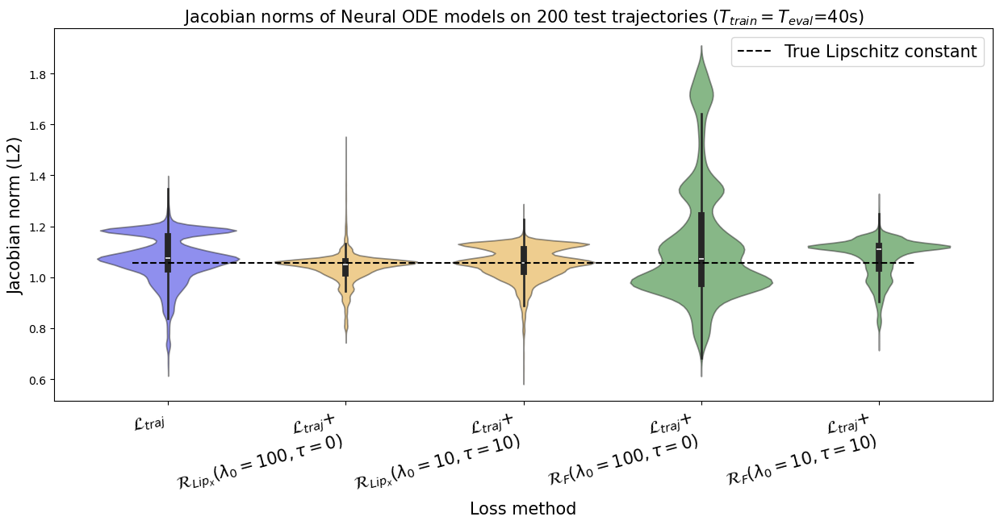

In [294]:
plt.figure(figsize=(15, 6))
palette = {
    r'$\mathcal{L}_{traj}$': 'blue',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=100, \tau=0)$': 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    #"True": '#8c564b'
}

sns.violinplot(pd.DataFrame({
    # "20":lip_data_none_aug20,
    # "20+"+"\n"+"lipsupX": lip_data_lipsupX20,
    # "20 aph"+"\n"+" l10 tau10": lip_data_aph20_l10_tau10,
    r'$\mathcal{L}_{traj}$':lip_data_none_aug40,
    r'$\mathcal{L}_{traj}$+'+'\n'+ r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$': lip_data_lipsupX40,
    r'$\mathcal{L}_{traj}$+'+'\n'+ r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': lip_data_lipsupX_40_l10_tau10,
    r'$\mathcal{L}_{traj}$+'+'\n'+ r'$\mathcal{R}_F(\lambda_0=100, \tau=0)$': lip_data_aph_40_l100,
    r'$\mathcal{L}_{traj}$+'+'\n'+ r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': lip_data_aph_40_l10_tau10, 
    #"True": lip_data_true,
    }), alpha=0.5, palette=palette, )#, color="blue", alpha=0.5)
plt.hlines(L_true, -0.2, 4.2, color='black', linestyle='--', label=r'True Lipschitz constant')
plt.title("Jacobian norms of Neural ODE models on 200 test trajectories ($T_{train}=T_{eval}$=40s)",fontsize=15)
plt.xlabel("Loss method",fontsize=15)
plt.ylabel("Jacobian norm (L2)",fontsize=15)
plt.xticks(rotation=15, ha='right', fontsize=15) 
plt.legend(fontsize=15)

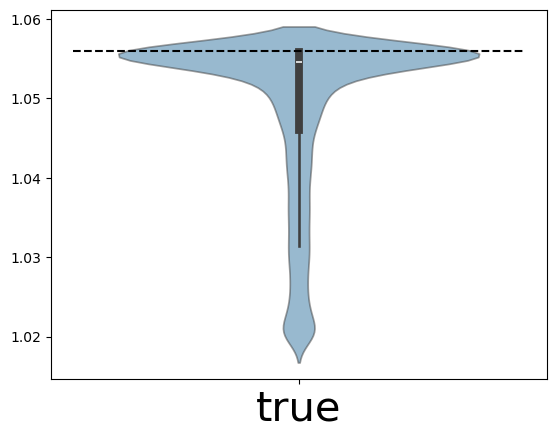

In [291]:
sns.violinplot(pd.DataFrame({
    "true": lip_data_true,}), alpha=0.5)#, color="blue", alpha=0.5)
plt.xticks( fontsize=30)
plt.hlines(L_true,-0.5,0.5, color='black', linestyle='--', label=r'$L=\sqrt{1+\alpha^2+\omega_0^4}$')

Text(0.5, 1.0, 'Jacobian norm of Neural ODE models + Lip loss(X) on 200 test trajectories ($T_{eval}$=40s)')

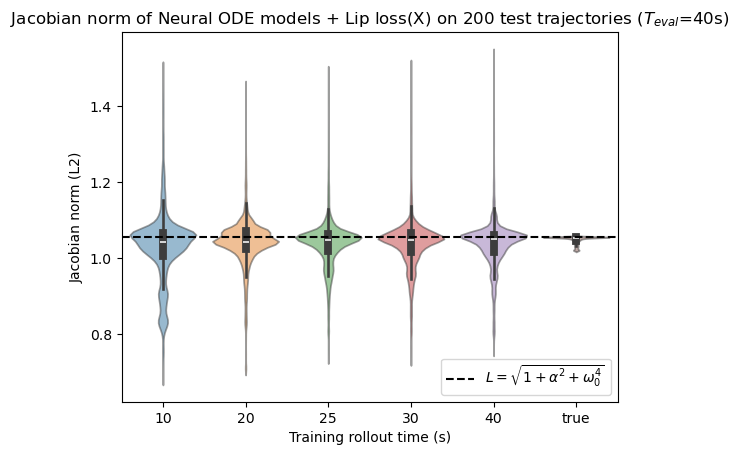

In [269]:
sns.violinplot(df_lip_curr_lipsupX, alpha=0.5)#, color="blue", alpha=0.5) 

plt.axhline(L_true, color='black', linestyle='--', label=r'$L=\sqrt{1+\alpha^2+\omega_0^4}$')
plt.ylabel("Jacobian norm (L2)")
plt.xlabel("Training rollout time (s)")
plt.legend()
plt.title(r"Jacobian norm of Neural ODE models + Lip loss(X) on 200 test trajectories ($T_{eval}$=40s)")

## On predicted trajectories

In [185]:
# none aug
y_pred_40s_none_aug_10 = get_y_states40s_pred(data_none_aug10)
y_pred_40s_none_aug_15 = get_y_states40s_pred(data_none_aug15)
y_pred_40s_none_aug_20 = get_y_states40s_pred(data_none_aug20)
y_pred_40s_none_aug_25 = get_y_states40s_pred(data_none_aug25)
y_pred_40s_none_aug_30 = get_y_states40s_pred(data_none_aug30)
y_pred_40s_none_aug_35 = get_y_states40s_pred(data_none_aug35)
y_pred_40s_none_aug_40 = get_y_states40s_pred(data_none_aug40)
y_pred_40s_none_aug_50 = get_y_states40s_pred(data_none_aug50)

# fa prime supX
y_pred_40s_fa_prime_supX_10 = get_y_states40s_pred(data_fa_prime_supX10)
y_pred_40s_fa_prime_supX_20 = get_y_states40s_pred(data_fa_prime_supX20)
y_pred_40s_fa_prime_supX_25 = get_y_states40s_pred(data_fa_prime_supX25)
y_pred_40s_fa_prime_supX_30 = get_y_states40s_pred(data_fa_prime_supX30)
y_pred_40s_fa_prime_supX_40 = get_y_states40s_pred(data_fa_prime_supX40)
# fa prime supX l10 tau10
y_pred_40s_fa_prime_supX_40_l10_tau10 = get_y_states40s_pred(data_fa_prime_supX40_l10_tau10)
y_pred_40s_fa_prime_supX_20_l10_tau10 = get_y_states40s_pred(data_fa_prime_supX20_l10_tau10)

# aph l10 tau10
y_pred_40s_aph_20_l10_tau10 = get_y_states40s_pred(data_aph_20_l10_tau10)
y_pred_40s_aph_40_l10_tau10 = get_y_states40s_pred(data_aph_40_l10_tau10)


In [186]:
# lip data
lip_data_none_aug10_pred = compute_jacobian_test(model_none_aug10, y_pred_40s_none_aug_10)
lip_data_none_aug15_pred = compute_jacobian_test(model_none_aug15, y_pred_40s_none_aug_15)
lip_data_none_aug20_pred = compute_jacobian_test(model_none_aug20, y_pred_40s_none_aug_20)
lip_data_none_aug25_pred = compute_jacobian_test(model_none_aug25, y_pred_40s_none_aug_25)
lip_data_none_aug30_pred = compute_jacobian_test(model_none_aug30, y_pred_40s_none_aug_30)
lip_data_none_aug35_pred = compute_jacobian_test(model_none_aug35, y_pred_40s_none_aug_35)
lip_data_none_aug40_pred = compute_jacobian_test(model_none_aug40, y_pred_40s_none_aug_40)
lip_data_none_aug50_pred = compute_jacobian_test(model_none_aug50, y_pred_40s_none_aug_50)

# fa prime supX
lip_data_fa_prime_supX10_pred = compute_jacobian_test(model_lipsupX10, y_pred_40s_fa_prime_supX_10)
lip_data_fa_prime_supX20_pred = compute_jacobian_test(model_lipsupX20, y_pred_40s_fa_prime_supX_20)
lip_data_fa_prime_supX25_pred = compute_jacobian_test(model_lipsupX25, y_pred_40s_fa_prime_supX_25)
lip_data_fa_prime_supX30_pred = compute_jacobian_test(model_lipsupX30, y_pred_40s_fa_prime_supX_30)
lip_data_fa_prime_supX40_pred = compute_jacobian_test(model_lipsupX40, y_pred_40s_fa_prime_supX_40)

lip_data_fa_prime_supX20_l10_tau10_pred = compute_jacobian_test(model_lipsupX20_l10_tau10, y_pred_40s_fa_prime_supX_20_l10_tau10)
lip_data_fa_prime_supX40_l10_tau10_pred = compute_jacobian_test(model_lipsupX40_l10_tau10, y_pred_40s_fa_prime_supX_40_l10_tau10)

# aph
lip_data_aph_20_l10_tau10_pred = compute_jacobian_test(model_aph_20_l10_tau10, y_pred_40s_aph_20_l10_tau10)
lip_data_aph_40_l10_tau10_pred = compute_jacobian_test(model_aph_40_l10_tau10, y_pred_40s_aph_40_l10_tau10)


In [187]:
df_lip_curr_pred = pd.DataFrame({
    "10": lip_data_none_aug10_pred,
    "15": lip_data_none_aug15_pred,
    "20": lip_data_none_aug20_pred,
    "25": lip_data_none_aug25_pred,
    "30": lip_data_none_aug30_pred,
    "35": lip_data_none_aug35_pred,
    "40": lip_data_none_aug40_pred,
    "50": lip_data_none_aug50_pred,
    "true": lip_data_true
})

df_lip_curr_pred_lipsupX = pd.DataFrame({
    "10": lip_data_fa_prime_supX10_pred,
    "20": lip_data_fa_prime_supX20_pred,
    "25": lip_data_fa_prime_supX25_pred,
    "30": lip_data_fa_prime_supX30_pred,
    "40": lip_data_fa_prime_supX40_pred,
    "true": lip_data_true
})


Text(0.5, 1.0, 'Jacobian norm of Neural ODE models on 200 predicted trajectories ($T_{eval}$=40s)')

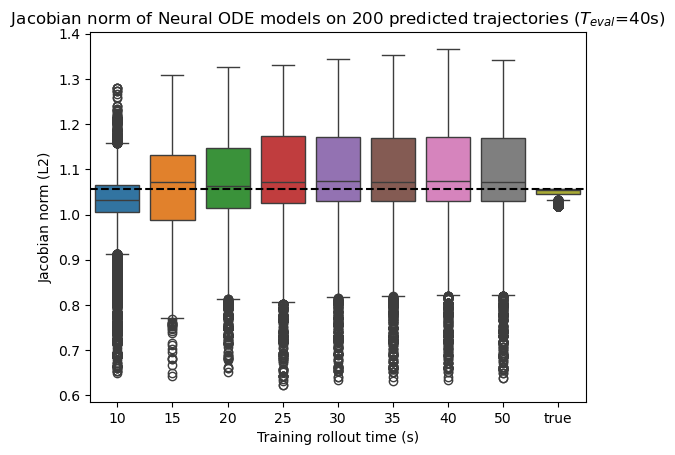

In [113]:
sns.boxplot(df_lip_curr_pred) 
plt.axhline(L_true, color='black', linestyle='--', label='True Lipschitz constant')
plt.ylabel("Jacobian norm (L2)")
plt.xlabel("Training rollout time (s)")
plt.title(r"Jacobian norm of Neural ODE models on 200 predicted trajectories ($T_{eval}$=40s)")

Text(0.5, 1.0, 'Jacobian norm of Neural ODE models on 200 predicted trajectories ($T_{eval}$=40s)')

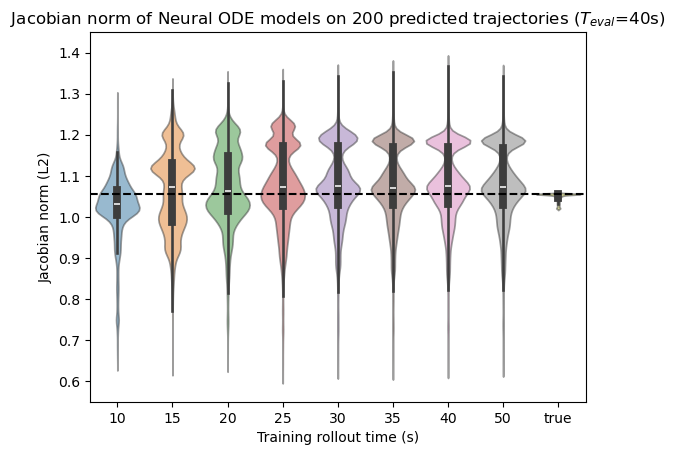

In [134]:
sns.violinplot(df_lip_curr_pred, alpha=0.5)#, color="blue", alpha=0.5) 
plt.axhline(L_true, color='black', linestyle='--', label='True Lipschitz constant')
plt.ylim(0.55,1.45)
plt.ylabel("Jacobian norm (L2)")
plt.xlabel("Training rollout time (s)")
plt.title(r"Jacobian norm of Neural ODE models on 200 predicted trajectories ($T_{eval}$=40s)")

Text(0.5, 1.0, 'Jacobian norm of Neural ODE models on 200 predicted trajectories ($T_{eval}$=40s)')

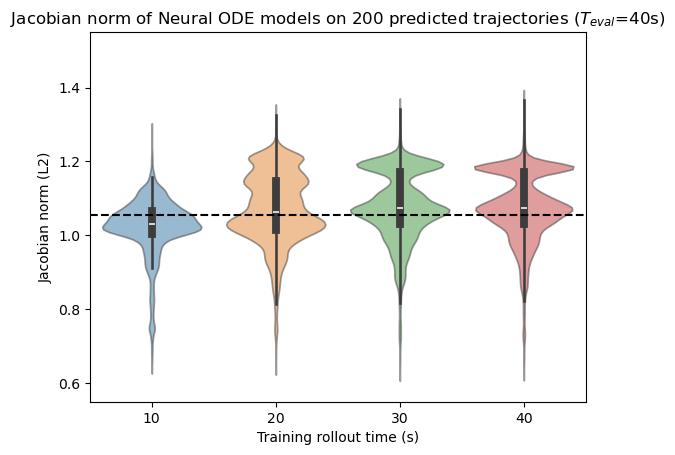

In [184]:
sns.violinplot(df_lip_curr_pred[["10", "20", "30", "40"]], alpha=0.5)#, color="blue", alpha=0.5) 
plt.axhline(L_true, color='black', linestyle='--', label='True Lipschitz constant')
plt.ylim(0.55,1.55)
plt.ylabel("Jacobian norm (L2)")
plt.xlabel("Training rollout time (s)")
plt.title(r"Jacobian norm of Neural ODE models on 200 predicted trajectories ($T_{eval}$=40s)")

Text(0.5, 1.0, 'Jacobian norm of Neural ODE models + Lipsup(X) on 200 predicted trajectories ($T_{eval}$=40s)')

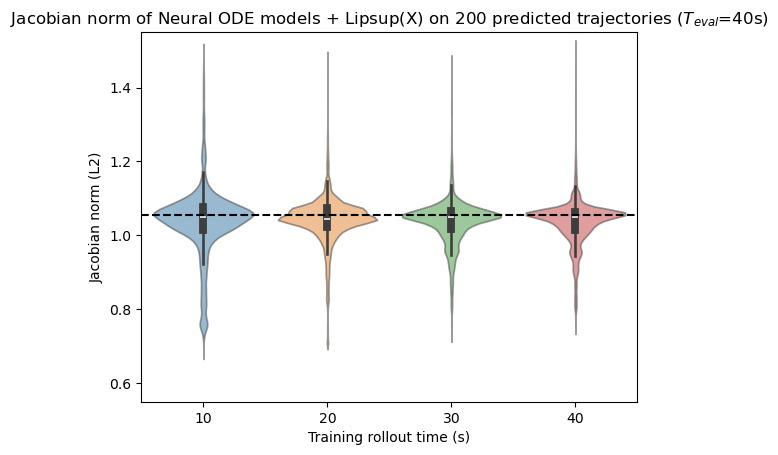

In [189]:
sns.violinplot(df_lip_curr_pred_lipsupX[["10", "20", "30", "40"]], alpha=0.5)#, color="blue", alpha=0.5) 
plt.axhline(L_true, color='black', linestyle='--', label='True Lipschitz constant')
plt.ylim(0.55,1.55)
plt.ylabel("Jacobian norm (L2)")
plt.xlabel("Training rollout time (s)")
plt.title(r"Jacobian norm of Neural ODE models + Lipsup(X) on 200 predicted trajectories ($T_{eval}$=40s)")

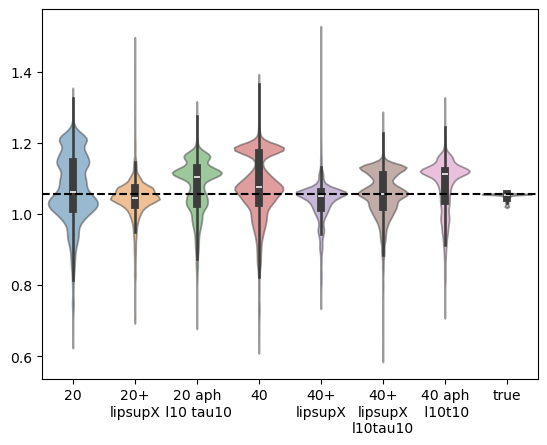

In [191]:
sns.violinplot(pd.DataFrame({
    "20": lip_data_none_aug20_pred,
    "20+"+"\n"+"lipsupX": lip_data_fa_prime_supX20_pred,
    #"20+"+"\n"+"lipsupX"+"\n"+"l10tau10": lip_data_fa_prime_supX20_l10_tau10_pred,
    "20 aph"+"\n"+" l10 tau10": lip_data_aph_20_l10_tau10_pred,
    "40": lip_data_none_aug40_pred,
    "40+"+"\n"+"lipsupX": lip_data_fa_prime_supX40_pred,
    "40+"+"\n"+"lipsupX"+"\n"+"l10tau10": lip_data_fa_prime_supX40_l10_tau10_pred,
    "40 aph"+"\n"+" l10t10": lip_data_aph_40_l10_tau10_pred,
    "true": lip_data_true
}), alpha=0.5)
plt.axhline(L_true, color='black', linestyle='--', label='True Lipschitz constant')


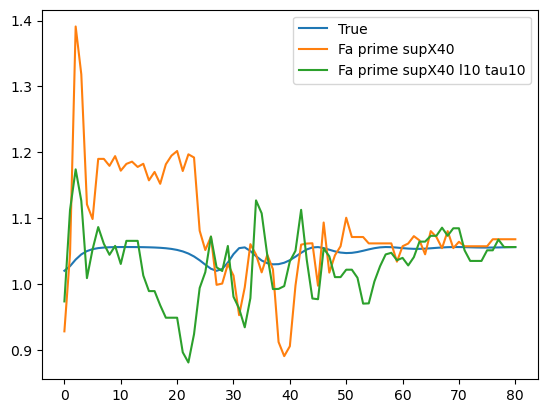

In [206]:
k=187
200 * 81, lip_data_true.shape
plt.plot(lip_data_true[(k)*81:(k+1)*81], label="True")
#plt.plot(lip_data_true[81:162])#
#plt.plot(lip_data_none_aug20_pred[(k)*81:(k+1)*81],label="T=20s")
#plt.plot(lip_data_none_aug40_pred[(k)*81:(k+1)*81],label="T=40s")
# plt.plot(lip_data_aph_40_l10_tau10_pred[(k)*81:(k+1)*81], label="APH T=40s")
plt.plot(lip_data_fa_prime_supX40_pred[(k)*81:(k+1)*81], label="Fa prime supX40")
plt.plot(lip_data_fa_prime_supX40_l10_tau10_pred[(k)*81:(k+1)*81], label="Fa prime supX40 l10 tau10")
plt.legend()



model_aph_20_l10_tau10

### OOD 

In [215]:
from solvers.runge_kutta import RK_solver_fixed, RK_tableaux

In [220]:
true_traj.shape

AttributeError: 'tuple' object has no attribute 'shape'

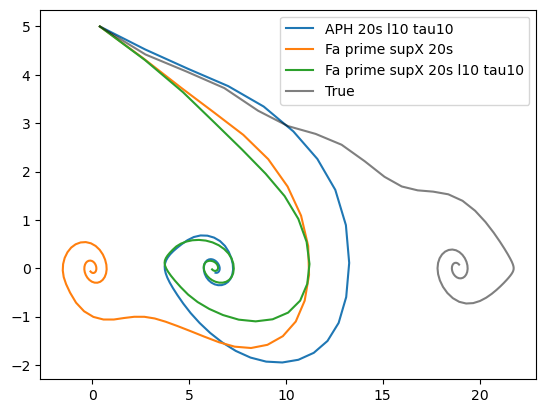

In [222]:
y0 = jnp.array([0.4, 5])
true_traj,_,_,_ = RK_solver_fixed(F, y0, 0.5, 81, tableau=RK_tableaux["RK4"])
pred_aph_20_l10_tau10 = model_aph_20_l10_tau10(y0)
pred_fa_prime_supX_20 = model_lipsupX20(y0)
pred_fa_prime_supX_20_l10_tau10 = model_lipsupX20_l10_tau10(y0)
plt.plot(pred_aph_20_l10_tau10[0,:], pred_aph_20_l10_tau10[1,:], label='APH 20s l10 tau10')
plt.plot(pred_fa_prime_supX_20[0,:], pred_fa_prime_supX_20[1,:], label='Fa prime supX 20s')
plt.plot(pred_fa_prime_supX_20_l10_tau10[0,:], pred_fa_prime_supX_20_l10_tau10[1,:], label='Fa prime supX 20s l10 tau10')
plt.plot(true_traj[0,:], true_traj[1,:], label='True', alpha=0.5, color='black')
plt.legend()

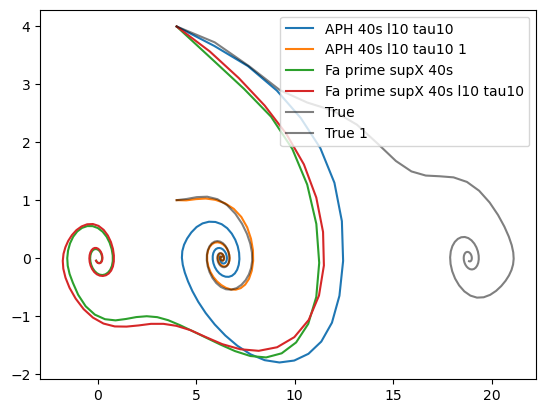

In [233]:
y0 = jnp.array([4.,4.])
y1 = jnp.array([4., 1.])
true_traj,_,_,_ = RK_solver_fixed(F, y0, 0.5, 81, tableau=RK_tableaux["RK4"])
true_traj_1, _,_,_ = RK_solver_fixed(F, y1, 0.5, 81, tableau=RK_tableaux["RK4"])
pred_aph_40_l10_tau10 = model_aph_40_l10_tau10(y0)
pred_aph_40_l10_tau10_1 = model_aph_40_l10_tau10(y1)
pred_fa_prime_supX_40 = model_lipsupX40(y0)
pred_fa_prime_supX_40_l10_tau10 = model_lipsupX40_l10_tau10(y0)
plt.plot(pred_aph_40_l10_tau10[0,:], pred_aph_40_l10_tau10[1,:], label='APH 40s l10 tau10')
plt.plot(pred_aph_40_l10_tau10_1[0,:], pred_aph_40_l10_tau10_1[1,:], label='APH 40s l10 tau10 1')
plt.plot(pred_fa_prime_supX_40[0,:], pred_fa_prime_supX_40[1,:], label='Fa prime supX 40s')
plt.plot(pred_fa_prime_supX_40_l10_tau10[0,:], pred_fa_prime_supX_40_l10_tau10[1,:], label='Fa prime supX 40s l10 tau10')
plt.plot(true_traj[0,:], true_traj[1,:], label='True', alpha=0.5, color='black')
plt.plot(true_traj_1[0,:], true_traj_1[1,:], label='True 1', alpha=0.5, color='black')
plt.legend()

# Lorenz chaotique: peut être regarder en moins chaotique pour l'analyse de stabilité ?

## Utils

In [4]:
def get_yL_states10s(dataframe, type='lorenz', bool_true=True):
    y_list = []
    if type == "pendulum":
        for i,data in enumerate(dataframe):
            states = jnp.array(data['states'])
            for j in range(states.shape[2]):
                y_list.append(states[0,:,j])
            # if i == 24:
            #     break
    elif type == "lorenz":
        if bool_true:
            states = dataframe['y_true']
        else:
            states = dataframe['y_pred']
        for i in range(states.shape[0]):
            #print(states.shape, states[i].shape)
            for j in range(states[0].shape[1]):
            #print(states.shape)
                y_list.append(states[i][:,j])
    y_list = np.array(y_list)
    print(y_list.shape, y_list[0].shape)
    return y_list

yL_10s = get_yL_states10s(data_none_aug01)

NameError: name 'data_none_aug01' is not defined

In [5]:
from scipy.stats import entropy
def compute_metrics_lorenz(data, compute_phy=True, eps=0.01):
    data["y_true"] = data["y_true"].apply(lambda x: np.array(x))
    data["y_pred"] = data["y_pred"].apply(lambda x: np.array(x))
    data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
    data["L2_5s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:501] - x["y_pred"][:,:501])**2)), axis=1)
    data["L2_0.5s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:51] - x["y_pred"][:,:51])**2)), axis=1)
    data["L2_0.1s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:11] - x["y_pred"][:,:11])**2)), axis=1)

    # compute KDE and KL divergence
    # shared bins between y_true and y_pred
    # data["x_min"] = data.apply(lambda x: np.min(np.concatenate((x["y_true"][0], x["y_pred"][0]))), axis=1)
    # data["x_max"] = data.apply(lambda x: np.max(np.concatenate((x["y_true"][0], x["y_pred"][0]))), axis=1)
    # data["y_min"] = data.apply(lambda x: np.min(np.concatenate((x["y_true"][1], x["y_pred"][1]))), axis=1)
    # data["y_max"] = data.apply(lambda x: np.max(np.concatenate((x["y_true"][1], x["y_pred"][1]))), axis=1)
    # data["z_min"] = data.apply(lambda x: np.min(np.concatenate((x["y_true"][2], x["y_pred"][2]))), axis=1)
    # data["z_max"] = data.apply(lambda x: np.max(np.concatenate((x["y_true"][2], x["y_pred"][2]))), axis=1)

    # bins from true 
    data["x_min"] = data.apply(lambda x: np.min(x["y_true"][0]), axis=1)
    data["x_max"] = data.apply(lambda x: np.max(x["y_true"][0]), axis=1)
    data["y_min"] = data.apply(lambda x: np.min(x["y_true"][1]), axis=1)
    data["y_max"] = data.apply(lambda x: np.max(x["y_true"][1]), axis=1)
    data["z_min"] = data.apply(lambda x: np.min(x["y_true"][2]), axis=1)
    data["z_max"] = data.apply(lambda x: np.max(x["y_true"][2]), axis=1)
    # compute pdf
    data["x_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][0], bins=50, range=(x["x_min"], x["x_max"]), density=True)[0], axis=1)
    data["x_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][0], bins=50, range=(x["x_min"], x["x_max"]), density=True)[0], axis=1)
    data["y_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][1], bins=50, range=(x["y_min"], x["y_max"]), density=True)[0], axis=1)
    data["y_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][1], bins=50, range=(x["y_min"], x["y_max"]), density=True)[0], axis=1)
    data["z_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][2], bins=50, range=(x["z_min"], x["z_max"]), density=True)[0], axis=1)
    data["z_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][2], bins=50, range=(x["z_min"], x["z_max"]), density=True)[0], axis=1)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    for key in ["x_pdf_true", "x_pdf_pred", "y_pdf_true", "y_pdf_pred", "z_pdf_true", "z_pdf_pred"]:
        data[key] = data[key].apply(lambda x: x + epsilon)

    # KL divergence
    data["KL_x"] = data.apply(lambda x: entropy(x["x_pdf_true"], x["x_pdf_pred"]), axis=1)
    data["KL_y"] = data.apply(lambda x: entropy(x["y_pdf_true"], x["y_pdf_pred"]), axis=1)
    data["KL_z"] = data.apply(lambda x: entropy(x["z_pdf_true"], x["z_pdf_pred"]), axis=1)
    return data

In [2]:
def plot_traj(true, pred, t, title) :
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    plt.title(title)
    ax.scatter(true[0, :], true[1, :], true[2, :], c= t, label="true", cmap='viridis')
    ax.scatter(pred[0, :], pred[1, :], pred[2, :], c= t, label="pred", cmap="spring")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

def plot_xyz(true,pred,title):
    fig, axs = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    fig.suptitle(title)
    axs[0].plot(true[0, :], label='True X', color='blue')
    axs[0].plot(pred[0, :], label='Predicted X', color='orange')
    axs[0].set_ylabel('X')
    axs[0].legend()

    axs[1].plot(true[1, :], label='True Y', color='blue')
    axs[1].plot(pred[1, :], label='Predicted Y', color='orange')
    axs[1].set_ylabel('Y')
    axs[1].legend()

    axs[2].plot(true[2, :], label='True Z', color='blue')
    axs[2].plot(pred[2, :], label='Predicted Z', color='orange')
    axs[2].set_xlabel('Time step')
    axs[2].set_ylabel('Z')
    axs[2].legend()

    plt.tight_layout()
    # set lim axes
    axs[0].set_ylim([-40, 60])
    axs[1].set_ylim([-40, 40])
    axs[2].set_ylim([-20, 80])
    plt.show()

In [7]:
# visualize pdf of three states
def plot_pdf(true, pred, title):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title)
    axs[0].hist(true[0, :], bins=50, alpha=0.5, label='True X', color='blue', density=True)
    axs[0].hist(pred[0, :], bins=50, alpha=0.5, label='Predicted X', color='orange', density=True)
    axs[0].set_title('X distribution')
    axs[0].set_ylim(0,0.15)
    axs[0].set_xlim(-20,20)
    axs[0].legend()

    axs[1].hist(true[1, :], bins=50, alpha=0.5, label='True Y', color='blue', density=True)
    axs[1].hist(pred[1, :], bins=50, alpha=0.5, label='Predicted Y', color='orange', density=True)
    axs[1].set_title('Y distribution')
    axs[1].set_ylim(0,0.1)
    axs[1].set_xlim(-30,25)
    axs[1].legend()

    axs[2].hist(true[2, :], bins=50, alpha=0.5, label='True Z', color='blue', density=True)
    axs[2].hist(pred[2, :], bins=50, alpha=0.5, label='Predicted Z', color='orange', density=True)
    axs[2].set_ylim(0,0.1)
    axs[2].set_xlim(0,50)
    axs[2].set_title('Z distribution')
    axs[2].legend()

    plt.tight_layout()
    plt.show()


In [8]:
def plot_mse_time(true, pred, title):
    mse = np.mean((true - pred)**2, axis=0)
    plt.figure(figsize=(10, 6))
    plt.plot(mse, label='MSE', color='blue')
    plt.title(title)
    plt.xlabel('Time step')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.grid()
    plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def plot_pdf_with_kl(true, pred, title):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title)

    # Axis limits for consistency
    limits = [(-20, 20), (-30, 25), (0, 50)]
    ymax = [0.15, 0.1, 0.1]
    kl_divs = []

    for i, ax in enumerate(axs):
        # Shared bins based on combined true+pred
        data_min = min(true[i, :].min(), pred[i, :].min())
        data_max = max(true[i, :].max(), pred[i, :].max())
        bins = np.linspace(data_min, data_max, 50)

        # Compute histograms (PDFs)
        true_pdf, _ = np.histogram(true[i, :], bins=bins, density=True)
        pred_pdf, _ = np.histogram(pred[i, :], bins=bins, density=True)

        # Add small epsilon to avoid log(0)
        epsilon = 1e-10
        true_pdf += epsilon
        pred_pdf += epsilon

        # KL divergence
        kl = entropy(true_pdf, pred_pdf)
        kl_divs.append(kl)

        # Plot histograms
        ax.hist(true[i, :], bins=bins, alpha=0.5, label=f'True {["X", "Y", "Z"][i]}', color='blue', density=True)
        ax.hist(pred[i, :], bins=bins, alpha=0.5, label=f'Predicted {["X", "Y", "Z"][i]}', color='orange', density=True)
        ax.set_title(f'{["X", "Y", "Z"][i]} distribution\nKL = {kl:.4f}')
        ax.set_xlim(limits[i])
        ax.set_ylim(0, ymax[i])
        ax.legend()

    plt.tight_layout()
    plt.show()

    return kl_divs

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, entropy

def plot_kde_with_kl(true, pred, title):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title)

    # Axis limits for each variable
    limits = [(-20, 20), (-30, 25), (0, 50)]
    ymax = [0.15, 0.1, 0.1]
    kl_divs = []

    for i, ax in enumerate(axs):
        # KDE estimates
        kde_true = gaussian_kde(true[i, :])
        kde_pred = gaussian_kde(pred[i, :])

        # Shared grid
        x_grid = np.linspace(limits[i][0], limits[i][1], 1000)
        pdf_true = kde_true(x_grid)
        pdf_pred = kde_pred(x_grid)

        # Avoid zeros for KL divergence
        epsilon = 1e-10
        pdf_true += epsilon
        pdf_pred += epsilon

        # Normalize to ensure they're true PDFs
        pdf_true /= np.trapz(pdf_true, x_grid)
        pdf_pred /= np.trapz(pdf_pred, x_grid)

        # KL divergence
        kl = entropy(pdf_true, pdf_pred)
        kl_divs.append(kl)

        # Plot KDE lines
        ax.plot(x_grid, pdf_true, label=f'True {["X", "Y", "Z"][i]}', color='blue')
        ax.plot(x_grid, pdf_pred, label=f'Predicted {["X", "Y", "Z"][i]}', color='orange')
        ax.set_title(f'{["X", "Y", "Z"][i]} PDF (KL={kl:.4f})')
        ax.set_xlim(limits[i])
        ax.set_ylim(0, ymax[i])
        ax.legend()

    plt.tight_layout()
    plt.show()
    return kl_divs



## Load data and models

In [6]:
path_1_long = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_1.0_1_lpirex33/model_4.397e+01_longrun_100.json"
path_05_long = '/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01_longrun_100.json'
path_05_long_nocurr = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_d7x29ou8/model_7.108e+01_longrun_100.json"
path_01_long = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.1_16_y4dgk7so/model_4.611e+01_longrun.json"

In [8]:
path_005_long = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.05_48_gtjvqwf1/model_8.976e+00_longrun_100.json"
path_002_long = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.02_52_pb6xaak6/model_2.684e+00_longrun_100.json"
path_001_long = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.01_56_xfw454hp/model_8.047e-01_longrun_100.json"

In [9]:
path_05_long_lipsupX = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_18_vzkua19c/model_4.768e+01_longrun_100.json" # l1 tau0
path_1_long_lipsupX = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_aug_1.0_20_ifl1kpia/model_4.449e+01_longrun_100.json" # l1 tau0
#path_05_long_lipsupX_l10_tau10 = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_23_bcaporpk/model_8.037e+01_longrun.json"

In [10]:
path_05_lon_lipsupX_l100 = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_38_6ip39mbt/model_6.805e+01_longrun_100.json"

In [11]:
path_05_long_lipsupX_l10_tau10 = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_23_bcaporpk/model_8.037e+01_longrun_100.json"
path_1_long_lipsupX_l10_tau10 = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_aug_1.0_36_u46i7ois/model_4.073e+01_longrun_100.json"
path_1_long_aph_l10_tau10 = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_aug_1.0_37_ynthb5uu/model_3.684e+01_longrun_100.json"

In [12]:
path_05_long_aph_l10_tau10 = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_aug_0.5_22_il3xfk60/model_8.008e+01_longrun_100.json"

In [13]:
# no curr
path_05_long_lipsupX_nocurr = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_27_16mx8mqy/model_7.176e+01_longrun_100.json" # l100 tau 0
path_05_long_aph_l10_tau10_nocurr = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_aug_0.5_29_0aonngt2/model_6.919e+01_longrun_100.json"
path_05_long_lipsupX_l10_tau10_nocurr = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_30_h4az6l6s/model_6.016e+01_longrun_100.json"

# sup direct
path_05_long_lipsupX_direct_nocurr = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_direct_aug_0.5_31_xur5ddcr/model_1.423e+02_longrun_100.json" # l100 tau0
path_05_long_lipsupX_direct_l10000_tau1000_nocurr = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_direct_aug_0.5_33_twgwtlpy/model_7.111e+01_longrun_100.json"
path_05_long_lipsupX_direct = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_Fa_prime_supX_direct_aug_0.5_35_307wy485/model_1.236e+02_longrun_100.json" # l100 tau0

In [14]:
results_none_aug1 = pd.read_json(path_1_long).T
results_none_aug05 = pd.read_json(path_05_long).T
results_none_aug05_nocurr = pd.read_json(path_05_long_nocurr).T
results_none_aug01 = pd.read_json(path_01_long).T

In [15]:
results_none_aug005 = pd.read_json(path_005_long).T
results_none_aug002 = pd.read_json(path_002_long).T
results_none_aug001 = pd.read_json(path_001_long).T

In [16]:
results_05_lipsupX = pd.read_json(path_05_long_lipsupX).T
results_1_lipsupX = pd.read_json(path_1_long_lipsupX).T
results_05_lipsupX_l10_tau10  = pd.read_json(path_05_long_lipsupX_l10_tau10).T
#results_05_lipsupX_l10_tau10_100  = pd.read_json(path_05_long100_lipsupX_l10_tau10).T
results_1_lipsupX_l10_tau10 = pd.read_json(path_1_long_lipsupX_l10_tau10).T
results_05_lipsupX_l100 = pd.read_json(path_05_lon_lipsupX_l100).T

In [17]:
results_05_aph_l10_tau10 = pd.read_json(path_05_long_aph_l10_tau10).T
results_1_aph_l10_tau10 = pd.read_json(path_1_long_aph_l10_tau10).T

In [18]:
results_05_lipsupsX_nocurr = pd.read_json(path_05_long_lipsupX_nocurr).T
results_05_aph_l10_tau10_nocurr = pd.read_json(path_05_long_aph_l10_tau10_nocurr).T
results_05_lipsupX_l10_tau10_nocurr = pd.read_json(path_05_long_lipsupX_l10_tau10_nocurr).T
results_05_lipsupX_direct_nocurr = pd.read_json(path_05_long_lipsupX_direct_nocurr).T
results_05_lipsupX_direct_l10000_tau1000_nocurr = pd.read_json(path_05_long_lipsupX_direct_l10000_tau1000_nocurr).T
results_05_lipsupX_direct = pd.read_json(path_05_long_lipsupX_direct).T

In [ ]:
data_none_aug1 = compute_metrics_lorenz(results_none_aug1, compute_phy=True, eps=0.01)
data_none_aug05 = compute_metrics_lorenz(results_none_aug05, compute_phy=True, eps=0.01)
data_none_aug05_nocurr = compute_metrics_lorenz(results_none_aug05_nocurr, compute_phy=True, eps=0.01)
data_none_aug01 = compute_metrics_lorenz(results_none_aug01, compute_phy=True, eps=0.01)

In [ ]:
data_none_aug005 = compute_metrics_lorenz(results_none_aug005, compute_phy=True, eps=0.01)
data_none_aug002 = compute_metrics_lorenz(results_none_aug002, compute_phy=True, eps=0.01)
data_none_aug001 = compute_metrics_lorenz(results_none_aug001, compute_phy=True, eps=0.01)

In [ ]:
data_05_lipsupX = compute_metrics_lorenz(results_05_lipsupX, compute_phy=True, eps=0.01)
data_1_lipsupX = compute_metrics_lorenz(results_1_lipsupX, compute_phy=True, eps=0.01)
data_05_lipsupX_l10_tau10 = compute_metrics_lorenz(results_05_lipsupX_l10_tau10, compute_phy=True, eps=0.01)
data_1_lipsupX_l10_tau10 = compute_metrics_lorenz(results_1_lipsupX_l10_tau10, compute_phy=True, eps=0.01)
data_05_lipsupX_l100 = compute_metrics_lorenz(results_05_lipsupX_l100, compute_phy=True, eps=0.01)

In [24]:
#data_05_lipsupX_l10_tau10_100 = compute_metrics_lorenz(results_05_lipsupX_l10_tau10_100, compute_phy=True, eps=0.01)

In [139]:
data_05_aph_l10_tau10 = compute_metrics_lorenz(results_05_aph_l10_tau10, compute_phy=True, eps=0.01)
data_1_aph_l10_tau10 = compute_metrics_lorenz(results_1_aph_l10_tau10, compute_phy=True, eps=0.01)

In [60]:
data_05_lipsupX_nocurr = compute_metrics_lorenz(results_05_lipsupsX_nocurr, compute_phy=True, eps=0.01)
data_05_aph_l10_tau10_nocurr = compute_metrics_lorenz(results_05_aph_l10_tau10_nocurr, compute_phy=True, eps=0.01)
data_05_lipsupX_l10_tau10_nocurr = compute_metrics_lorenz(results_05_lipsupX_l10_tau10_nocurr, compute_phy=True, eps=0.01)

In [100]:
data_05_lipsupX_direct_nocurr = compute_metrics_lorenz(results_05_lipsupX_direct_nocurr, compute_phy=True, eps=0.01)
data_05_lipsupX_direct_l10000_tau1000_nocurr = compute_metrics_lorenz(results_05_lipsupX_direct_l10000_tau1000_nocurr, compute_phy=True, eps=0.01)
data_05_lipsupX_direct = compute_metrics_lorenz(results_05_lipsupX_direct, compute_phy=True, eps=0.01)

In [250]:
# "model_4.474e-03.eqx", "none_aug_10_7_wni7d7vw", "data/pendulum_curriculum", "none", True, "pendulum", "RK4", dt_num=0.5
model_none_aug05 = load_model_40s("model_8.569e+01.eqx", "none_aug_0.5_12_h8nc71jn", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_none_aug1 = load_model_40s("model_4.397e+01.eqx", "none_aug_1.0_1_lpirex33", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_none_aug05_nocurr = load_model_40s("model_7.108e+01.eqx", "none_aug_0.5_12_d7x29ou8", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_none_aug01 = load_model_40s("model_4.611e+01.eqx", "none_aug_0.1_16_y4dgk7so", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)

model_lipsupX05 = load_model_40s("model_4.768e+01.eqx", "none_Fa_prime_supX_aug_0.5_18_vzkua19c", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_lipsupX1 = load_model_40s("model_4.449e+01.eqx", "none_Fa_prime_supX_aug_1.0_20_ifl1kpia", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_lipsupX05_l10_tau10 = load_model_40s("model_8.037e+01.eqx", "none_Fa_prime_supX_aug_0.5_23_bcaporpk", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_lipsupX1_l10_tau10 = load_model_40s("model_4.073e+01.eqx", "none_Fa_prime_supX_aug_1.0_36_u46i7ois", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_lipsupX05_l100 = load_model_40s("model_6.805e+01.eqx", "none_Fa_prime_supX_aug_0.5_38_6ip39mbt", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)

model_aph_05_l10_tau10 = load_model_40s("model_8.008e+01.eqx", "none_Fa_aug_0.5_22_il3xfk60", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_aph_1_l10_tau10 = load_model_40s("model_3.684e+01.eqx", "none_Fa_aug_1.0_37_ynthb5uu", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
# nocurr
model_lipsupX05_nocurr = load_model_40s("model_7.176e+01.eqx", "none_Fa_prime_supX_aug_0.5_27_16mx8mqy", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_aph_05_l10_tau10_nocurr = load_model_40s("model_6.919e+01.eqx", "none_Fa_aug_0.5_29_0aonngt2", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)


data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01.eqx
0.01 1
data/lorenz_curriculum/none_aug_1.0_1_lpirex33/model_4.397e+01.eqx
0.01 1
data/lorenz_curriculum/none_aug_0.5_12_d7x29ou8/model_7.108e+01.eqx
0.01 1
data/lorenz_curriculum/none_aug_0.1_16_y4dgk7so/model_4.611e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_18_vzkua19c/model_4.768e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_prime_supX_aug_1.0_20_ifl1kpia/model_4.449e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_23_bcaporpk/model_8.037e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_prime_supX_aug_1.0_36_u46i7ois/model_4.073e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_38_6ip39mbt/model_6.805e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_aug_0.5_22_il3xfk60/model_8.008e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_aug_1.0_37_ynthb5uu/model_3.684e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_27_16mx8mqy/model_7.176e+01.eqx
0.01 1
data/lorenz

In [101]:
model_lipsupX05_l10_tau10_nocurr = load_model_40s("model_6.016e+01.eqx", "none_Fa_prime_supX_aug_0.5_30_h4az6l6s", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_lipsupX05_direct_nocurr = load_model_40s("model_1.423e+02.eqx", "none_Fa_prime_supX_direct_aug_0.5_31_xur5ddcr", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_lipsupX05_direct_l10000_tau1000_nocurr = load_model_40s("model_7.111e+01.eqx", "none_Fa_prime_supX_direct_aug_0.5_33_twgwtlpy", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
model_lipsupX05_direct = load_model_40s("model_1.236e+02.eqx", "none_Fa_prime_supX_direct_aug_0.5_35_307wy485", "data/lorenz_curriculum", "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)

data/lorenz_curriculum/none_Fa_prime_supX_aug_0.5_30_h4az6l6s/model_6.016e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_prime_supX_direct_aug_0.5_31_xur5ddcr/model_1.423e+02.eqx
0.01 1
data/lorenz_curriculum/none_Fa_prime_supX_direct_aug_0.5_33_twgwtlpy/model_7.111e+01.eqx
0.01 1
data/lorenz_curriculum/none_Fa_prime_supX_direct_aug_0.5_35_307wy485/model_1.236e+02.eqx
0.01 1


### trials

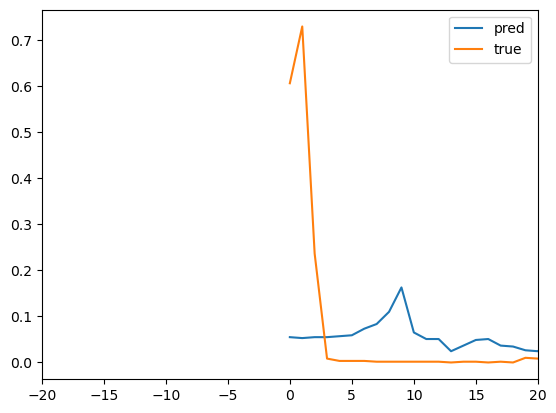

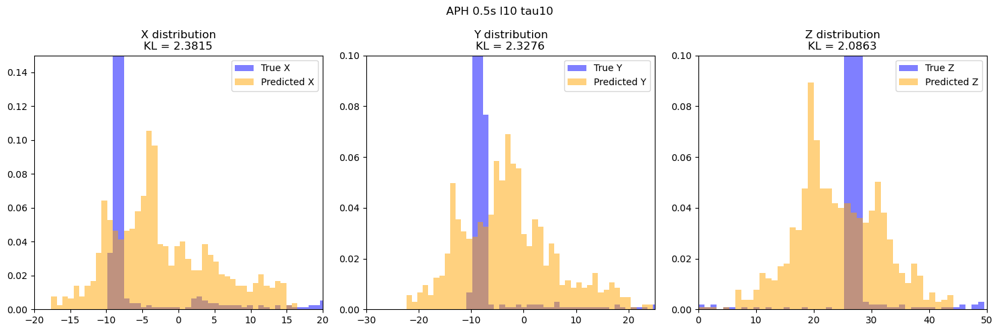

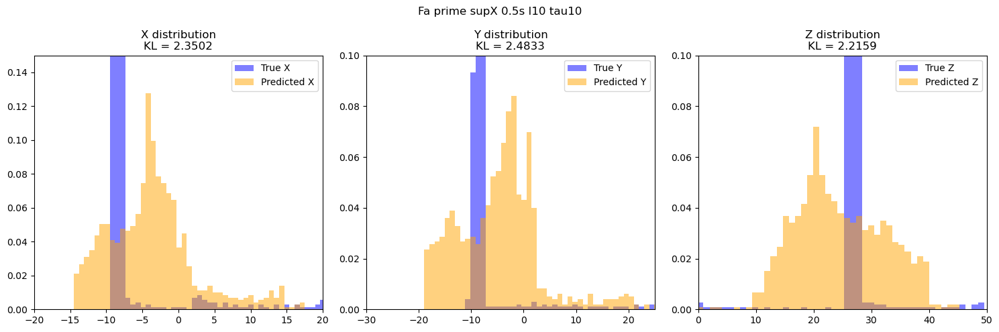

[2.350150123370903, 2.4833078242005397, 2.2158535724817305]

In [402]:
k=12
plt.plot(data_05_aph_l10_tau10["x_pdf_pred"][k], label="pred")
plt.plot(data_05_aph_l10_tau10["x_pdf_true"][k], label="true")
plt.xlim(-20, 20)
plt.legend()

plot_pdf_with_kl(data_05_aph_l10_tau10["y_true"][k], data_05_aph_l10_tau10["y_pred"][k], title="APH 0.5s l10 tau10")
plot_pdf_with_kl(data_05_lipsupX_l10_tau10["y_true"][k], data_05_lipsupX_l10_tau10["y_pred"][k], title="Fa prime supX 0.5s l10 tau10")

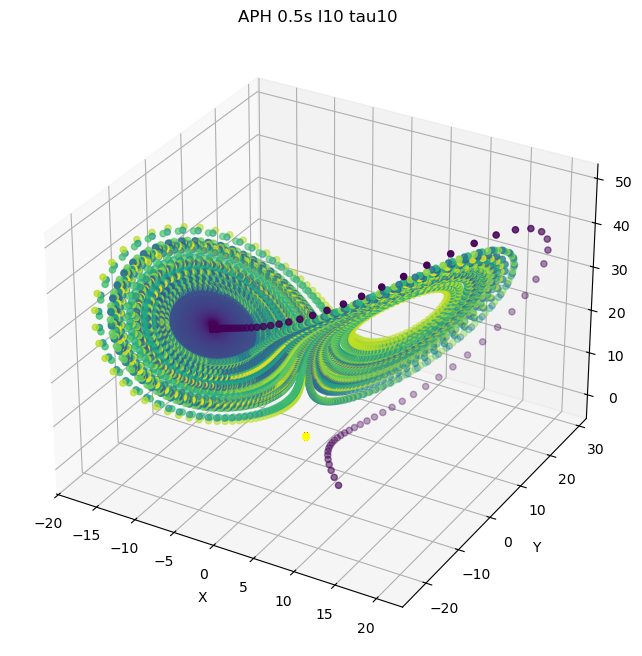

In [410]:
plot_traj(data_05_lipsupX_l10_tau10_100["y_true"][k], np.zeros_like(data_05_lipsupX_l10_tau10_100["y_true"][k]), np.arange(10001), title="APH 0.5s l10 tau10")

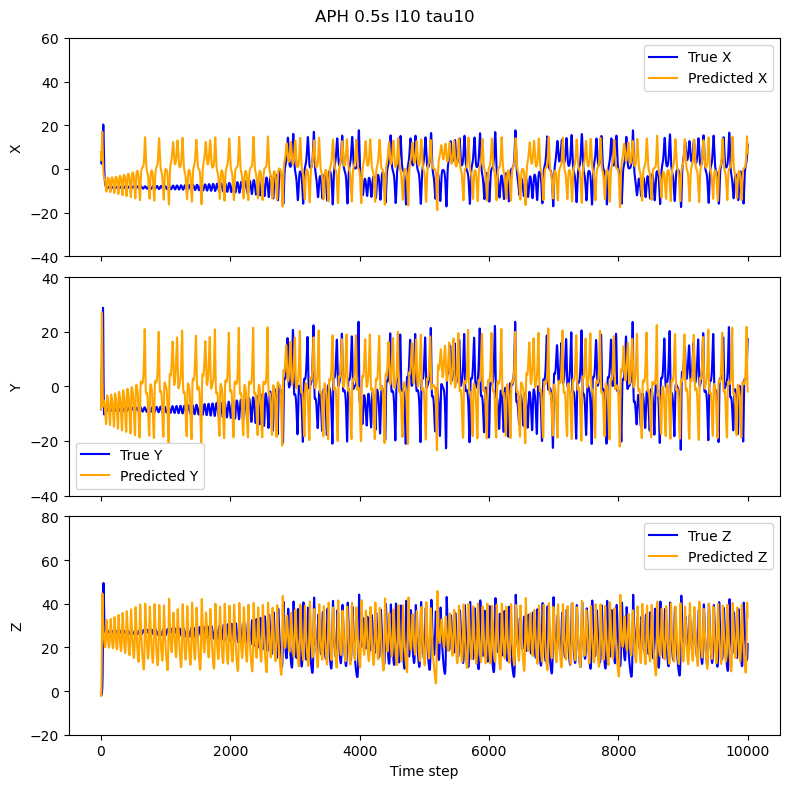

In [411]:
plot_xyz(data_05_lipsupX_l10_tau10_100["y_true"][k], data_05_lipsupX_l10_tau10_100["y_pred"][k], title="APH 0.5s l10 tau10")

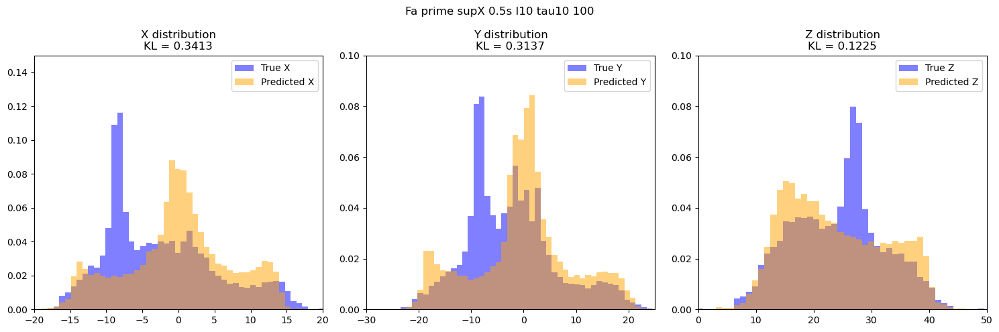

[0.3412563202879475, 0.3136912699561541, 0.12254707717053032]

In [412]:
plot_pdf_with_kl(data_05_lipsupX_l10_tau10_100["y_true"][k], data_05_lipsupX_l10_tau10_100["y_pred"][k], title="Fa prime supX 0.5s l10 tau10 100")

## MSE on 10s trajectories

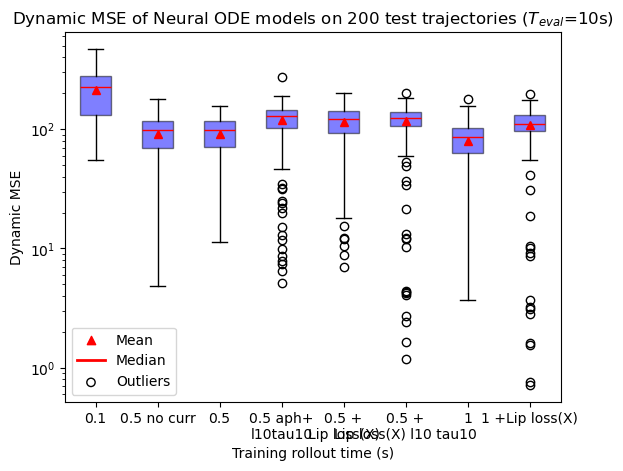

In [26]:
# boxplot meilleur
losses_traj = [
    data_none_aug01["L2"],
    data_none_aug05_nocurr["L2"],
    data_none_aug05["L2"],
    data_05_aph_l10_tau10["L2"],
    data_05_lipsupX_l10_tau10["L2"],
    data_05_lipsupX["L2"],
    data_none_aug1["L2"],
    data_1_lipsupX["L2"],
]

labels = [
    '0.1',
    r'0.5 no curr',
    r'0.5',
    "0.5 aph+" + "\n"+ "l10tau10",
    '0.5 +'+ "\n"+'Lip loss(X)', 
    "0.5 +" + "\n"+ "Lip loss(X) l10 tau10",
    r'1',
    '1 +Lip loss(X)',
          ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8])
ax.set_xticklabels(labels, rotation=0) #, ha='right')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')

# fill with colors
for patch in bplot['boxes']:
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor='blue', alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=10s)')
plt.show()

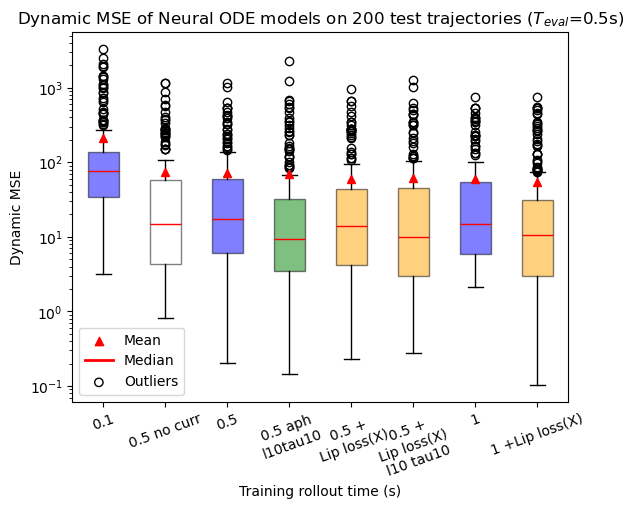

In [39]:
# boxplot meilleur
losses_traj = [
    data_none_aug01["L2_0.5s"],
    data_none_aug05_nocurr["L2_0.5s"],
    data_none_aug05["L2_0.5s"],
    data_05_aph_l10_tau10["L2_0.5s"],
    data_05_lipsupX["L2_0.5s"],
    data_05_lipsupX_l10_tau10["L2_0.5s"],
    data_none_aug1["L2_0.5s"],
    data_1_lipsupX["L2_0.5s"]
]

labels = [
    '0.1',
    r'0.5 no curr',
    r'0.5',
    "0.5 aph"+"\n"+"l10tau10",
    '0.5 +' +"\n"+'Lip loss(X)',
    "0.5 +"+ "\n"+ "Lip loss(X)"+ "\n"+ "l10 tau10",
    r'1',
    r'1 +Lip loss(X)',
        ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8])
ax.set_xticklabels(labels, rotation=20)#, ha='left')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')
colors = ["blue", "white", "blue", "green", "orange", "orange", "blue", "orange"]
# fill with colors
for i, patch in enumerate(bplot['boxes']):
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=0.5s)')
plt.show()

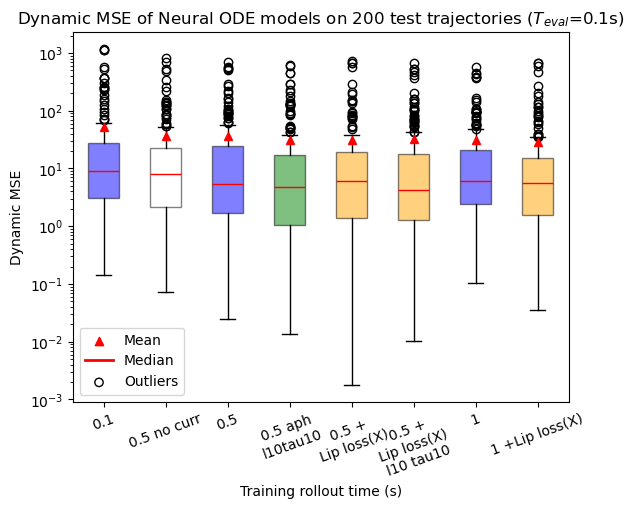

In [49]:
# boxplot meilleur
losses_traj = [
    data_none_aug01["L2_0.1s"],
    data_none_aug05_nocurr["L2_0.1s"],
    data_none_aug05["L2_0.1s"],
    data_05_aph_l10_tau10["L2_0.1s"],
    data_05_lipsupX["L2_0.1s"],
    data_05_lipsupX_l10_tau10["L2_0.1s"],
    data_none_aug1["L2_0.1s"],
    data_1_lipsupX["L2_0.1s"]
]

labels = [
    '0.1',
    r'0.5 no curr',
    r'0.5',
    "0.5 aph"+"\n"+"l10tau10",
    '0.5 +' +"\n"+'Lip loss(X)',
    "0.5 +"+ "\n"+ "Lip loss(X)"+ "\n"+ "l10 tau10",
    r'1',
    r'1 +Lip loss(X)',
        ]
colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Dynamic MSE')
ax.set_xlabel('Training rollout time (s)')

# orientation en biais
bplot = ax.boxplot(
    losses_traj,
    patch_artist=True,
    showmeans=True
)

ax.set_xticks([1, 2,3,4,5,6,7,8])
ax.set_xticklabels(labels, rotation=20)#, ha='left')
# dummy legend
mean_legend = plt.scatter([], [], color='red', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='red', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='lower left')
colors = ["blue", "white", "blue", "green", "orange", "orange", "blue", "orange"]
# fill with colors
for i, patch in enumerate(bplot['boxes']):
    #patch.set_facecolor('blue', alpha=0.5)
    patch.set(facecolor=colors[i], alpha=0.5)
# Change median line color
for median in bplot['medians']:
    median.set(color='red') #, linewidth=2)

# Change mean marker color
for mean in bplot['means']:
    mean.set(marker='^', markerfacecolor='red', markeredgecolor='red')

plt.title(r'Dynamic MSE of Neural ODE models on 200 test trajectories ($T_{eval}$'+f'=0.1s)')
plt.show()

## Trajectories

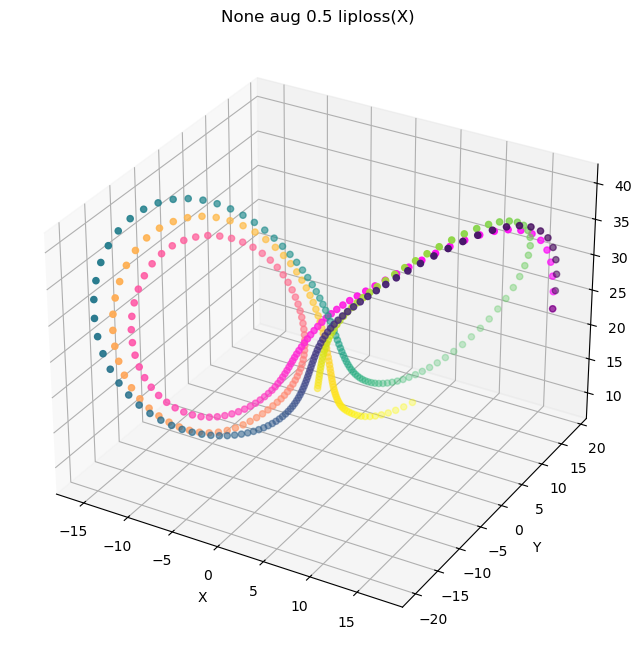

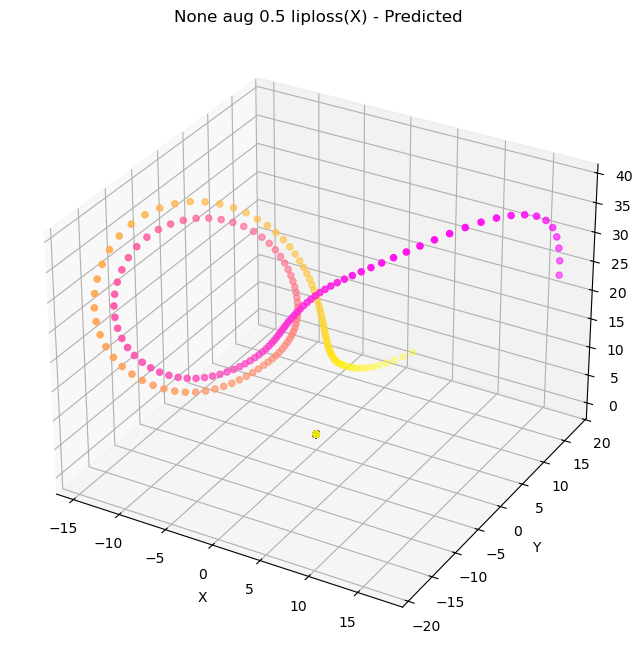

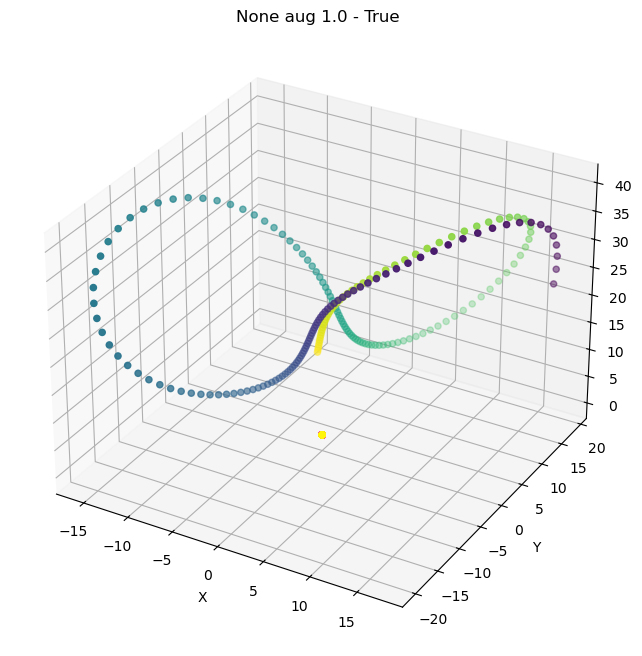

In [316]:
#k=160 # take wrong turn 
k=45
time = 201
zeros  = np.zeros((3, time))
plot_traj(data_05_lipsupX["y_true"][k][:,:time], data_05_lipsupX["y_pred"][k][:,:time], np.arange(0,time), "None aug 0.5 liploss(X)")
plot_traj(zeros, data_05_lipsupX["y_pred"][k][:,:time], np.arange(0,time), "None aug 0.5 liploss(X) - Predicted")
plot_traj(data_05_lipsupX["y_true"][k][:,:time], zeros, np.arange(0,time), "None aug 1.0 - True")

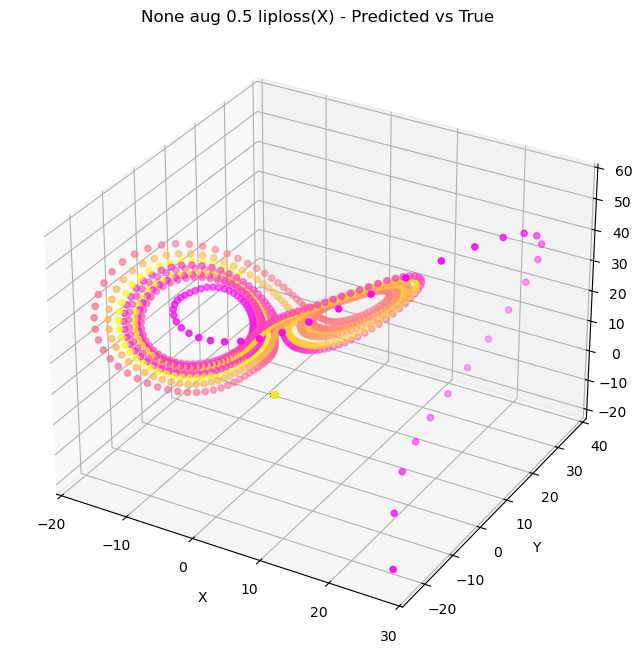

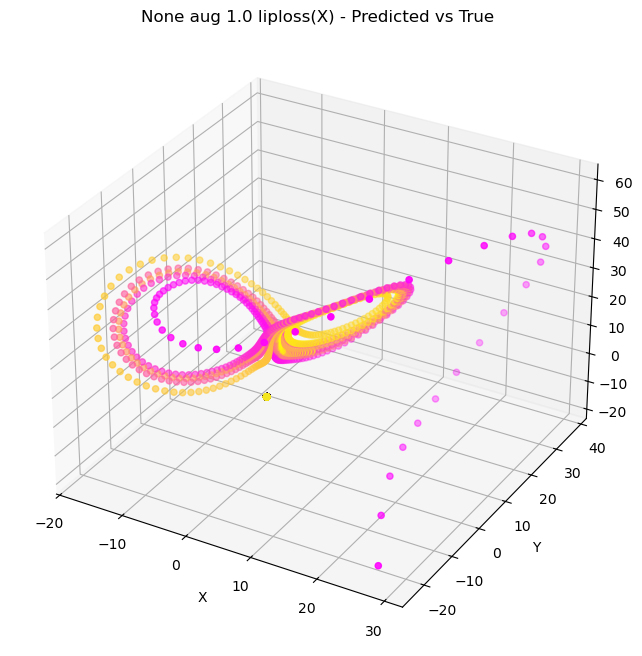

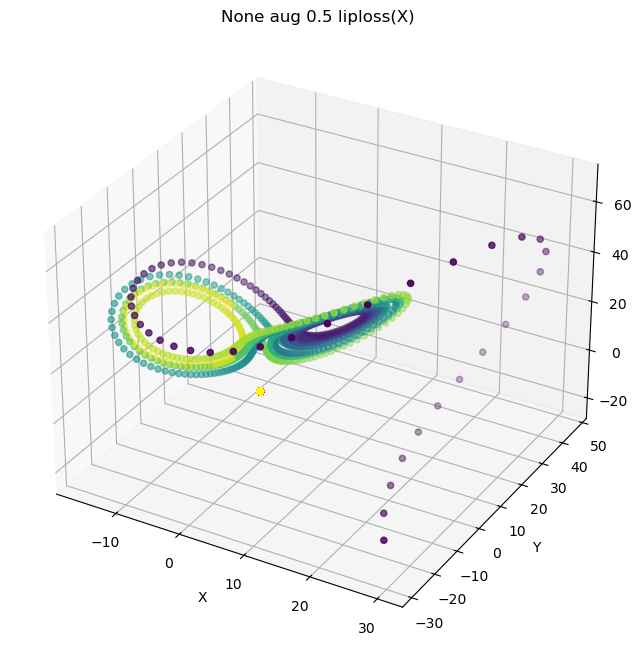

In [356]:
zeros = np.zeros((3, time))
plot_traj(zeros, data_05_lipsupX["y_pred"][k][:,:time], np.arange(0,time), "None aug 0.5 liploss(X) - Predicted vs True")
plot_traj(zeros, data_1_lipsupX["y_pred"][k][:,:time], np.arange(0,time), "None aug 1.0 liploss(X) - Predicted vs True")
plot_traj(data_05_lipsupX["y_true"][k][:,:time], zeros,np.arange(0,time), "None aug 0.5 liploss(X)")


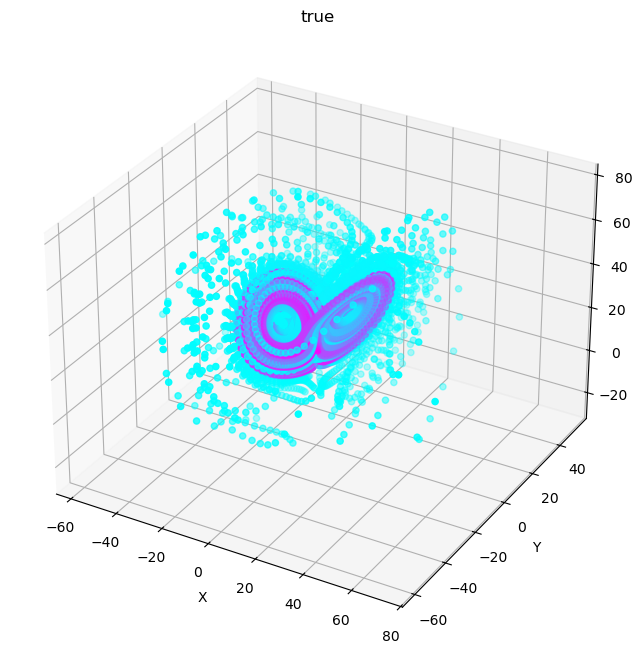

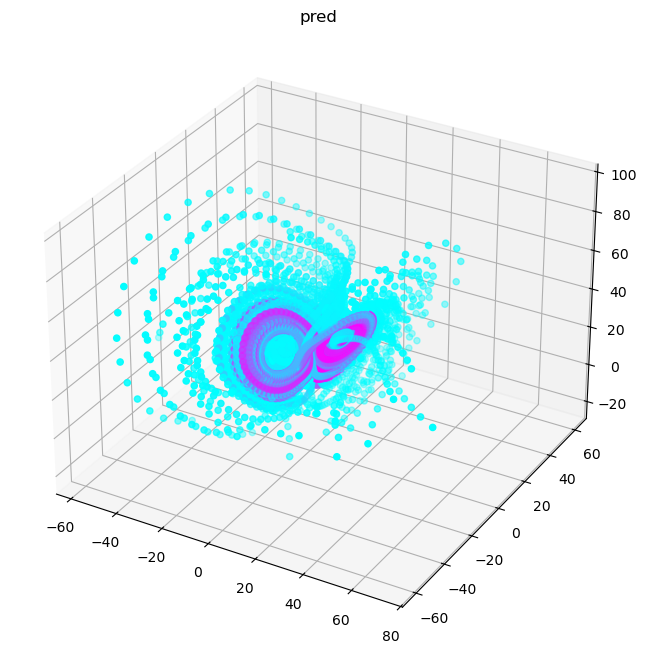

In [358]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
title="true"
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')
t = np.arange(0, 10+0.01, 0.01)
title2="pred"
for k in range(100):
    true = data_05_lipsupX["y_true"][k]
    pred = data_05_lipsupX["y_pred"][k]
    ax.scatter(true[0, :], true[1, :], true[2, :], c= t,  cmap='cool')
    ax2.scatter(pred[0, :], pred[1, :], pred[2, :], c= t, cmap="cool")
ax.set_title(title)
ax2.set_title(title2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
    

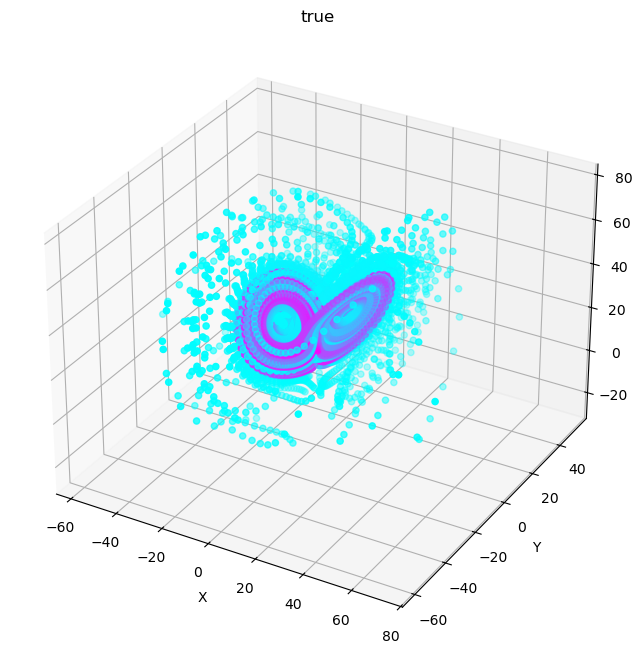

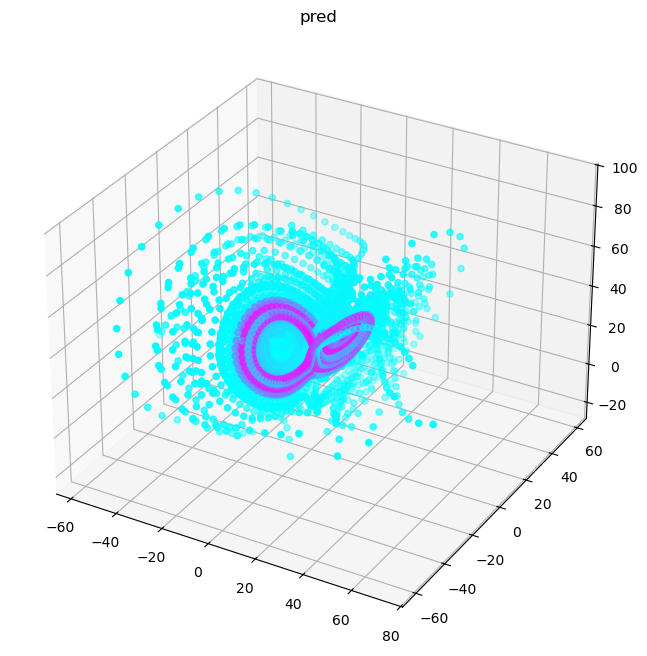

In [359]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
title="true"
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')
t = np.arange(0, 10+0.01, 0.01)
title2="pred"
for k in range(100):
    true = data_1_lipsupX["y_true"][k]
    pred = data_1_lipsupX["y_pred"][k]
    ax.scatter(true[0, :], true[1, :], true[2, :], c= t,  cmap='cool')
    ax2.scatter(pred[0, :], pred[1, :], pred[2, :], c= t, cmap="cool")
ax.set_title(title)
ax2.set_title(title2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
    

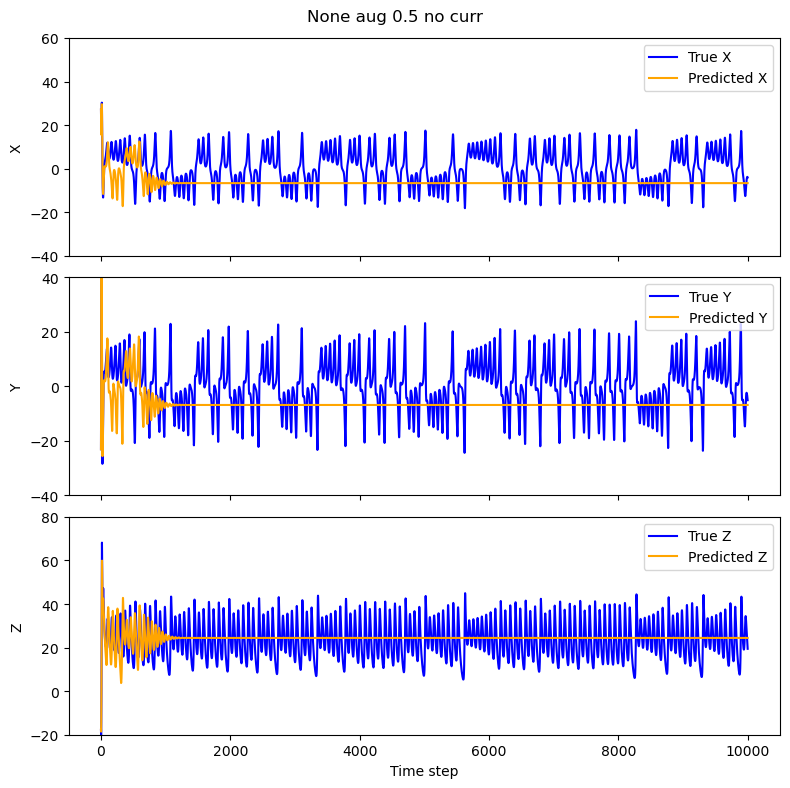

NameError: name 'data_05_lipsupX' is not defined

In [13]:
#k=35
k=160
time=10001
plot_xyz(data_none_aug05_nocurr["y_true"][k][:,:time], data_none_aug05_nocurr["y_pred"][k][:,:time], "None aug 0.5 no curr")
plot_xyz(data_05_lipsupX["y_true"][k][:,:time], data_05_lipsupX["y_pred"][k][:,:time], "0.5 liplossX")
plot_xyz(data_05_lipsupX_l10_tau10["y_true"][k][:,:time], data_05_lipsupX_l10_tau10["y_pred"][k][:,:time], "0.5 liplossX l10 tau10")
plot_xyz(data_none_aug05["y_true"][k][:,:time], data_none_aug05["y_pred"][k][:,:time], "None aug 0.5")
plot_xyz(data_05_aph_l10_tau10["y_true"][k][:,:time], data_05_aph_l10_tau10["y_pred"][k][:,:time], "0.5 aph l10 tau10")
plot_xyz(data_none_aug1["y_true"][k][:,:time], data_none_aug1["y_pred"][k][:,:time], "None aug 1")
plot_xyz(data_1_lipsupX["y_true"][k][:,:time], data_1_lipsupX["y_pred"][k][:,:time], "1 liplossX")


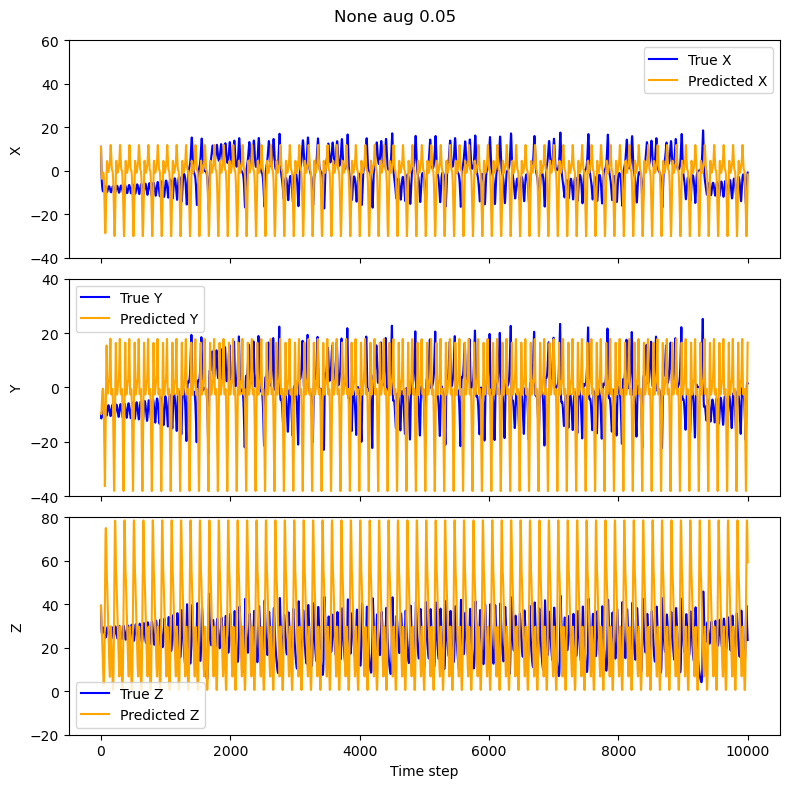

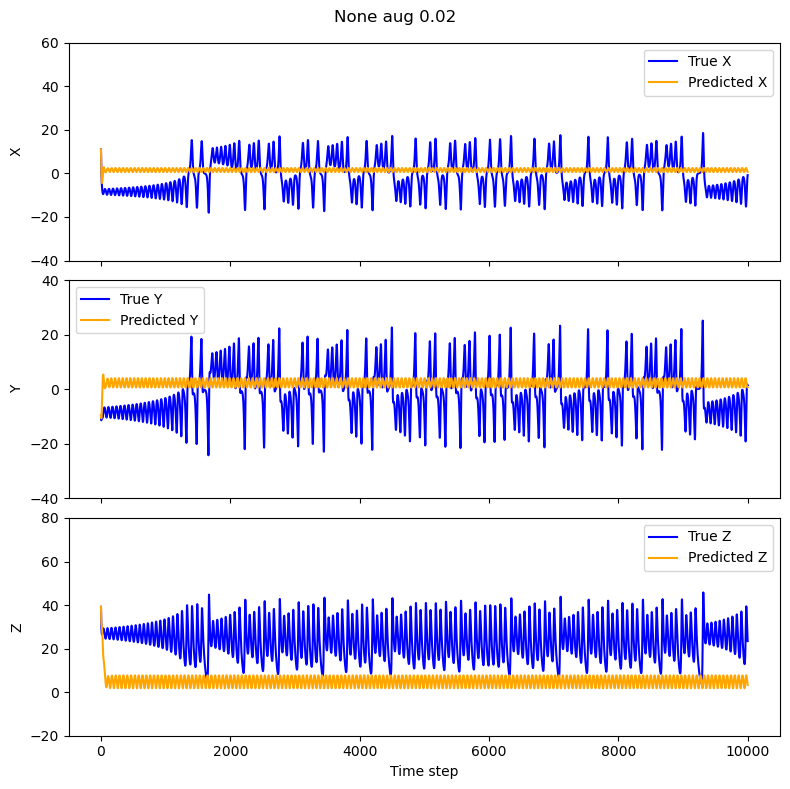

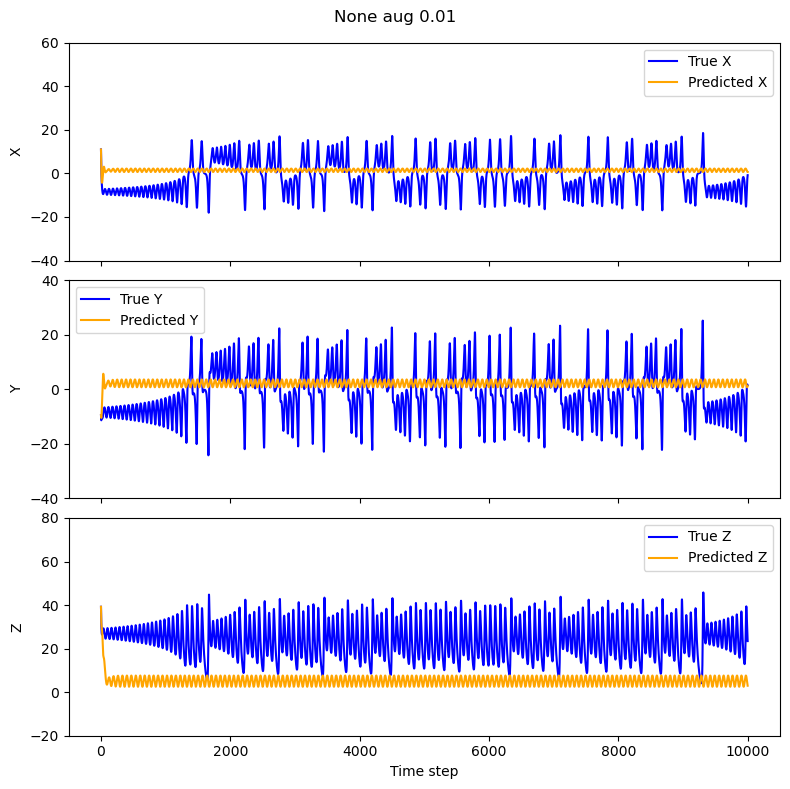

In [49]:
k=65
plot_xyz(data_none_aug005["y_true"][k][:,:], data_none_aug005["y_pred"][k][:,:], "None aug 0.05")
plot_xyz(data_none_aug002["y_true"][k][:,:], data_none_aug002["y_pred"][k][:,:], "None aug 0.02")
plot_xyz(data_none_aug001["y_true"][k][:,:], data_none_aug001["y_pred"][k][:,:], "None aug 0.01")


In [1]:
plot_xyz(data_none_aug05_nocurr["y_true"][k][:,:], data_none_aug05_nocurr["y_pred"][k][:,:], "None aug 0.5 no curr")


NameError: name 'plot_xyz' is not defined

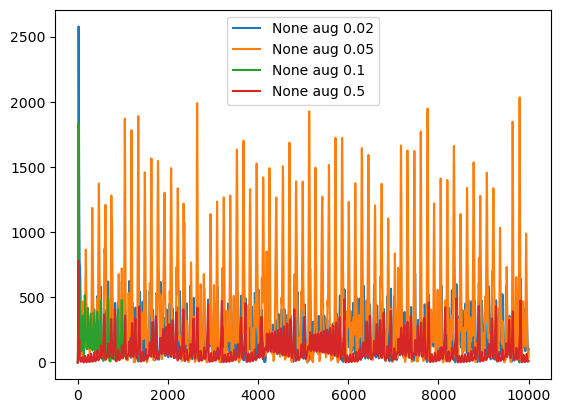

In [38]:
k = 78
time = int(0.05/0.01)
#plot_xyz(data_none_aug01["y_true"][k][:,:time], data_none_aug01["y_pred"][k][:,:time], "None aug 0.1")
plt.plot(((data_none_aug002["y_true"][k][:,:]-data_none_aug002["y_pred"][k][:,:])**2).mean(axis=0), label="None aug 0.02")
plt.plot(((data_none_aug005["y_true"][k][:,:]-data_none_aug005["y_pred"][k][:,:])**2).mean(axis=0), label="None aug 0.05")
plt.plot(((data_none_aug01["y_true"][k][:,:]-data_none_aug01["y_pred"][k][:,:])**2).mean(axis=0), label="None aug 0.1")
plt.plot(((data_none_aug05["y_true"][k][:,:]-data_none_aug05["y_pred"][k][:,:])**2).mean(axis=0), label="None aug 0.5")
plt.legend()


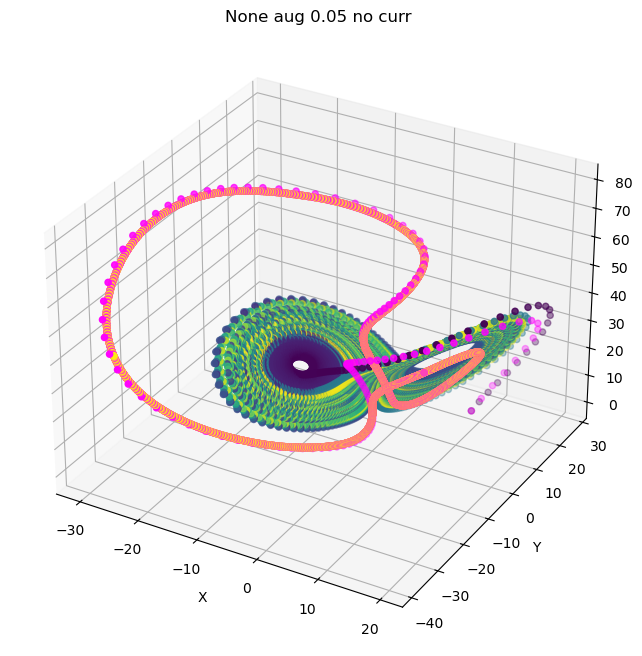

In [23]:
plot_traj(data_none_aug005["y_true"][k][:,:time], data_none_aug005["y_pred"][k][:,:time], np.arange(0,time), "None aug 0.05 no curr")

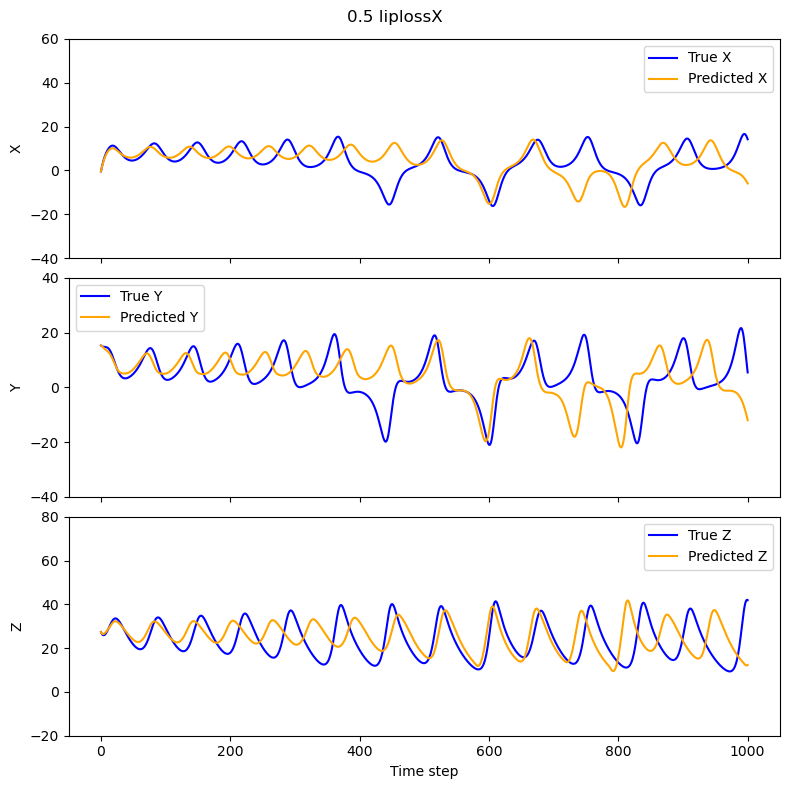

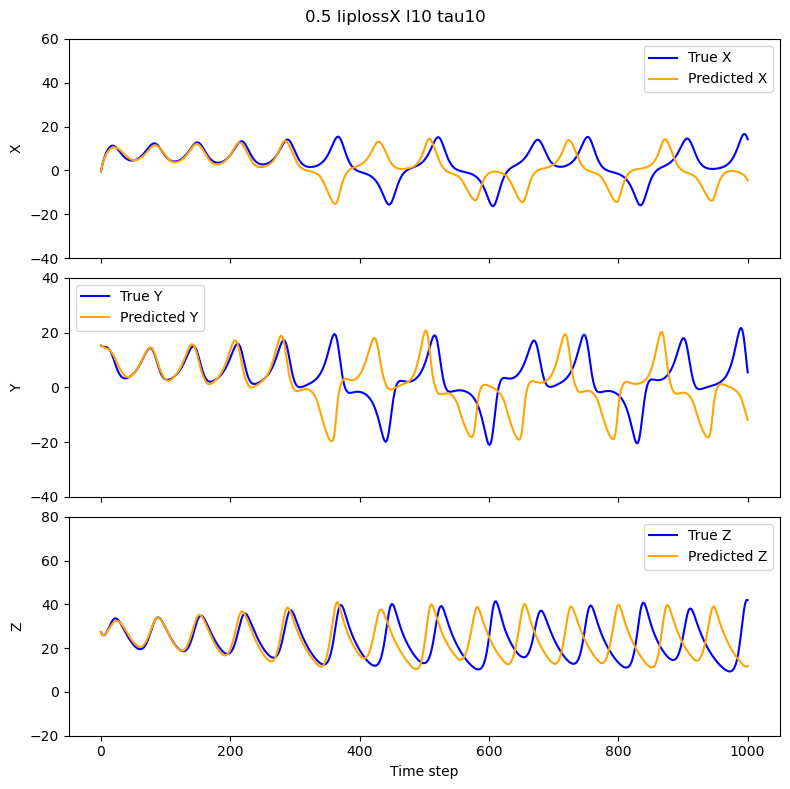

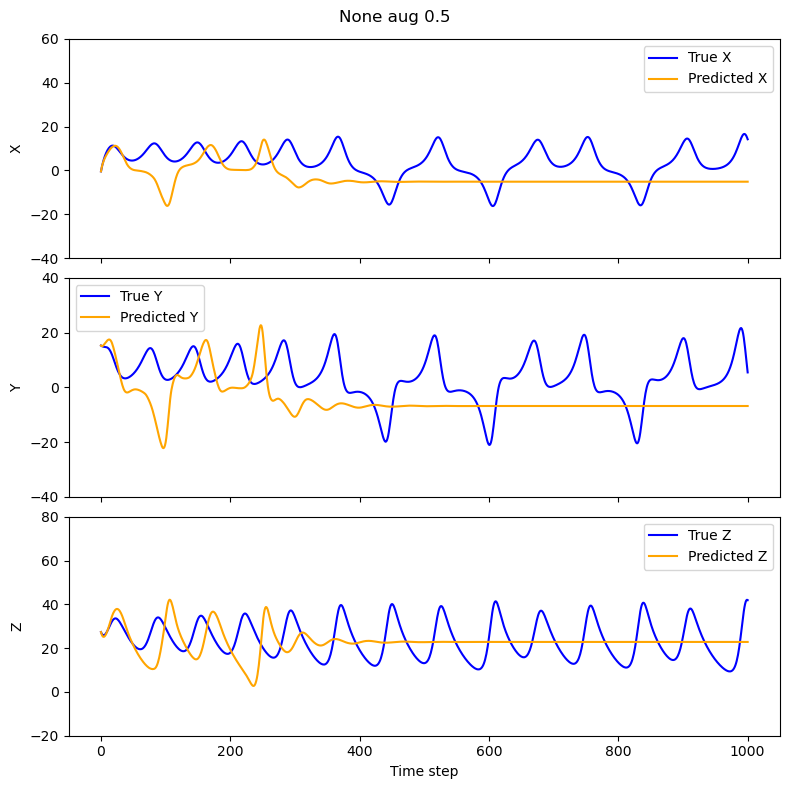

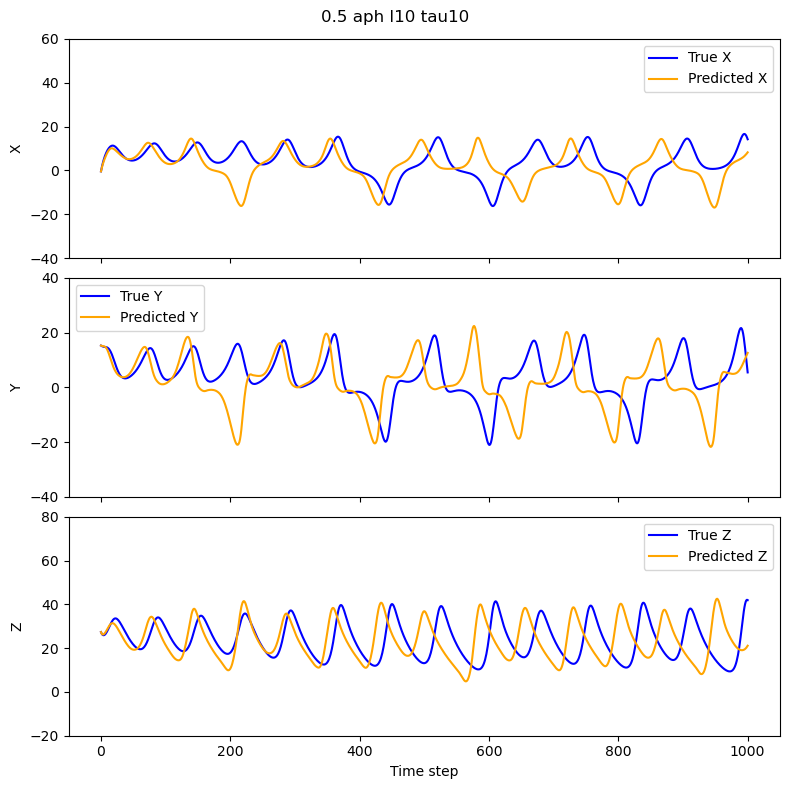

In [29]:
k=50
time=1001
#plot_xyz(data_none_aug01["y_true"][k][:,:time], data_none_aug01["y_pred"][k][:,:time], "None aug 0.1")
plot_xyz(data_05_lipsupX["y_true"][k][:,:time], data_05_lipsupX["y_pred"][k][:,:time], "0.5 liplossX")
plot_xyz(data_05_lipsupX_l10_tau10["y_true"][k][:,:time], data_05_lipsupX_l10_tau10["y_pred"][k][:,:time], "0.5 liplossX l10 tau10")
plot_xyz(data_none_aug05["y_true"][k][:,:time], data_none_aug05["y_pred"][k][:,:time], "None aug 0.5")
plot_xyz(data_05_aph_l10_tau10["y_true"][k][:,:time], data_05_aph_l10_tau10["y_pred"][k][:,:time], "0.5 aph l10 tau10")

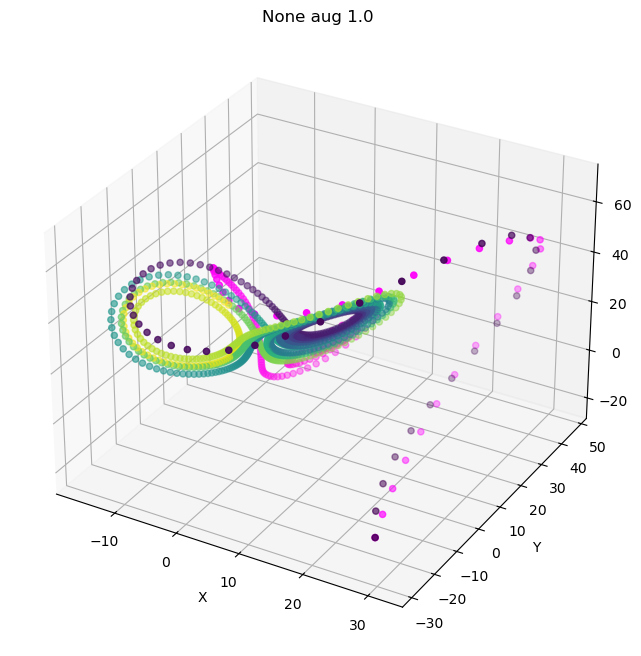

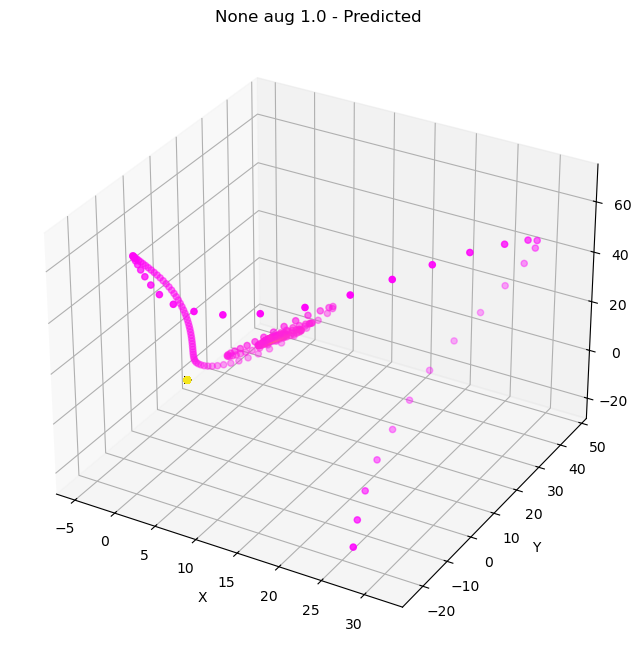

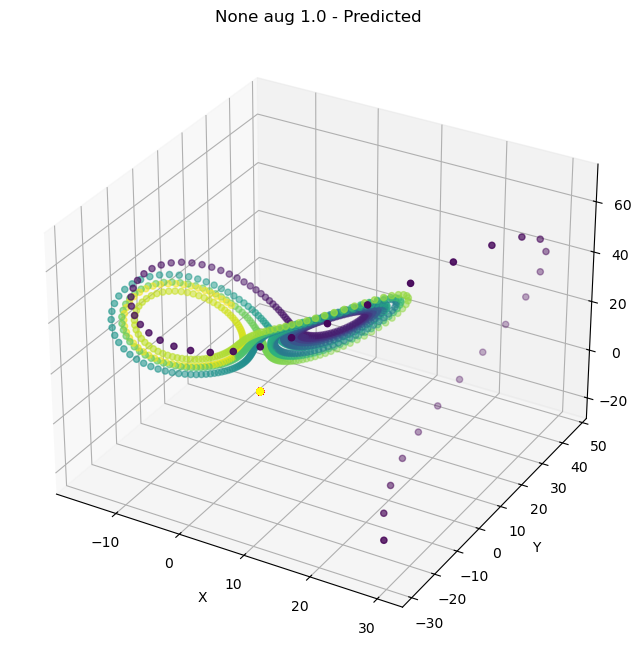

In [286]:
k=160
zeros  = np.zeros((3, 1001))
plot_traj(data_none_aug01["y_true"][k][:,:], data_none_aug01["y_pred"][k][:,:], np.arange(0,1001), "None aug 1.0")
plot_traj(zeros, data_none_aug01["y_pred"][k][:,:], np.arange(0,1001), "None aug 1.0 - Predicted")
plot_traj(data_none_aug05["y_true"][k][:,:], zeros, np.arange(0,1001), "None aug 1.0 - Predicted")

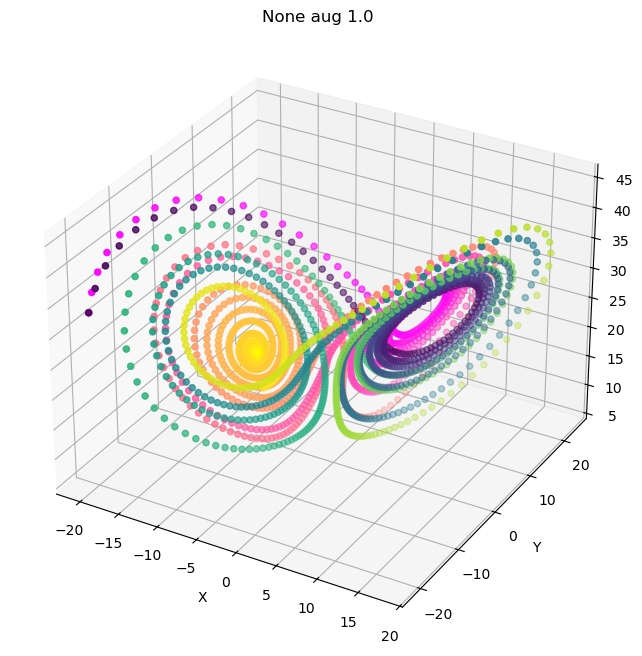

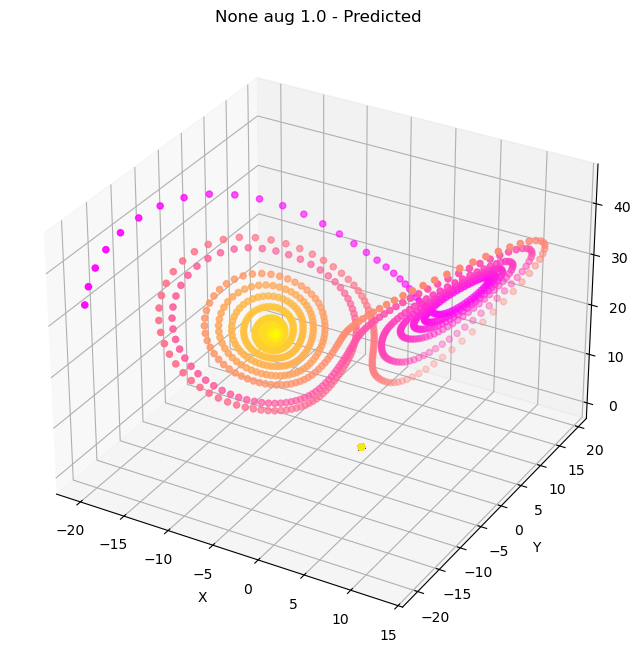

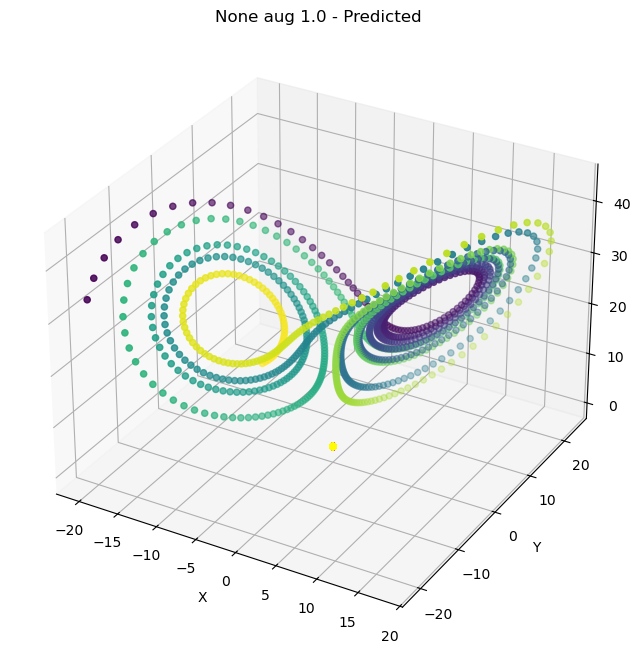

In [271]:
k=43
zeros  = np.zeros((3, 1001))
plot_traj(data_none_aug05_nocurr["y_true"][k][:,:], data_none_aug05_nocurr["y_pred"][k][:,:], np.arange(0,1001), "None aug 1.0")
plot_traj(zeros, data_none_aug05_nocurr["y_pred"][k][:,:], np.arange(0,1001), "None aug 1.0 - Predicted")
plot_traj(data_none_aug05["y_true"][k][:,:], zeros, np.arange(0,1001), "None aug 1.0 - Predicted")

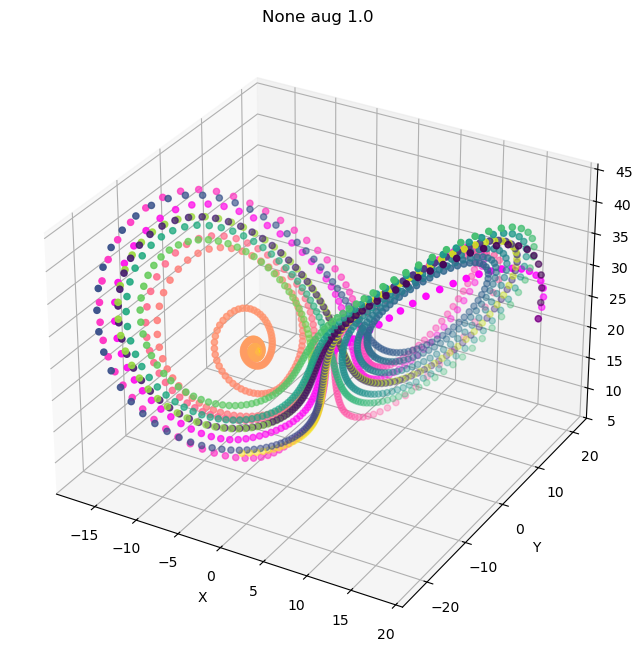

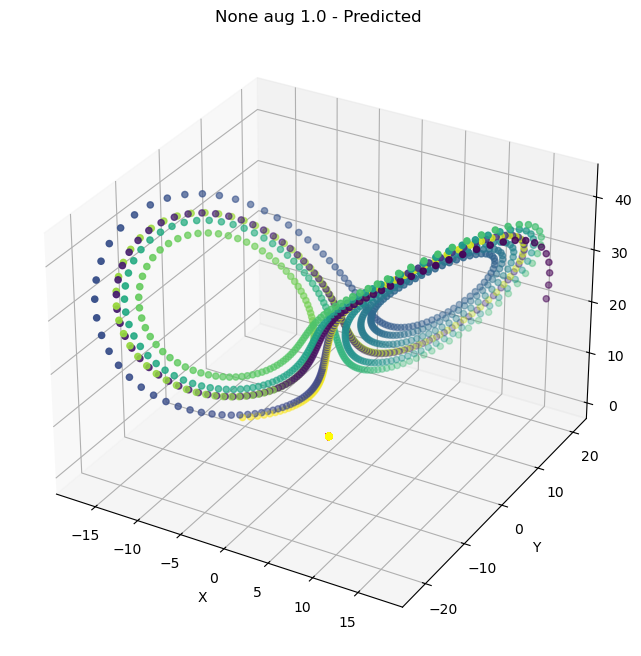

In [272]:
k=45
zeros  = np.zeros((3, 1001))
plot_traj(data_none_aug05["y_true"][k][:,:], data_none_aug05["y_pred"][k][:,:], np.arange(0,1001), "None aug 1.0")
#plot_traj(zeros, data_none_aug05["y_pred"][k][:,:], np.arange(0,1001), "None aug 1.0 - Predicted")
plot_traj(data_none_aug05["y_true"][k][:,:], zeros, np.arange(0,1001), "None aug 1.0 - Predicted")

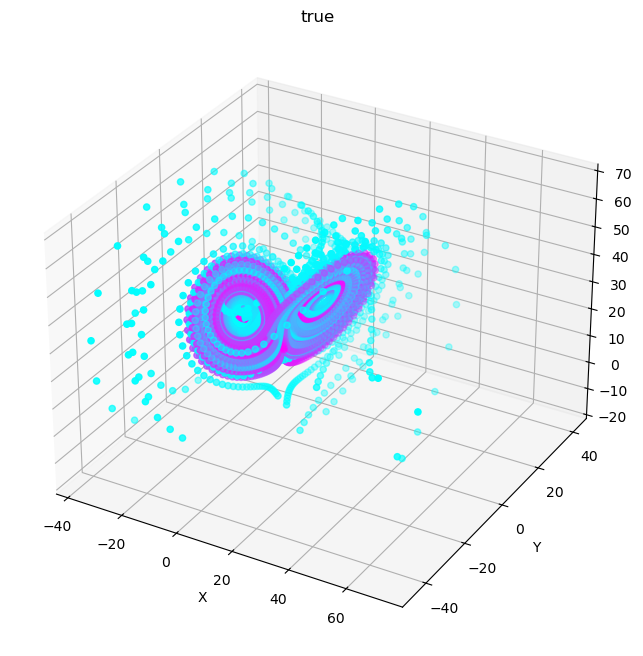

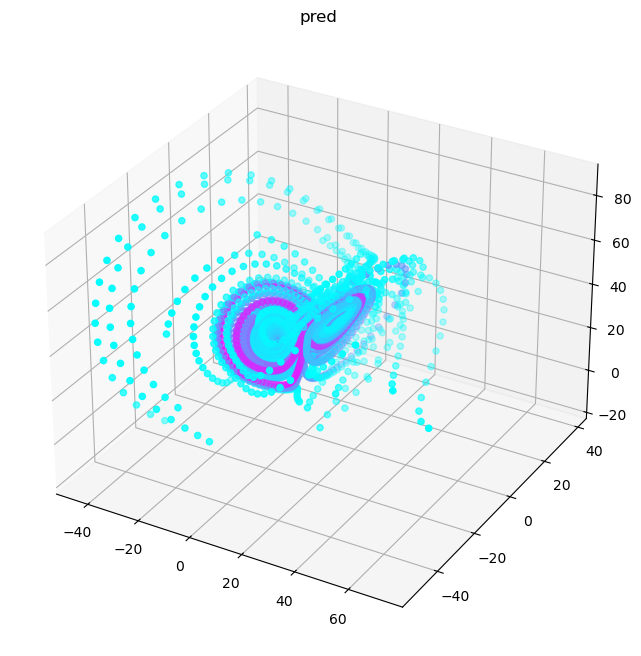

In [287]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
title="true"
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')
t = np.arange(0, 10+0.01, 0.01)
title2="pred"
for k in range(25):
    true = data_none_aug05_nocurr["y_true"][k]
    pred = data_none_aug05_nocurr["y_pred"][k]
    ax.scatter(true[0, :], true[1, :], true[2, :], c= t,  cmap='cool')
    ax2.scatter(pred[0, :], pred[1, :], pred[2, :], c= t, cmap="cool")
ax.set_title(title)
ax2.set_title(title2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
    

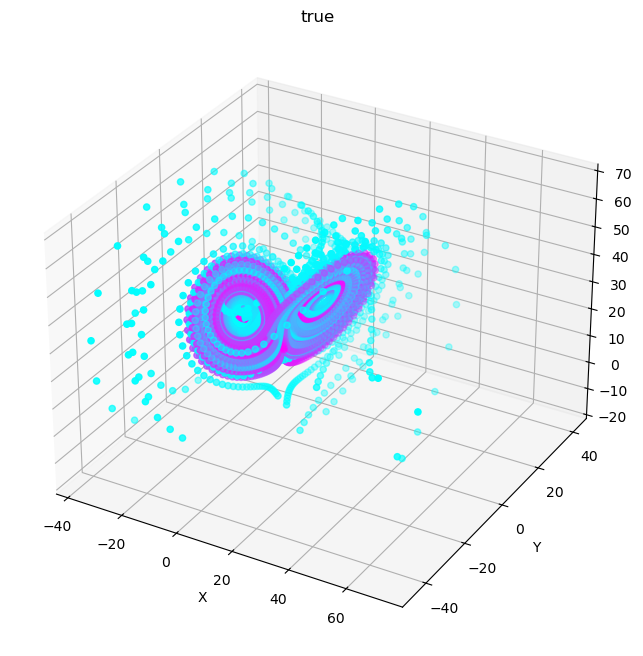

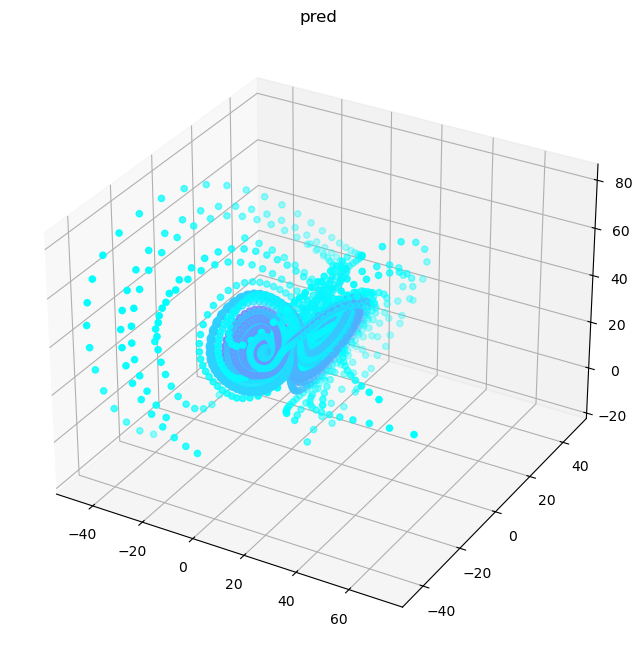

In [246]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
title="true"
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')
t = np.arange(0, 10+0.01, 0.01)
title2="pred"
for k in range(25):
    true = data_none_aug05["y_true"][k]
    pred = data_none_aug05["y_pred"][k]
    ax.scatter(true[0, :], true[1, :], true[2, :], c= t,  cmap='cool')
    ax2.scatter(pred[0, :], pred[1, :], pred[2, :], c= t, cmap="cool")
ax.set_title(title)
ax2.set_title(title2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
    

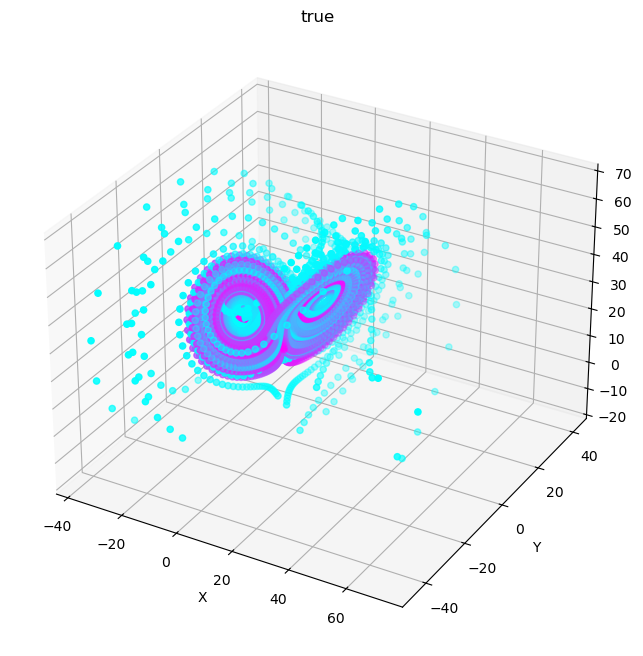

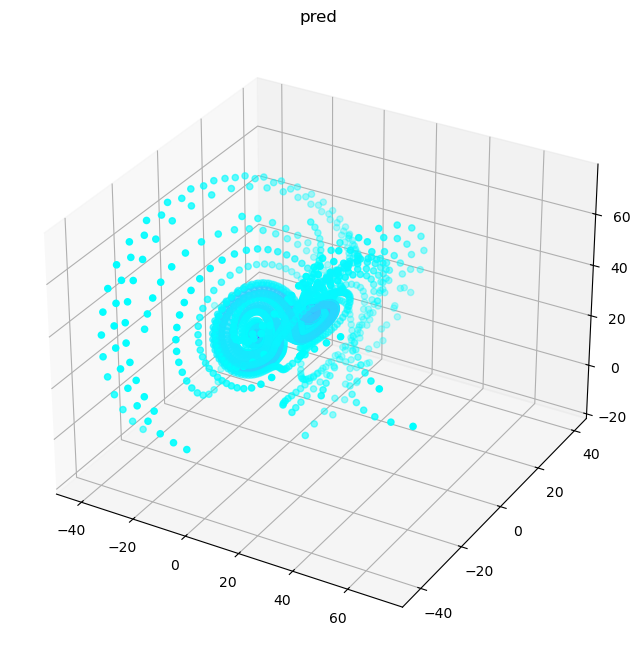

In [241]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
title="true"
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')
t = np.arange(0, 10+0.01, 0.01)
title2="pred"
for k in range(25):
    true = data_none_aug1["y_true"][k]
    pred = data_none_aug1["y_pred"][k]
    ax.scatter(true[0, :], true[1, :], true[2, :], c= t,  cmap='cool')
    ax2.scatter(pred[0, :], pred[1, :], pred[2, :], c= t, cmap="cool")
ax.set_title(title)
ax2.set_title(title2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
    

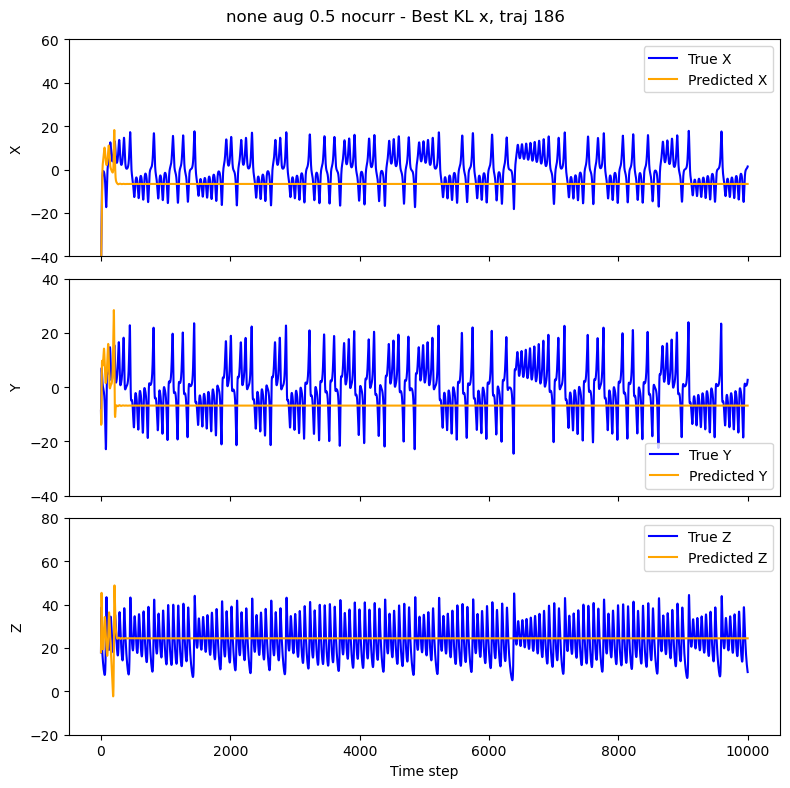

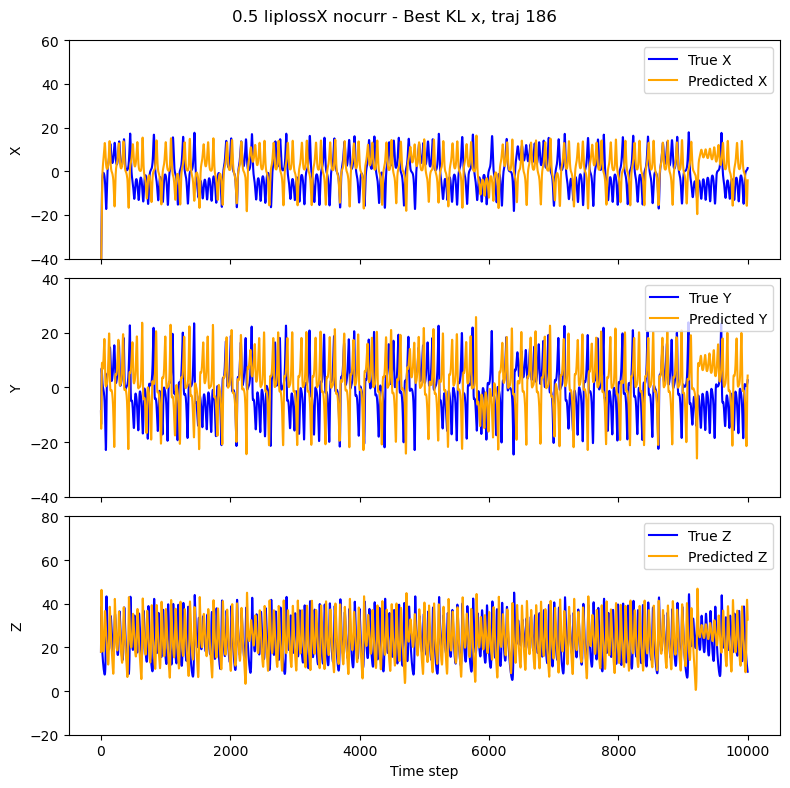

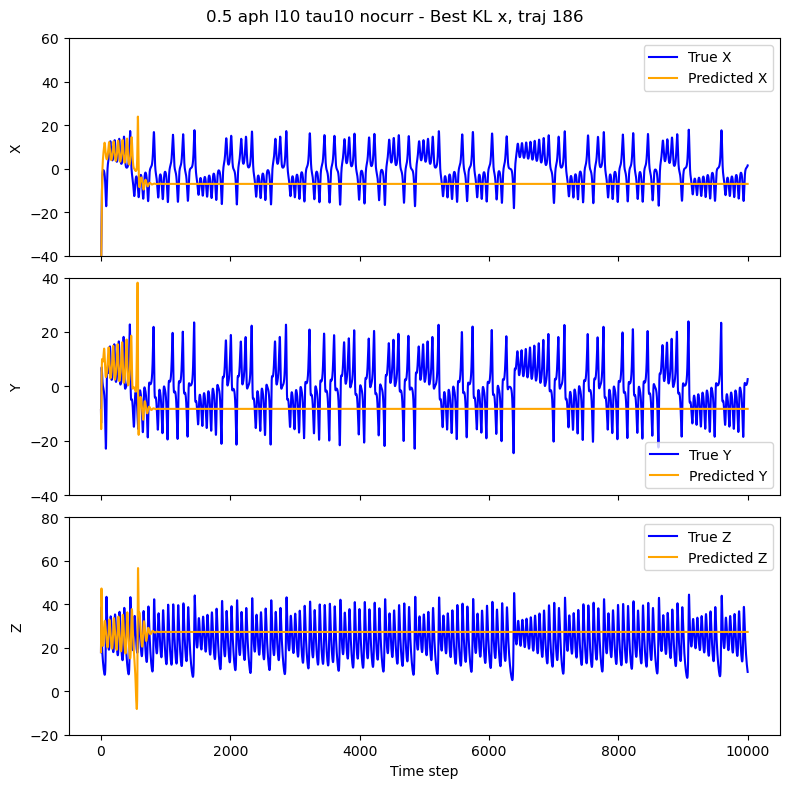

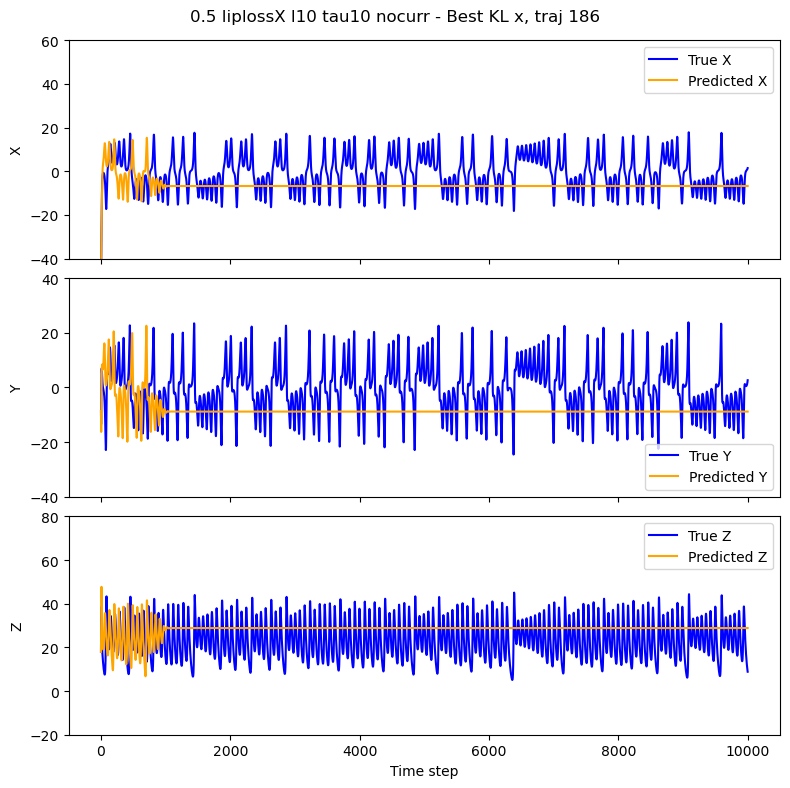

In [75]:
# no curr what's happening
# k = data_none_aug05_nocurr["KL_x"].idxmin()
k= data_05_lipsupX_nocurr["KL_x"].idxmin()
plot_xyz(data_none_aug05_nocurr["y_true"][k], data_none_aug05_nocurr["y_pred"][k], title=f"none aug 0.5 nocurr - Best KL x, traj {k}")
# plot_xyz(data_none_aug05["y_true"][k], data_none_aug05["y_pred"][k], title=f"none aug 0.5 curr - Best KL x - traj {k}")
plot_xyz(data_05_lipsupX_nocurr["y_true"][k], data_05_lipsupX_nocurr["y_pred"][k], title=f"0.5 liplossX nocurr - Best KL x, traj {k}")
plot_xyz(data_05_aph_l10_tau10_nocurr["y_true"][k], data_05_aph_l10_tau10_nocurr["y_pred"][k], title=f"0.5 aph l10 tau10 nocurr - Best KL x, traj {k}")
plot_xyz(data_05_lipsupX_l10_tau10_nocurr["y_true"][k], data_05_lipsupX_l10_tau10_nocurr["y_pred"][k], title=f"0.5 liplossX l10 tau10 nocurr - Best KL x, traj {k}")

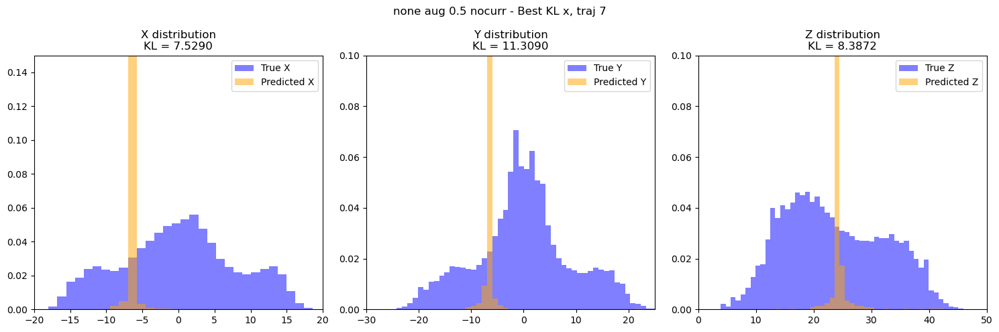

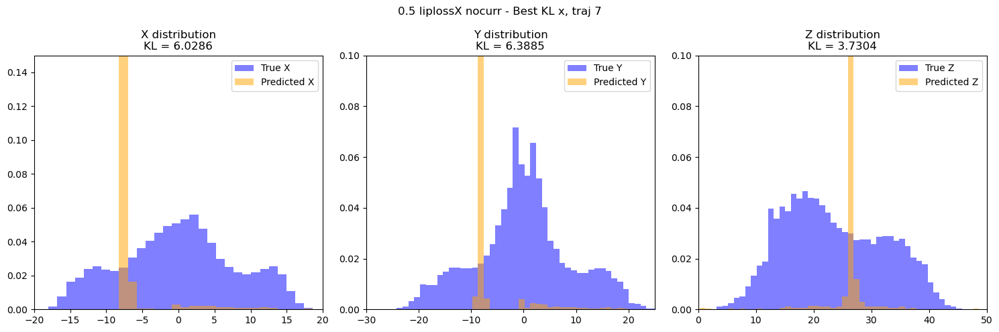

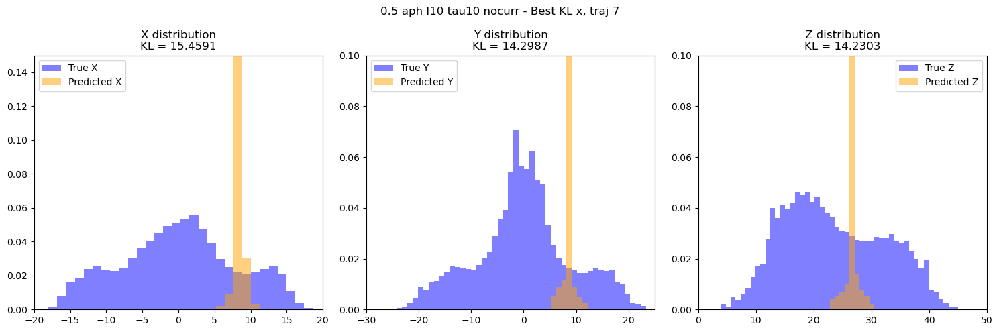

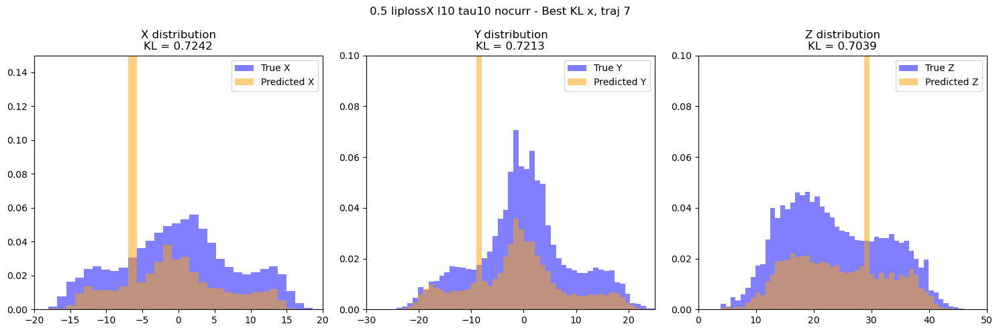

[0.7241977324350013, 0.7213157101737071, 0.703928300964294]

In [77]:
k = data_05_lipsupX_l10_tau10_nocurr["KL_x"].idxmin()
plot_pdf_with_kl(data_none_aug05_nocurr["y_true"][k], data_none_aug05_nocurr["y_pred"][k], title=f"none aug 0.5 nocurr - Best KL x, traj {k}")
plot_pdf_with_kl(data_05_lipsupX_nocurr["y_true"][k], data_05_lipsupX_nocurr["y_pred"][k], title=f"0.5 liplossX nocurr - Best KL x, traj {k}")
plot_pdf_with_kl(data_05_aph_l10_tau10_nocurr["y_true"][k], data_05_aph_l10_tau10_nocurr["y_pred"][k], title=f"0.5 aph l10 tau10 nocurr - Best KL x, traj {k}")
plot_pdf_with_kl(data_05_lipsupX_l10_tau10_nocurr["y_true"][k], data_05_lipsupX_l10_tau10_nocurr["y_pred"][k], title=f"0.5 liplossX l10 tau10 nocurr - Best KL x, traj {k}")

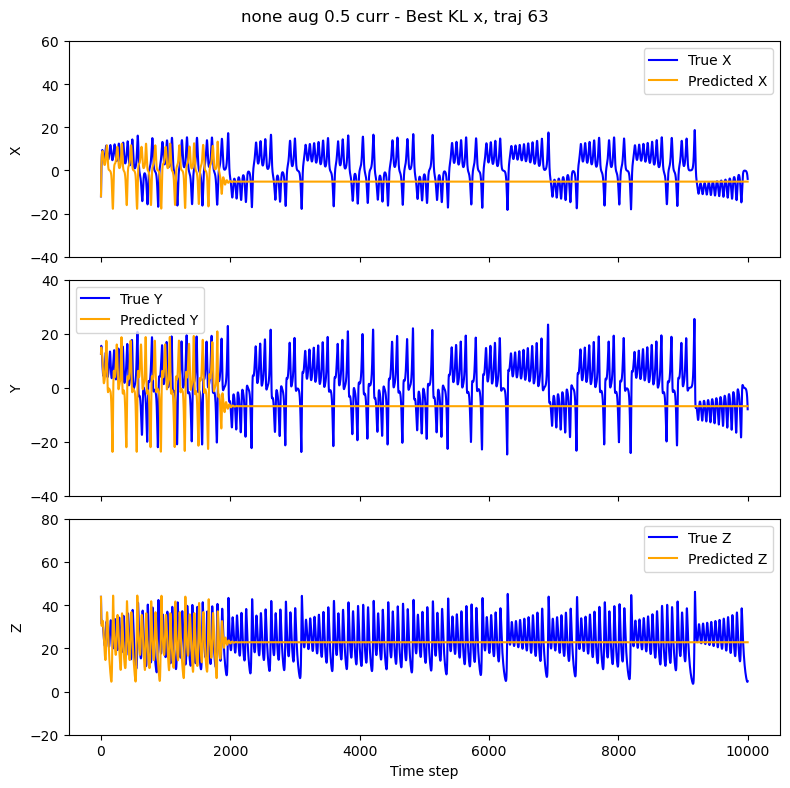

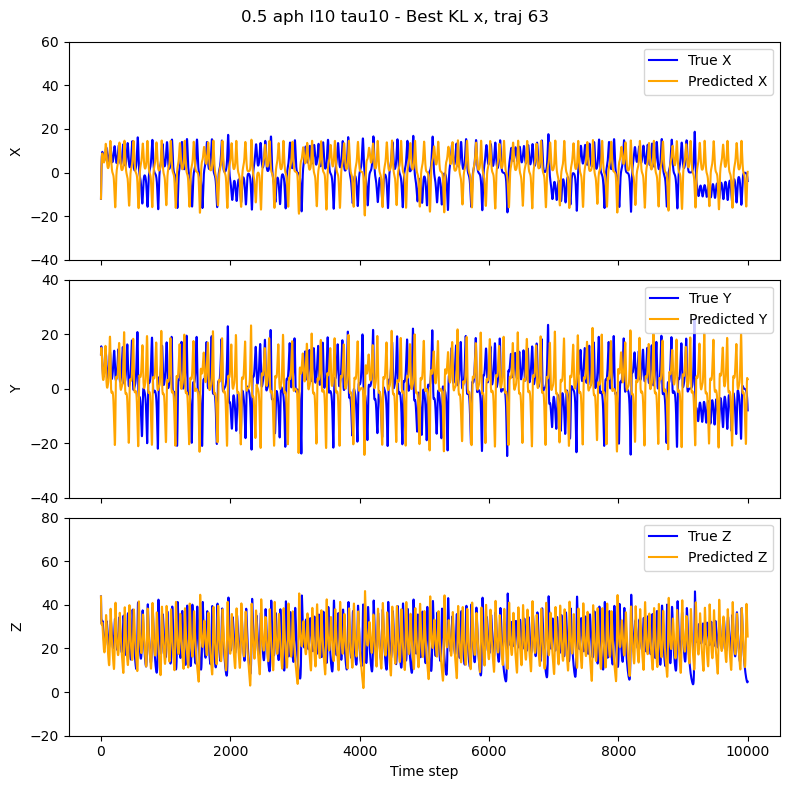

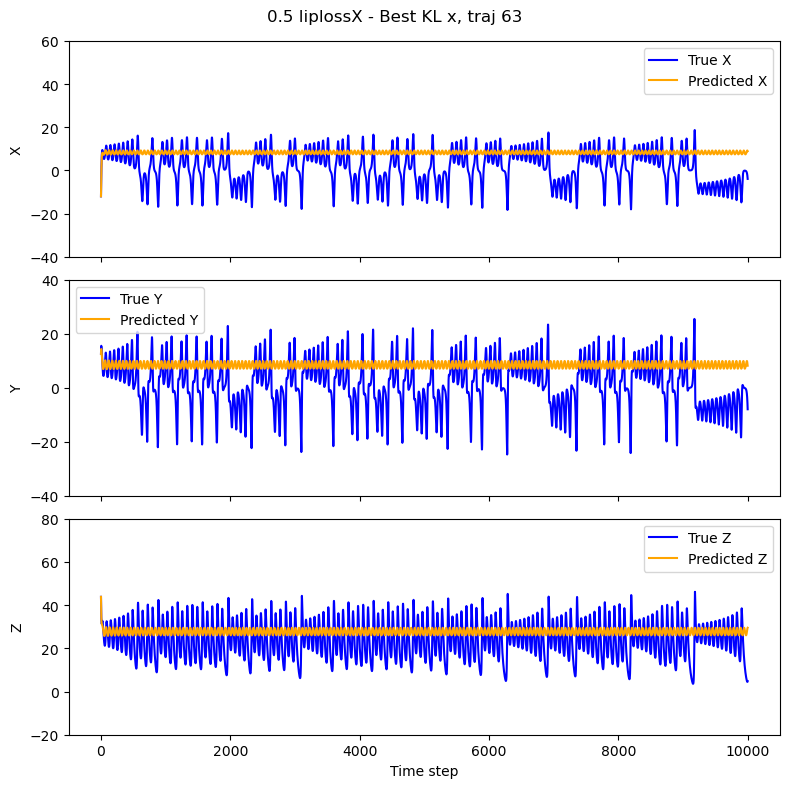

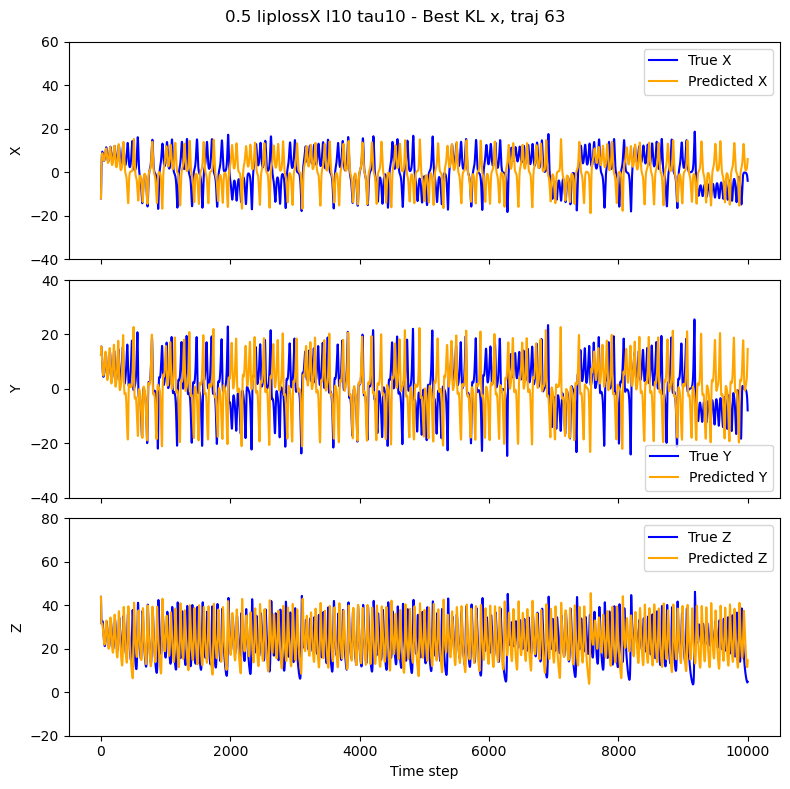

In [64]:
# curr what's happening
k = data_none_aug05["KL_x"].idxmin()
plot_xyz(data_none_aug05["y_true"][k], data_none_aug05["y_pred"][k], title=f"none aug 0.5 curr - Best KL x, traj {k}")
plot_xyz(data_05_aph_l10_tau10["y_true"][k], data_05_aph_l10_tau10["y_pred"][k], title=f"0.5 aph l10 tau10 - Best KL x, traj {k}")
plot_xyz(data_05_lipsupX["y_true"][k], data_05_lipsupX["y_pred"][k], title=f"0.5 liplossX - Best KL x, traj {k}")
plot_xyz(data_05_lipsupX_l10_tau10["y_true"][k], data_05_lipsupX_l10_tau10["y_pred"][k], title=f"0.5 liplossX l10 tau10 - Best KL x, traj {k}")

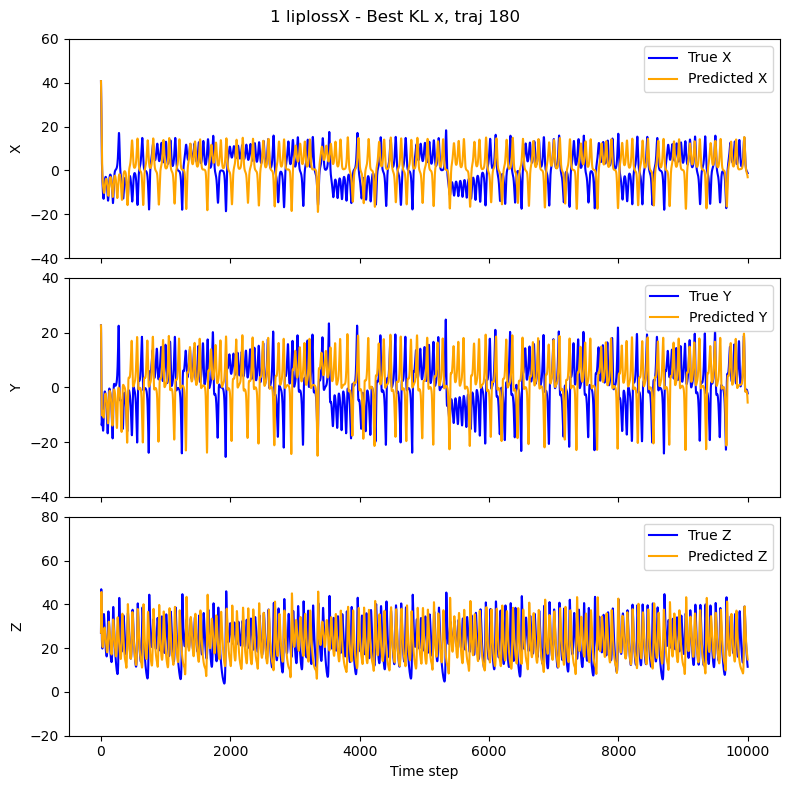

In [125]:
k=data_1_lipsupX["KL_x"].idxmin()
#plot_xyz(data_none_aug1["y_true"][k], data_none_aug1["y_pred"][k], title=f"none aug 1.0 - Best KL x, traj {k}")
plot_xyz(data_1_lipsupX["y_true"][k], data_1_lipsupX["y_pred"][k], title=f"1 liplossX - Best KL x, traj {k}")
#plot_xyz(data_1_lipsupX_l10_tau10["y_true"][k], data_1_lipsupX_l10_tau10["y_pred"][k], title=f"1 liplossX l10 tau10 - Best KL x, traj {k}")

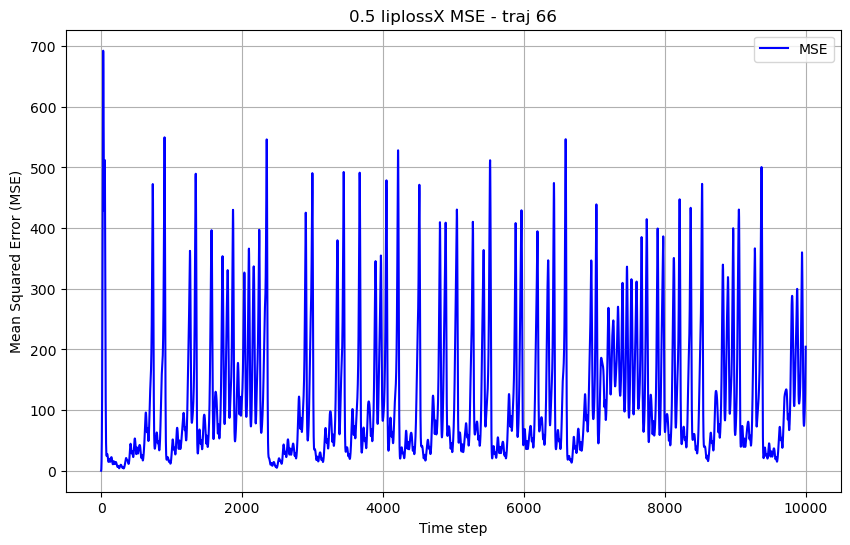

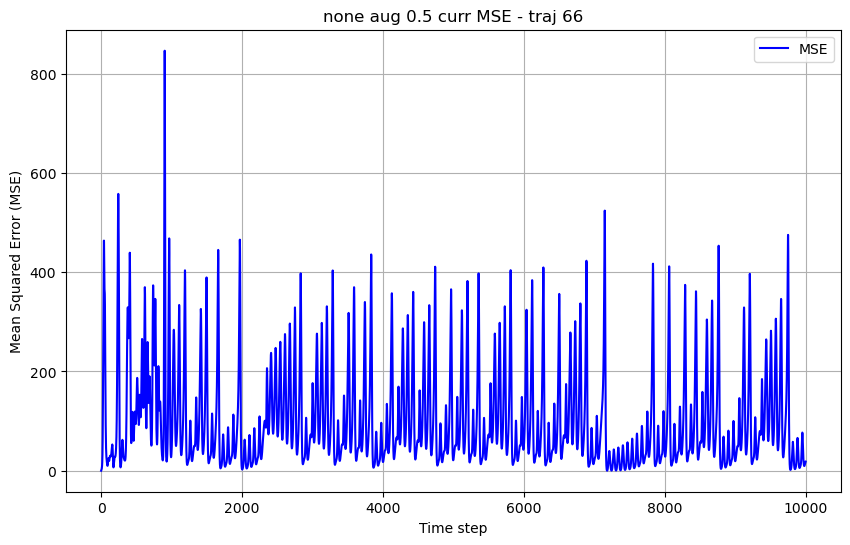

In [273]:
plot_mse_time(data_05_lipsupX["y_true"][k], data_05_lipsupX["y_pred"][k], title=f"0.5 liplossX MSE - traj {k}")
plot_mse_time(data_none_aug05["y_true"][k], data_none_aug05["y_pred"][k], title=f"none aug 0.5 curr MSE - traj {k}")

## Distributions (pdf)

In [28]:
lambda1 = 0.9050
tau_lambda = 1/lambda1
train_t = 1000*tau_lambda
test_t = 4000*tau_lambda
print(train_t, test_t)

1104.9723756906078 4419.889502762431


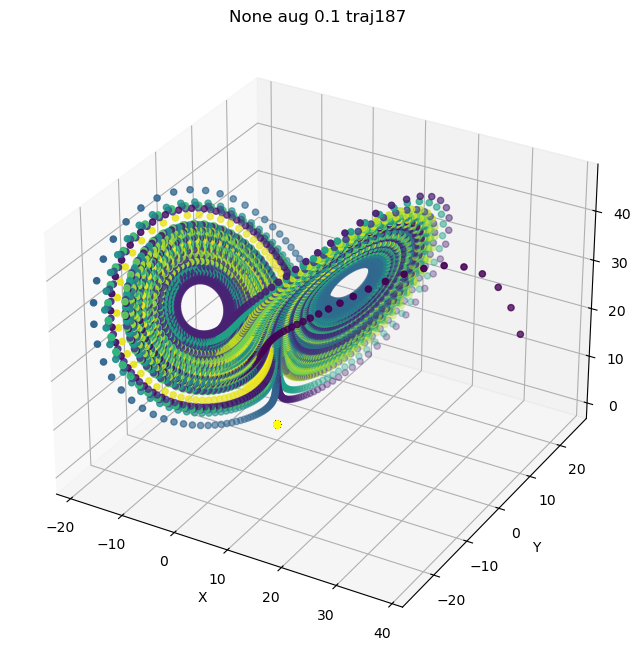

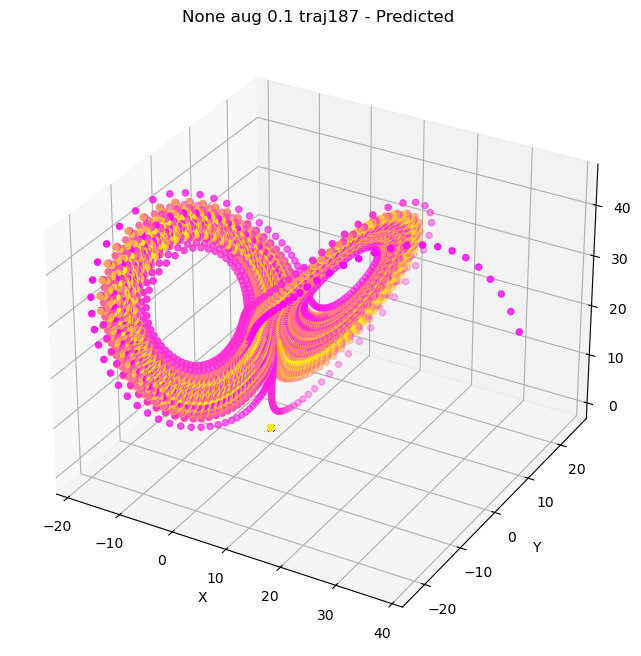

In [375]:
plot_traj(data_05_lipsupX_l10_tau10_100["y_true"][k], np.zeros(data_05_lipsupX_l10_tau10_100["y_true"][k].shape), np.arange(0,10001), f"None aug 0.1 traj{k}")
plot_traj(np.zeros(data_05_lipsupX_l10_tau10_100["y_true"][k].shape), data_05_lipsupX_l10_tau10_100["y_pred"][k], np.arange(0,10001), f"None aug 0.1 traj{k} - Predicted")


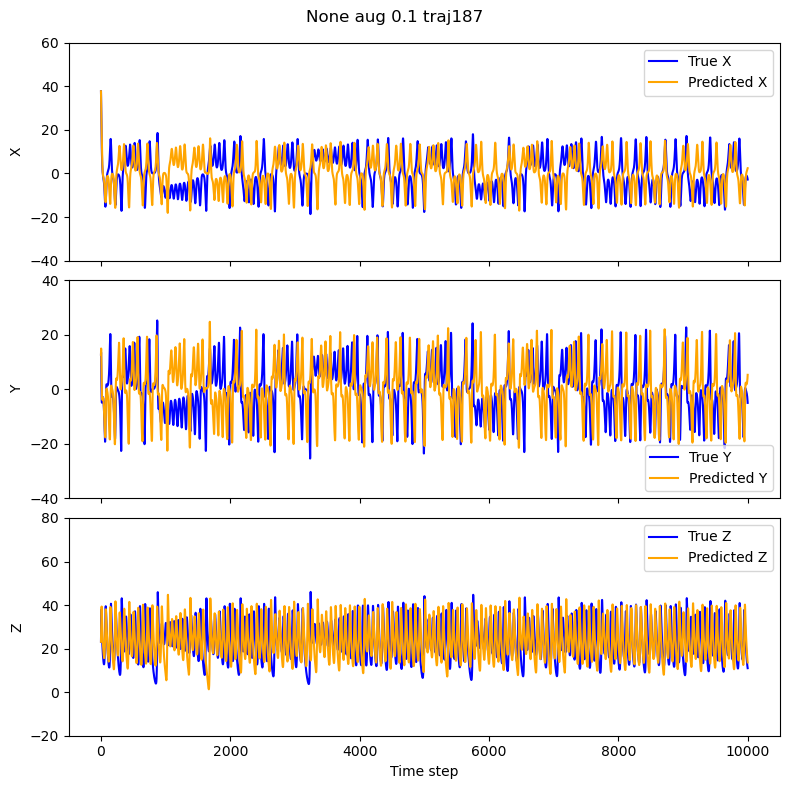

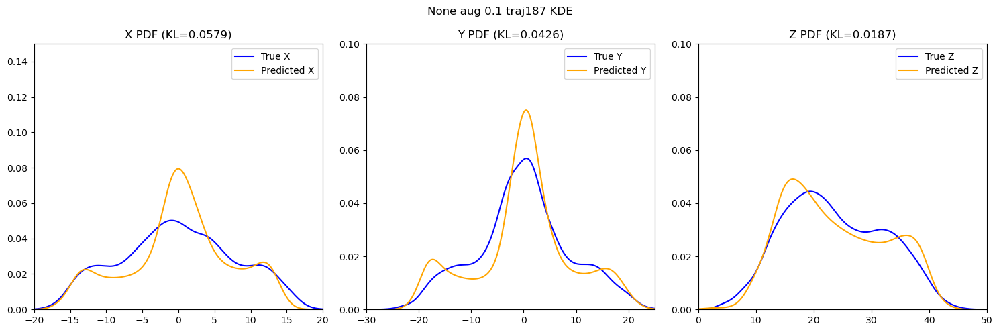

[0.0579264571109573, 0.04261987985121802, 0.018720247134544135]

In [374]:
plot_xyz(data_05_lipsupX_l10_tau10_100["y_true"][k], data_05_lipsupX_l10_tau10_100["y_pred"][k], f"None aug 0.1 traj{k}")
plot_kde_with_kl(data_05_lipsupX_l10_tau10_100["y_true"][k], data_05_lipsupX_l10_tau10_100["y_pred"][k], f"None aug 0.1 traj{k} KDE")

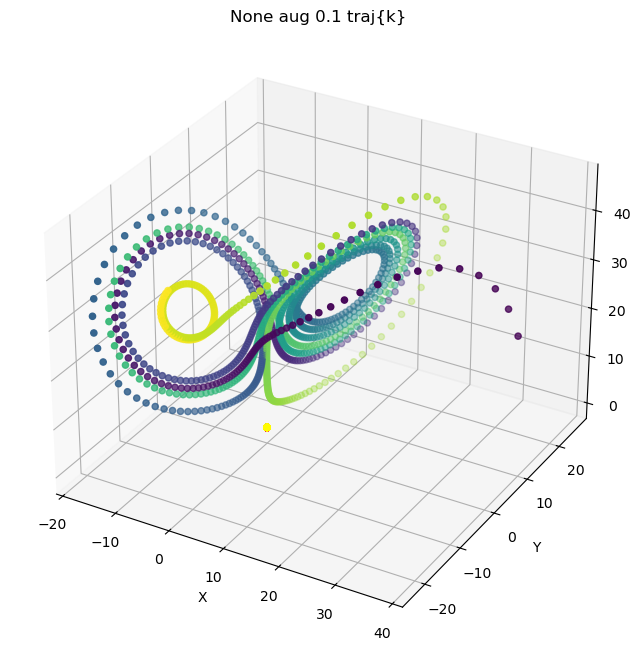

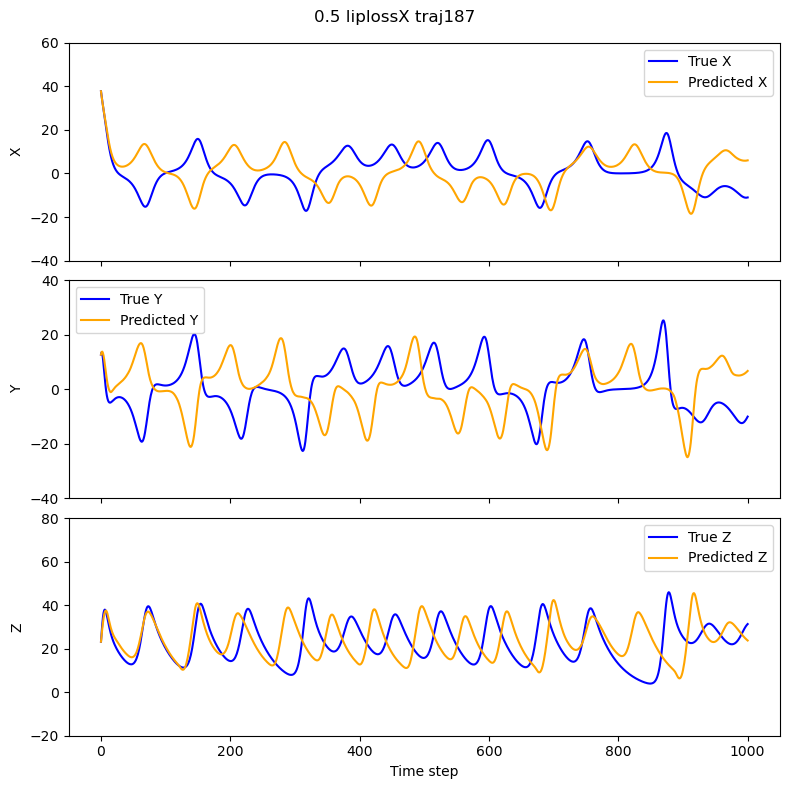

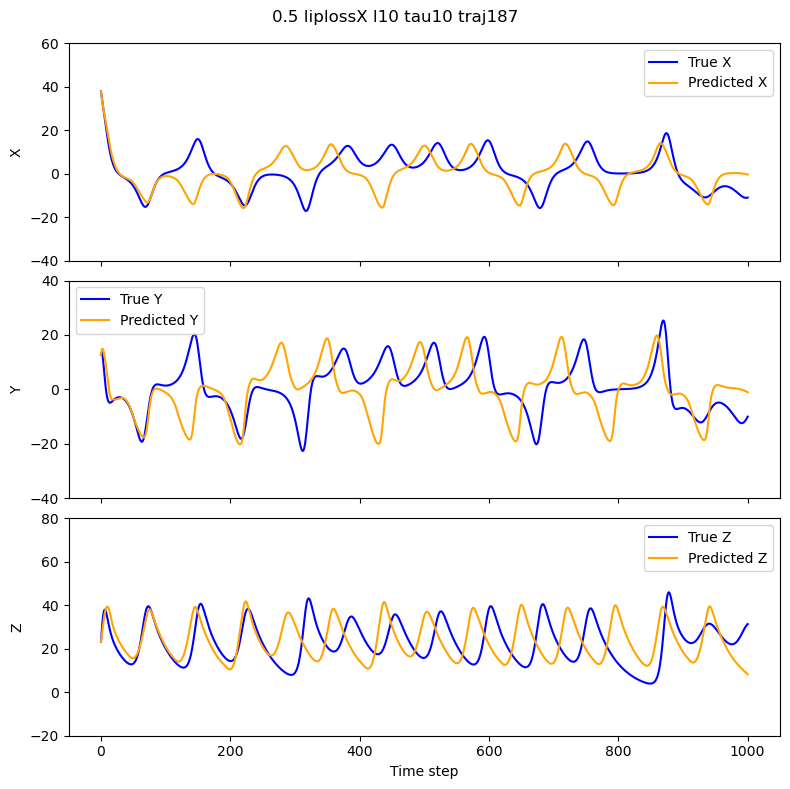

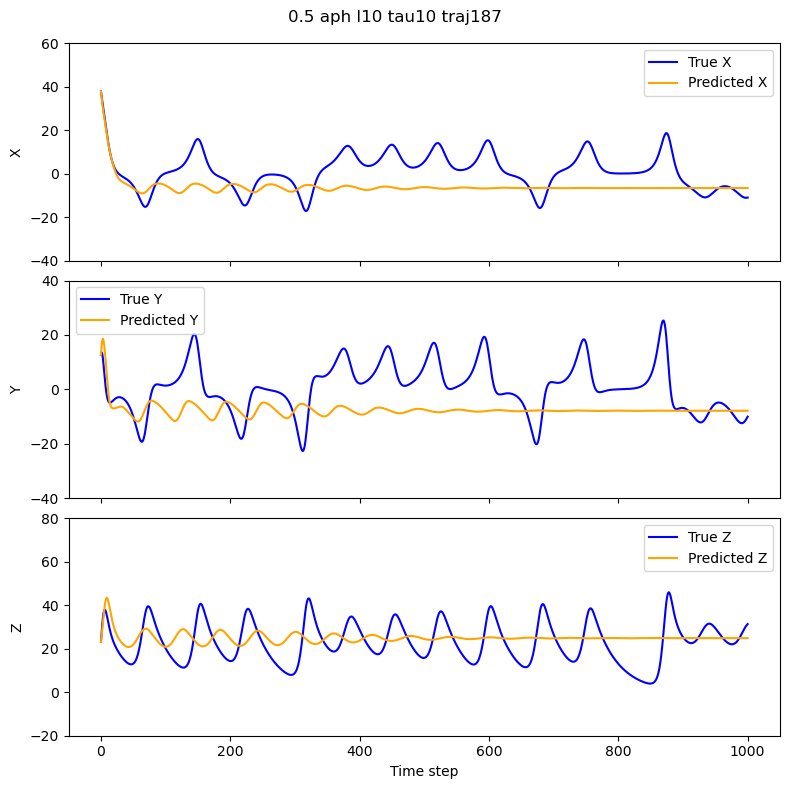

In [363]:
plot_xyz(data_05_lipsupX["y_true"][k], data_05_lipsupX["y_pred"][k], f"0.5 liplossX traj{k}")
plot_xyz(data_05_lipsupX_l10_tau10["y_true"][k], data_05_lipsupX_l10_tau10["y_pred"][k], f"0.5 liplossX l10 tau10 traj{k}")
plot_xyz(data_05_aph_l10_tau10['y_true'][k], data_05_aph_l10_tau10["y_pred"][k], f"0.5 aph l10 tau10 traj{k}")


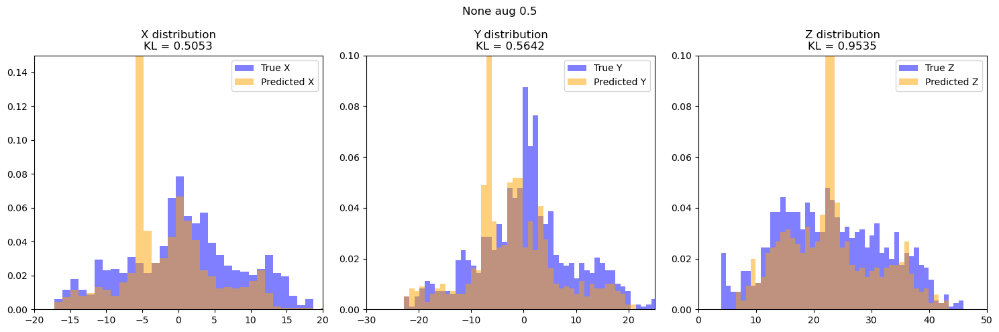

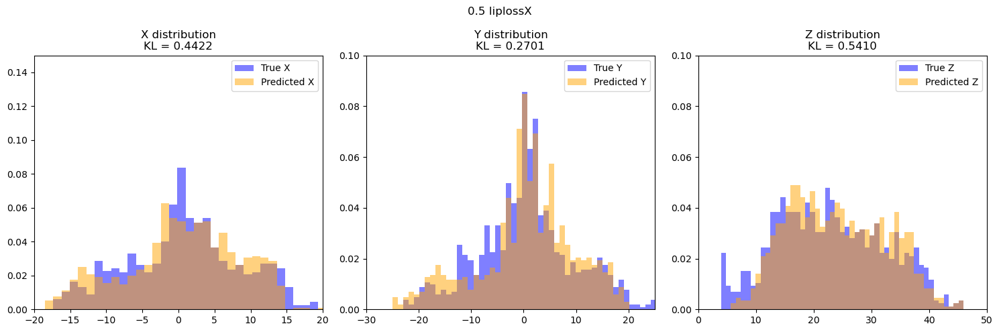

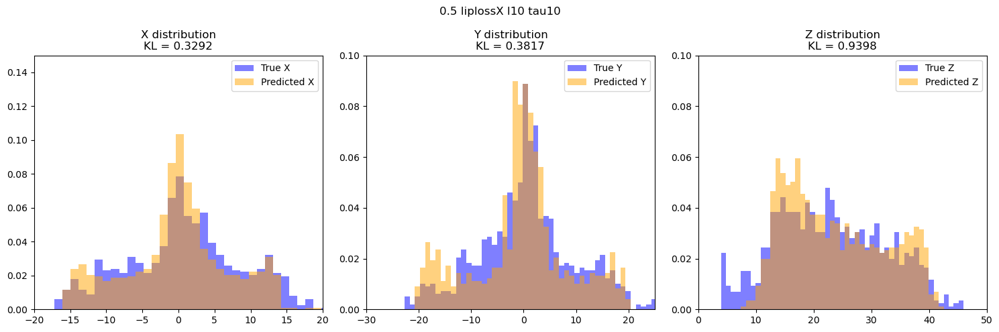

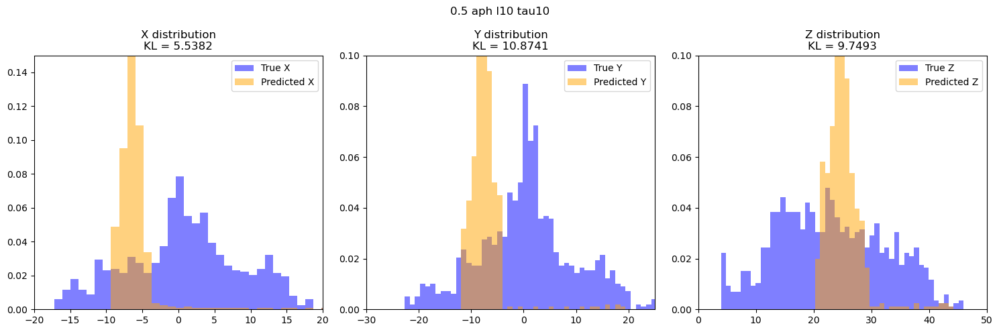

[5.538150697336441, 10.874141820925287, 9.749306914256401]

In [378]:
k=187
plot_pdf_with_kl(data_none_aug05["y_true"][k], data_none_aug05["y_pred"][k], "None aug 0.5")
plot_pdf_with_kl(data_05_lipsupX["y_true"][k], data_05_lipsupX["y_pred"][k], "0.5 liplossX")
plot_pdf_with_kl(data_05_lipsupX_l10_tau10["y_true"][k], data_05_lipsupX_l10_tau10["y_pred"][k], "0.5 liplossX l10 tau10")
plot_pdf_with_kl(data_05_aph_l10_tau10["y_true"][k], data_05_aph_l10_tau10["y_pred"][k], "0.5 aph l10 tau10")

# plot_kde_with_kl(data_05_lipsupX["y_true"][k], data_05_lipsupX["y_pred"][k], "0.5 liplossX")
# plot_kde_with_kl(data_none_aug05_nocurr["y_true"][k], data_none_aug05_nocurr["y_pred"][k], "0.5 no curr")
# plot_kde_with_kl(data_05_lipsupX_l10_tau10["y_true"][k], data_05_lipsupX_l10_tau10["y_pred"][k], "0.5 liplossX l10 tau10")
# plot_kde_with_kl(data_05_aph_l10_tau10["y_true"][k], data_05_aph_l10_tau10["y_pred"][k], "0.5 aph l10 tau10")


In [344]:
yL_10s.shape

(200200, 3)

(200200, 3) (3,)
(200200, 3) (3,)
(200200, 3) (3,)


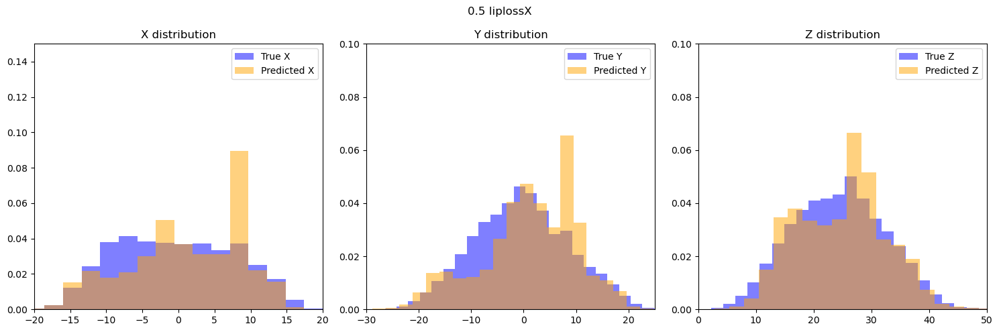

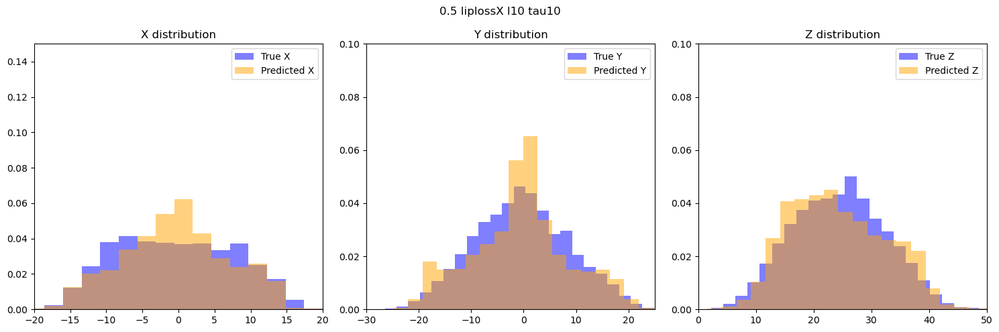

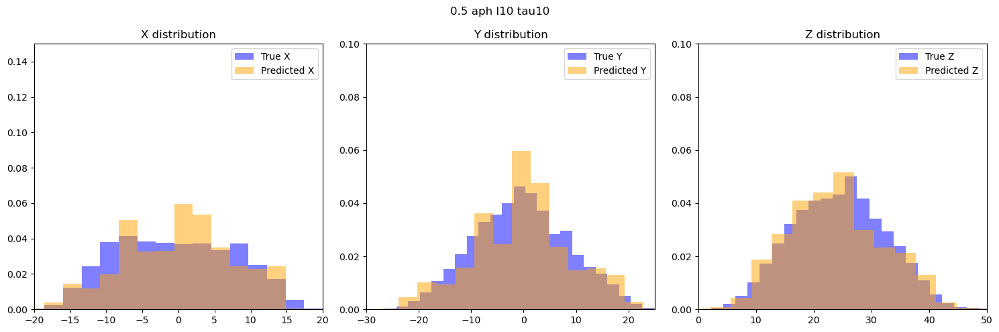

In [348]:
# for all trajectories
yL_10s_pred05lipsupX = get_yL_states10s(data_05_lipsupX, bool_true=False)
yL_10s_pred05lipsupX_l10_tau10 = get_yL_states10s(data_05_lipsupX_l10_tau10, bool_true=False)
yL_10s_pred05aph_l10_tau10 = get_yL_states10s(data_05_aph_l10_tau10, bool_true=False)
plot_pdf(yL_10s.T, yL_10s_pred05lipsupX.T, "0.5 liplossX")
plot_pdf(yL_10s.T, yL_10s_pred05lipsupX_l10_tau10.T, "0.5 liplossX l10 tau10")
plot_pdf(yL_10s.T, yL_10s_pred05aph_l10_tau10.T, "0.5 aph l10 tau10")

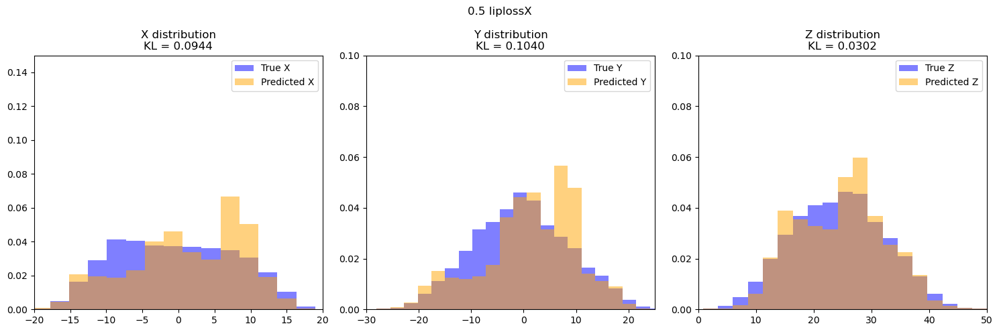

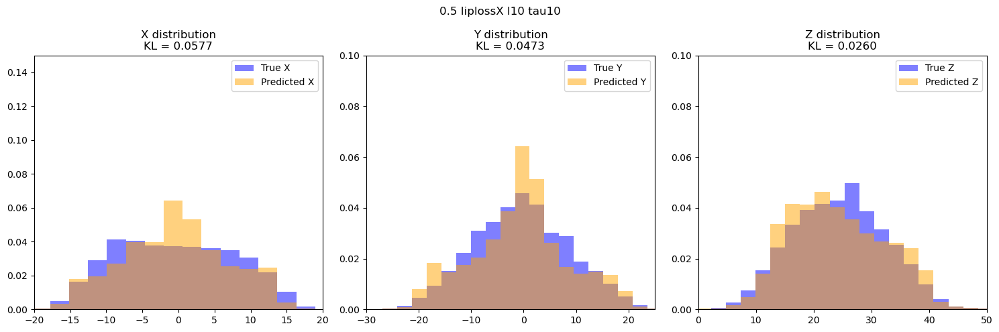

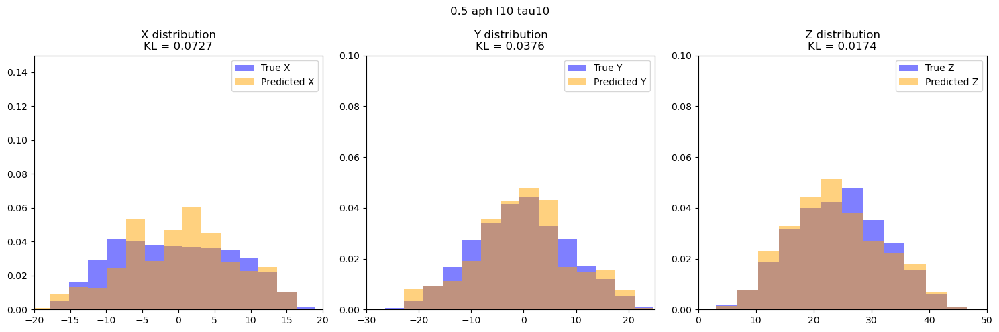

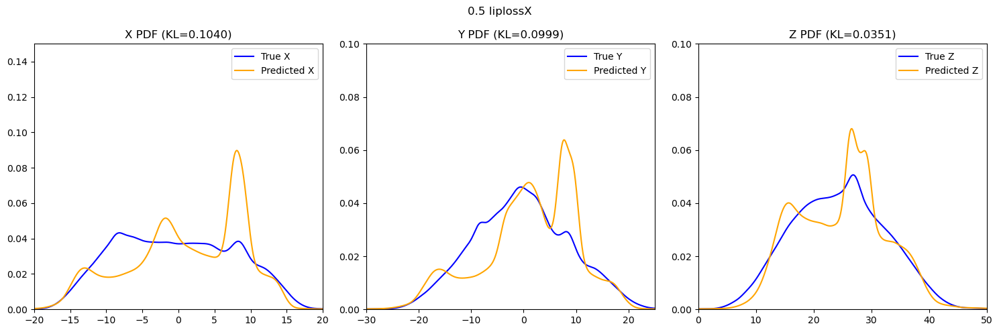

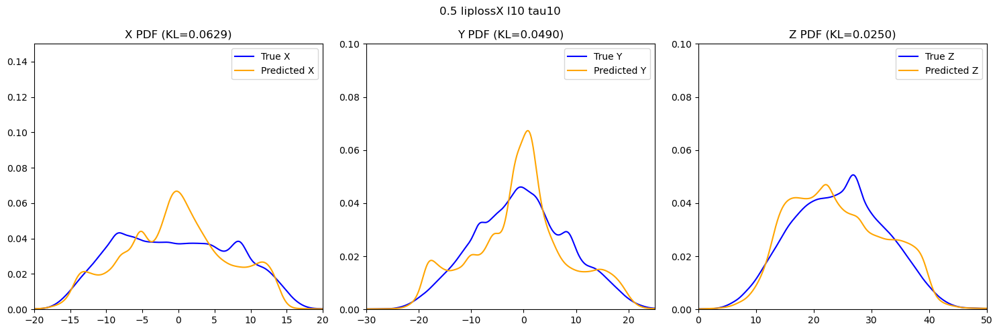

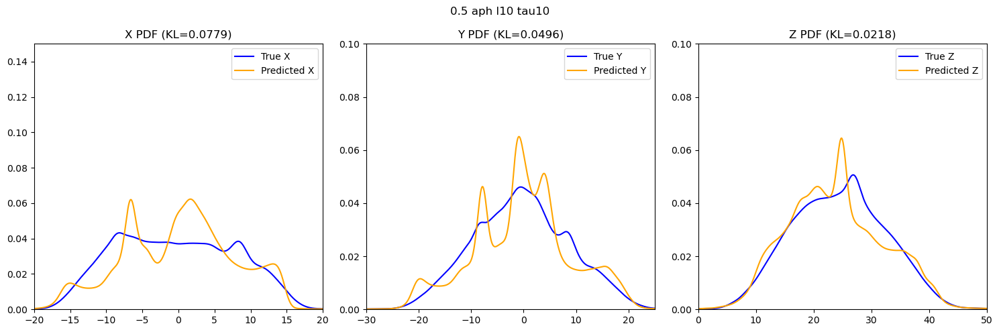

[0.07791581135078042, 0.049635623568907106, 0.02178380277692367]

In [357]:
plot_pdf_with_kl(yL_10s.T, yL_10s_pred05lipsupX.T, "0.5 liplossX")
plot_pdf_with_kl(yL_10s.T, yL_10s_pred05lipsupX_l10_tau10.T, "0.5 liplossX l10 tau10")
plot_pdf_with_kl(yL_10s.T, yL_10s_pred05aph_l10_tau10.T, "0.5 aph l10 tau10")

plot_kde_with_kl(yL_10s.T, yL_10s_pred05lipsupX.T, "0.5 liplossX")
plot_kde_with_kl(yL_10s.T, yL_10s_pred05lipsupX_l10_tau10.T, "0.5 liplossX l10 tau10")
plot_kde_with_kl(yL_10s.T, yL_10s_pred05aph_l10_tau10.T, "0.5 aph l10 tau10")

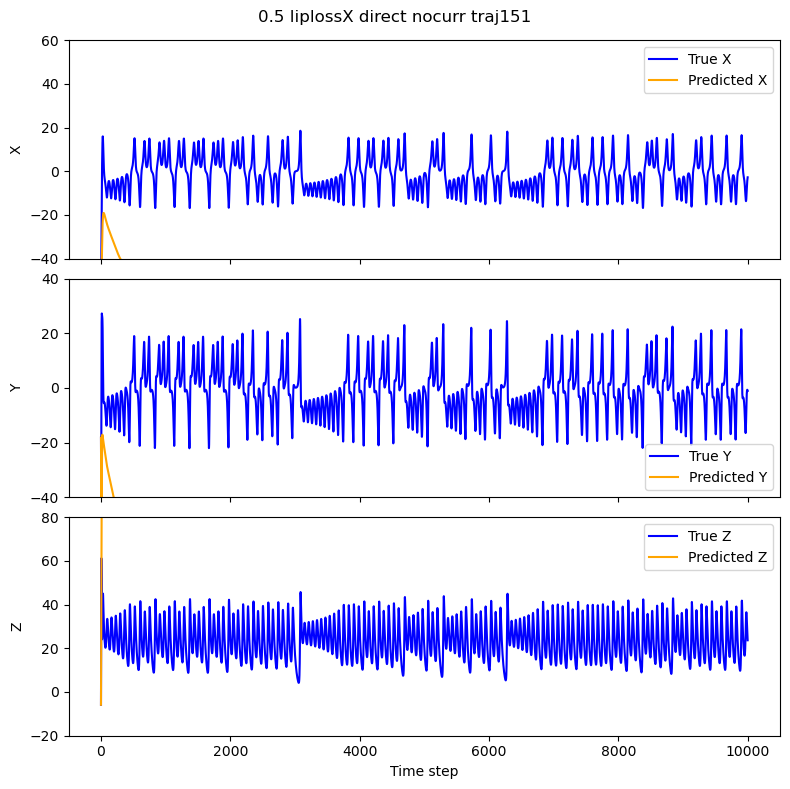

In [87]:
k = data_05_lipsupX_direct_nocurr["KL_x"].idxmax()
plot_xyz(data_05_lipsupX_direct_nocurr["y_true"][k], data_05_lipsupX_direct_nocurr["y_pred"][k], f"0.5 liplossX direct nocurr traj{k}")

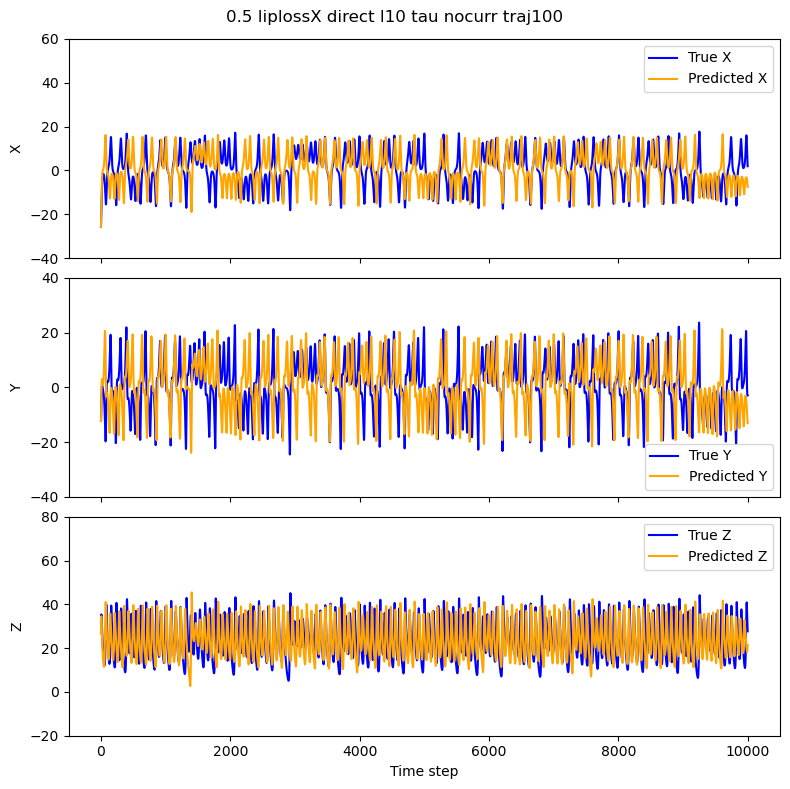

In [95]:
k = data_05_lipsupX_direct_l10000_tau1000_nocurr["KL_x"].idxmin()
plot_xyz(data_05_lipsupX_direct_l10000_tau1000_nocurr["y_true"][k], data_05_lipsupX_direct_l10000_tau1000_nocurr["y_pred"][k], f"0.5 liplossX direct l10 tau nocurr traj{k}")

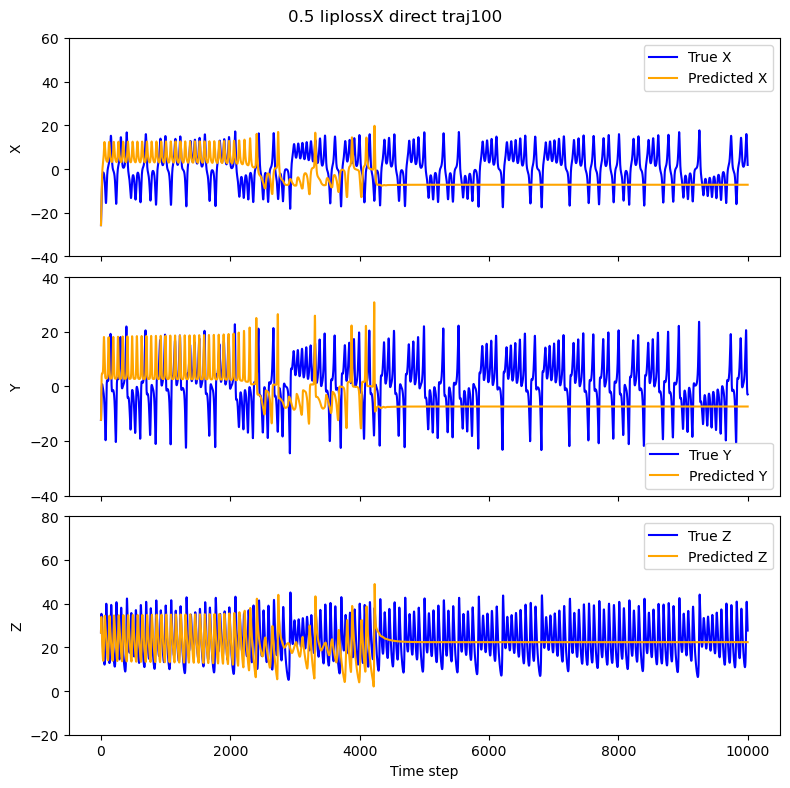

In [102]:
plot_xyz(data_05_lipsupX_direct["y_true"][k], data_05_lipsupX_direct["y_pred"][k], f"0.5 liplossX direct traj{k}")

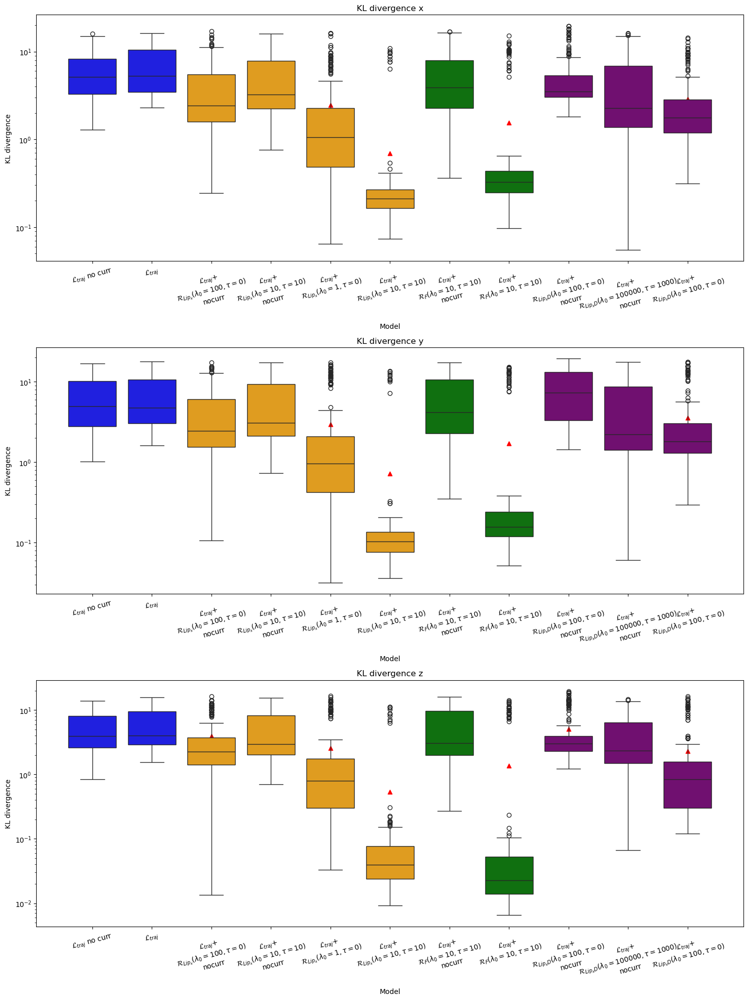

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 20))  # 3 plots en colonne

palette = {
    r'$\mathcal{L}_{traj}$ no curr': 'blue',
    r'$\mathcal{L}_{traj}$': 'blue',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=100, \tau=0)$': 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_xD}(\lambda_0=100, \tau=0)$'+'\n'+"nocurr": 'purple',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_xD}(\lambda_0=100000, \tau=1000)$'+'\n'+"nocurr": 'purple',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_xD}(\lambda_0=100, \tau=0)$': 'purple',
    #"True": '#8c564b',
    }

for i, coord in enumerate(["x", "y", "z"]):
    ax = axes[i]
    df = pd.DataFrame({
        r'$\mathcal{L}_{traj}$ no curr': data_none_aug05_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$': data_none_aug05[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': data_05_lipsupX_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': data_05_lipsupX_l10_tau10_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': data_05_lipsupX[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': data_05_lipsupX_l10_tau10[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": data_05_aph_l10_tau10_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': data_05_aph_l10_tau10[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_xD}(\lambda_0=100, \tau=0)$'+'\n'+"nocurr": data_05_lipsupX_direct_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_xD}(\lambda_0=100000, \tau=1000)$'+'\n'+"nocurr": data_05_lipsupX_direct_l10000_tau1000_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_xD}(\lambda_0=100, \tau=0)$': data_05_lipsupX_direct[f"KL_{coord}"],
    })

    sns.boxplot(data=df, palette=palette, ax=ax)

    # Ajouter la moyenne en triangle rouge
    means = [
        data_none_aug05_nocurr[f"KL_{coord}"].mean(),
        data_none_aug05[f"KL_{coord}"].mean(),
        data_05_lipsupX_nocurr[f"KL_{coord}"].mean(),
        data_05_lipsupX_l10_tau10_nocurr[f"KL_{coord}"].mean(),
        data_05_lipsupX[f"KL_{coord}"].mean(),
        data_05_lipsupX_l10_tau10[f"KL_{coord}"].mean(),
        data_05_aph_l10_tau10_nocurr[f"KL_{coord}"].mean(),
        data_05_aph_l10_tau10[f"KL_{coord}"].mean(),
        data_05_lipsupX_direct_nocurr[f"KL_{coord}"].mean(),
        data_05_lipsupX_direct_l10000_tau1000_nocurr[f"KL_{coord}"].mean(),
        data_05_lipsupX_direct[f"KL_{coord}"].mean(),
    ]

    ax.scatter(range(len(means)), means, color='red', marker='^', label='Mean')

    ax.set_title(f"KL divergence {coord}")
    ax.set_ylabel("KL divergence")
    ax.set_xlabel("Model")
    ax.set_yscale("log")
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(df.columns, rotation=15)

plt.tight_layout()
plt.show()


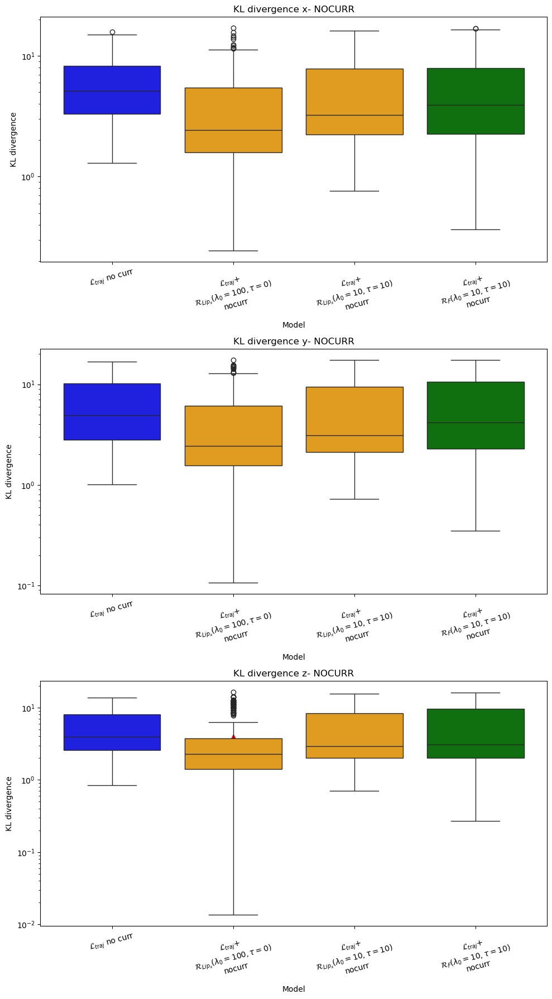

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

palette = {
    r'$\mathcal{L}_{traj}$ no curr': 'blue',
    #r'$\mathcal{L}_{traj}$': 'blue',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=100, \tau=0)$': 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": 'green',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    "True": '#8c564b'
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))  # 3 plots en colonne

for i, coord in enumerate(["x", "y", "z"]):
    ax = axes[i]
    df = pd.DataFrame({
        r'$\mathcal{L}_{traj}$ no curr': data_none_aug05_nocurr[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$': data_none_aug05[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': data_05_lipsupX_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': data_05_lipsupX_l10_tau10_nocurr[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$': data_05_lipsupX[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': data_05_lipsupX_l10_tau10[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": data_05_aph_l10_tau10_nocurr[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': data_05_aph_l10_tau10[f"KL_{coord}"]
    })

    sns.boxplot(data=df, palette=palette, ax=ax)

    # Ajouter la moyenne en triangle rouge
    means = [
        data_none_aug05_nocurr[f"KL_{coord}"].mean(),
        #data_none_aug05[f"KL_{coord}"].mean(),
        data_05_lipsupX_nocurr[f"KL_{coord}"].mean(),
        data_05_lipsupX_l10_tau10_nocurr[f"KL_{coord}"].mean(),
        #data_05_lipsupX[f"KL_{coord}"].mean(),
        #data_05_lipsupX_l10_tau10[f"KL_{coord}"].mean(),
        data_05_aph_l10_tau10_nocurr[f"KL_{coord}"].mean(),
        #data_05_aph_l10_tau10[f"KL_{coord}"].mean(),
    ]

    ax.scatter(range(len(means)), means, color='red', marker='^', label='Mean')

    ax.set_title(f"KL divergence {coord}- NOCURR")
    ax.set_ylabel("KL divergence")
    ax.set_xlabel("Model")
    ax.set_yscale("log")
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(df.columns, rotation=15)

plt.tight_layout()
plt.show()


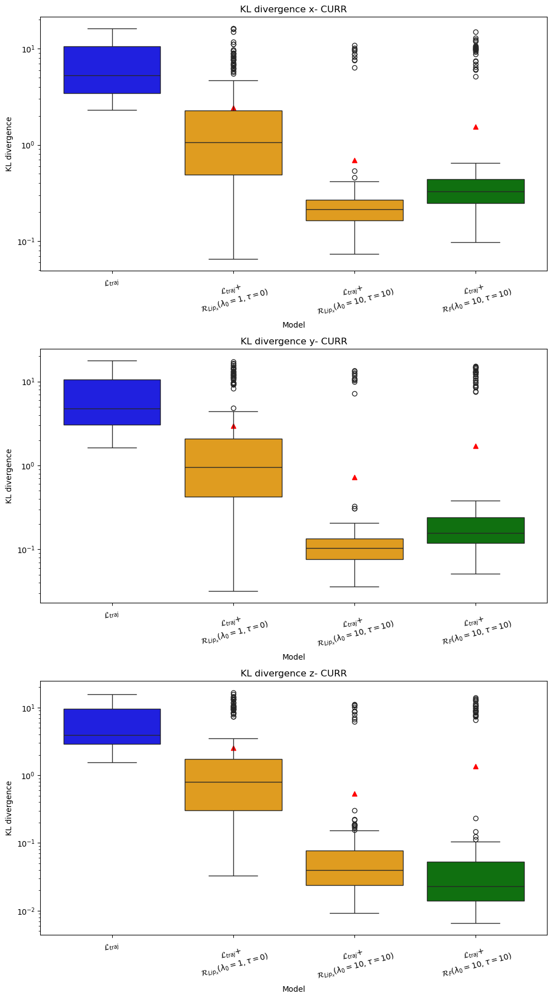

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

palette = {
    #r'$\mathcal{L}_{traj}$ no curr': 'blue',
    r'$\mathcal{L}_{traj}$': 'blue',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=1, \tau=0)$': 'green',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    "True": '#8c564b'
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))  # 3 plots en colonne

for i, coord in enumerate(["x", "y", "z"]):
    ax = axes[i]
    df = pd.DataFrame({
        #r'$\mathcal{L}_{traj}$ no curr': data_none_aug05_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$': data_none_aug05[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': data_05_lipsupX_nocurr[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': data_05_lipsupX_l10_tau10_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': data_05_lipsupX[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': data_05_lipsupX_l10_tau10[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": data_05_aph_l10_tau10_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': data_05_aph_l10_tau10[f"KL_{coord}"]
    })

    sns.boxplot(data=df, palette=palette, ax=ax)

    # Ajouter la moyenne en triangle rouge
    means = [
        #data_none_aug05_nocurr[f"KL_{coord}"].mean(),
        data_none_aug05[f"KL_{coord}"].mean(),
        #data_05_lipsupX_nocurr[f"KL_{coord}"].mean(),
        #data_05_lipsupX_l10_tau10_nocurr[f"KL_{coord}"].mean(),
        data_05_lipsupX[f"KL_{coord}"].mean(),
        data_05_lipsupX_l10_tau10[f"KL_{coord}"].mean(),
        #data_05_aph_l10_tau10_nocurr[f"KL_{coord}"].mean(),
        data_05_aph_l10_tau10[f"KL_{coord}"].mean(),
    ]

    ax.scatter(range(len(means)), means, color='red', marker='^', label='Mean')

    ax.set_title(f"KL divergence {coord}- CURR")
    ax.set_ylabel("KL divergence")
    ax.set_xlabel("Model")
    ax.set_yscale("log")
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(df.columns, rotation=15)

plt.tight_layout()
plt.show()


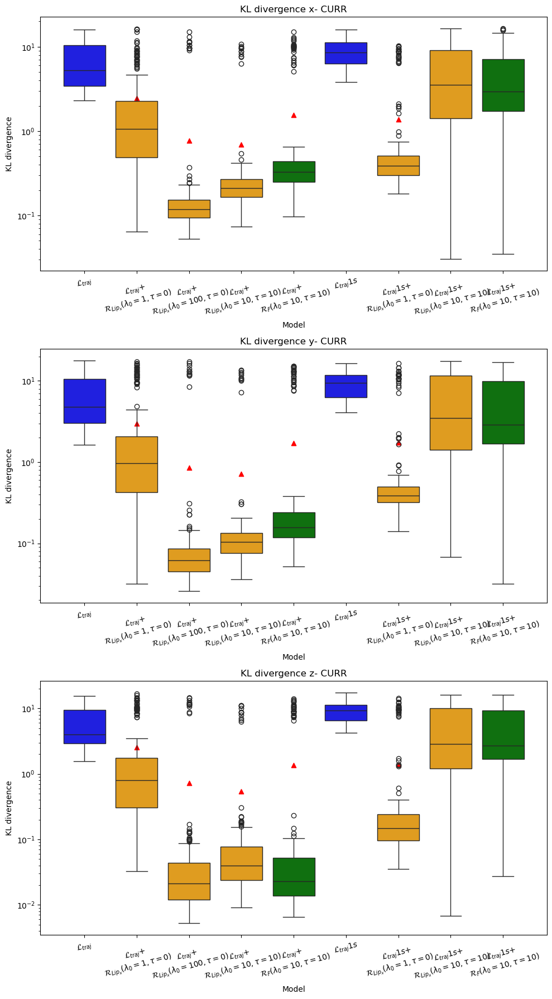

In [251]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

palette = {
    #r'$\mathcal{L}_{traj}$ no curr': 'blue',
    r'$\mathcal{L}_{traj}$': 'blue',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=1, \tau=0)$': 'green',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    r'$\mathcal{L}_{traj} 1s$': 'blue',
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    "True": '#8c564b'
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))  # 3 plots en colonne

for i, coord in enumerate(["x", "y", "z"]):
    ax = axes[i]
    df = pd.DataFrame({
        #r'$\mathcal{L}_{traj}$ no curr': data_none_aug05_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$': data_none_aug05[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': data_05_lipsupX_nocurr[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': data_05_lipsupX_l10_tau10_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': data_05_lipsupX[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$': data_05_lipsupX_l100[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': data_05_lipsupX_l10_tau10[f"KL_{coord}"],
        #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": data_05_aph_l10_tau10_nocurr[f"KL_{coord}"],
        r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': data_05_aph_l10_tau10[f"KL_{coord}"],
        r'$\mathcal{L}_{traj} 1s$': data_none_aug1[f"KL_{coord}"],
        r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': data_1_lipsupX[f"KL_{coord}"],
        r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': data_1_lipsupX_l10_tau10[f"KL_{coord}"],
        r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': data_1_aph_l10_tau10[f"KL_{coord}"],
    })

    sns.boxplot(data=df, palette=palette, ax=ax)

    # Ajouter la moyenne en triangle rouge
    means = [
        #data_none_aug05_nocurr[f"KL_{coord}"].mean(),
        data_none_aug05[f"KL_{coord}"].mean(),
        #data_05_lipsupX_nocurr[f"KL_{coord}"].mean(),
        #data_05_lipsupX_l10_tau10_nocurr[f"KL_{coord}"].mean(),
        data_05_lipsupX[f"KL_{coord}"].mean(),
        data_05_lipsupX_l100[f"KL_{coord}"].mean(),
        data_05_lipsupX_l10_tau10[f"KL_{coord}"].mean(),
        #data_05_aph_l10_tau10_nocurr[f"KL_{coord}"].mean(),
        data_05_aph_l10_tau10[f"KL_{coord}"].mean(),
        data_none_aug1[f"KL_{coord}"].mean(),
        data_1_lipsupX[f"KL_{coord}"].mean(),
        data_1_lipsupX_l10_tau10[f"KL_{coord}"].mean(),
        data_1_aph_l10_tau10[f"KL_{coord}"].mean(),
    ]

    ax.scatter(range(len(means)), means, color='red', marker='^', label='Mean')

    ax.set_title(f"KL divergence {coord}- CURR")
    ax.set_ylabel("KL divergence")
    ax.set_xlabel("Model")
    ax.set_yscale("log")
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(df.columns, rotation=15)

plt.tight_layout()
plt.show()


In [257]:
data_05_lipsupX_l100.keys()

Index(['y_true', 'y_pred', 'L2', 'L2_5s', 'L2_0.5s', 'L2_0.1s', 'x_min',
       'x_max', 'y_min', 'y_max', 'z_min', 'z_max', 'x_pdf_true', 'x_pdf_pred',
       'y_pdf_true', 'y_pdf_pred', 'z_pdf_true', 'z_pdf_pred', 'KL_x', 'KL_y',
       'KL_z'],
      dtype='object')

In [259]:
metric = "L2_0.5s"
data_05_lipsupX_l100[metric].median(), data_05_lipsupX[metric].median()

(6.449987854266839, 14.014748434137827)

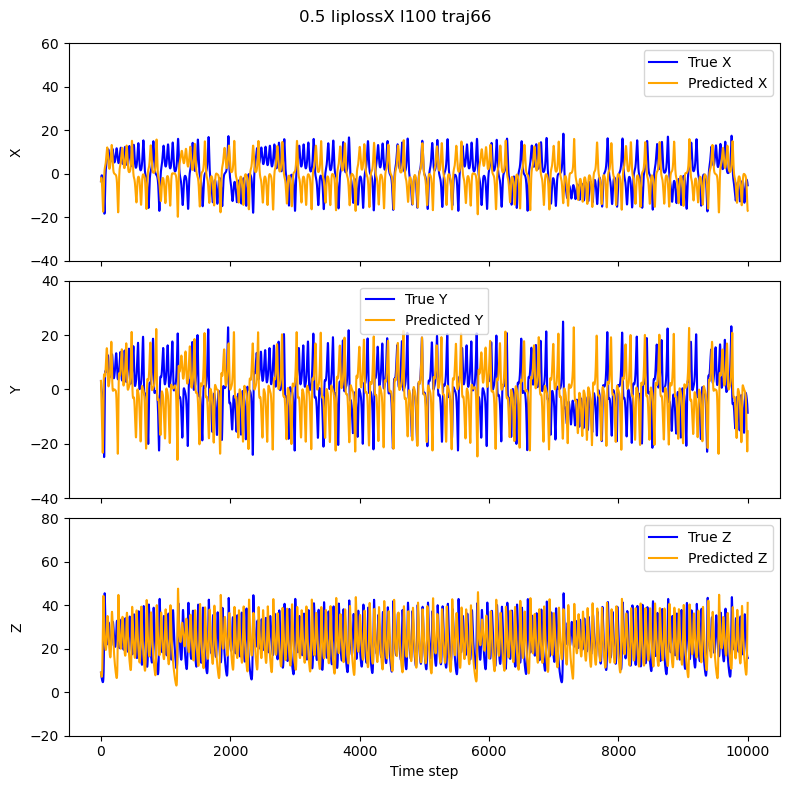

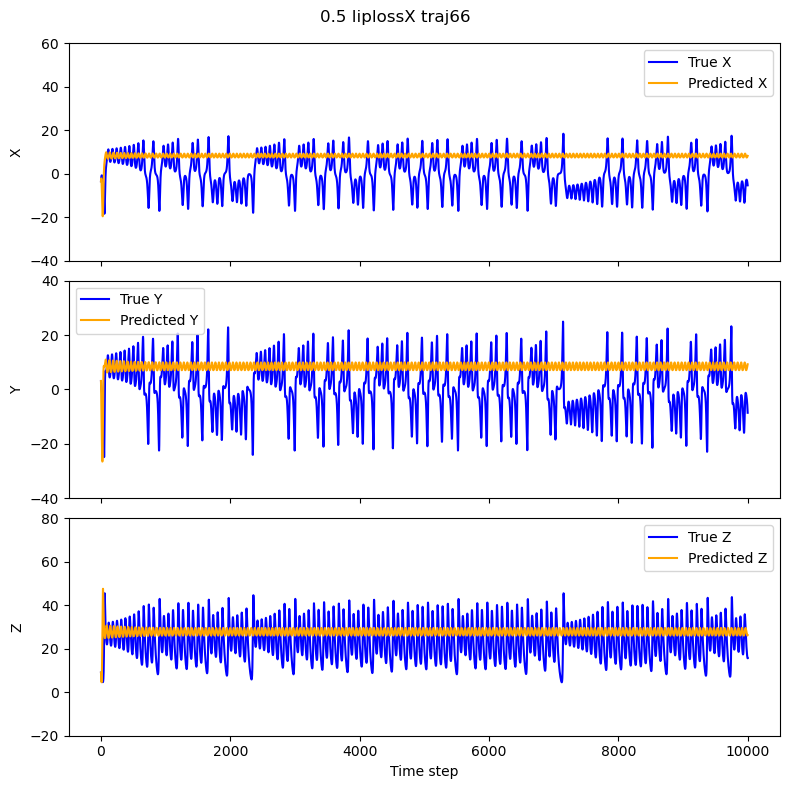

In [263]:
k = 66
plot_xyz(data_05_lipsupX_l100["y_true"][k], data_05_lipsupX_l100["y_pred"][k], f"0.5 liplossX l100 traj{k}")
plot_xyz(data_05_lipsupX["y_true"][k], data_05_lipsupX["y_pred"][k], f"0.5 liplossX traj{k}")


## jacobian norms
Lorenz63 is only locally Lipschitz but bounded because of the attractors.
Its jacobian is: 
$$J_{F lorenz}(x,y,z)=
\begin{pmatrix}
    -\sigma & \sigma & 0 \\
    \rho-z & -1 & -x \\
    y & x & -8/3                  
\end{pmatrix}
$$
Using Frobenius norm to get a Lipschitz constant: 



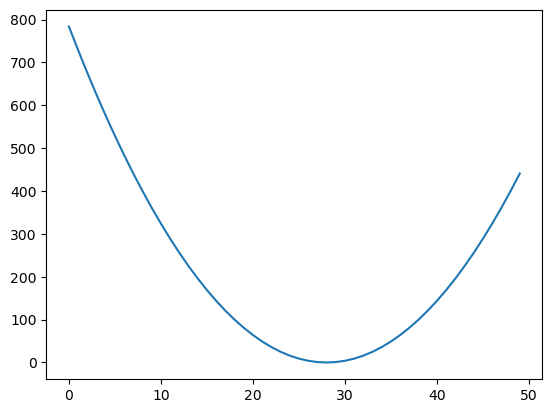

In [456]:
plt.plot(np.arange(0,50), (28-np.arange(0,50))**2)

In [38]:
xmax = yL_10s[:,0].max()
ymax = yL_10s[:,1].max()
zmin = yL_10s[:,2].min()
sigma, rho, beta = 10, 28, 8/3

In [39]:
L_frob_lorenz = np.sqrt(sigma**2+sigma**2+ (rho-zmin)**2+1+xmax**2+ymax**2+ xmax**2+ beta**2)
L_frob_lorenz

126.05402093948123

107.51653347070439

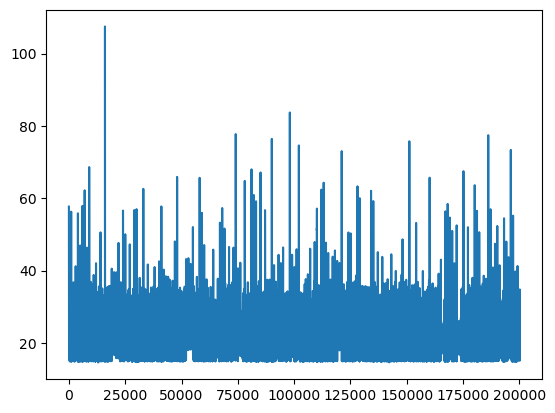

In [40]:
L_effective = np.sqrt(sigma**2+sigma**2+ (rho-yL_10s[:,2])**2+1+yL_10s[:,0]**2+yL_10s[:,1]**2+ yL_10s[:,0]**2+ beta**2)
plt.plot(L_effective, label="Effective Lipschitz")
L_effective.max()

In [265]:
lip_data_05_lipsupX_l100 = compute_jacobian_test(model_lipsupX05_l100, yL_10s)

In [142]:
# over 10s
lip_data_none_aug1 = compute_jacobian_test(model_none_aug1, yL_10s)
lip_data_none_aug05 = compute_jacobian_test(model_none_aug05, yL_10s)
lip_data_none_aug05_nocurr = compute_jacobian_test(model_none_aug05_nocurr, yL_10s)
lip_data_none_aug01 = compute_jacobian_test(model_none_aug01, yL_10s)
lip_data_05_lipsupX = compute_jacobian_test(model_lipsupX05, yL_10s)
lip_data_1_lipsupX = compute_jacobian_test(model_lipsupX1, yL_10s)
lip_data_05_lipsupX_l10_tau10 = compute_jacobian_test(model_lipsupX05_l10_tau10, yL_10s)
lip_data_05_aph_l10_tau10 = compute_jacobian_test(model_aph_05_l10_tau10, yL_10s)
lip_data_1_lipsupX_l10_tau10 = compute_jacobian_test(model_lipsupX1_l10_tau10, yL_10s)
lip_data_1_aph_l10_tau10 = compute_jacobian_test(model_aph_1_l10_tau10, yL_10s)

# nocurr
lip_data_05_lipsupX_nocurr = compute_jacobian_test(model_lipsupX05_nocurr, yL_10s)
lip_data_05_aph_l10_tau10_nocurr = compute_jacobian_test(model_aph_05_l10_tau10_nocurr, yL_10s)

In [65]:
lip_data_05_lipsupX_l10_tau10_nocurr = compute_jacobian_test(model_lipsupX05_l10_tau10_nocurr, yL_10s)

In [42]:
# true lip data
def Fy_lorenz(x):
    """Lorenz system dynamics."""
    sigma = 10.0
    beta = 8.0 / 3.0
    rho = 28.0
    dxdt = sigma * (x[1] - x[0])
    dydt = x[0] * (rho - x[2]) - x[1]
    dzdt = x[0] * x[1] - beta * x[2]
    return jnp.array([dxdt, dydt, dzdt])

lip_data_lorenz_true = compute_jacobian_test(Fy_lorenz, yL_10s, bool_true=True)

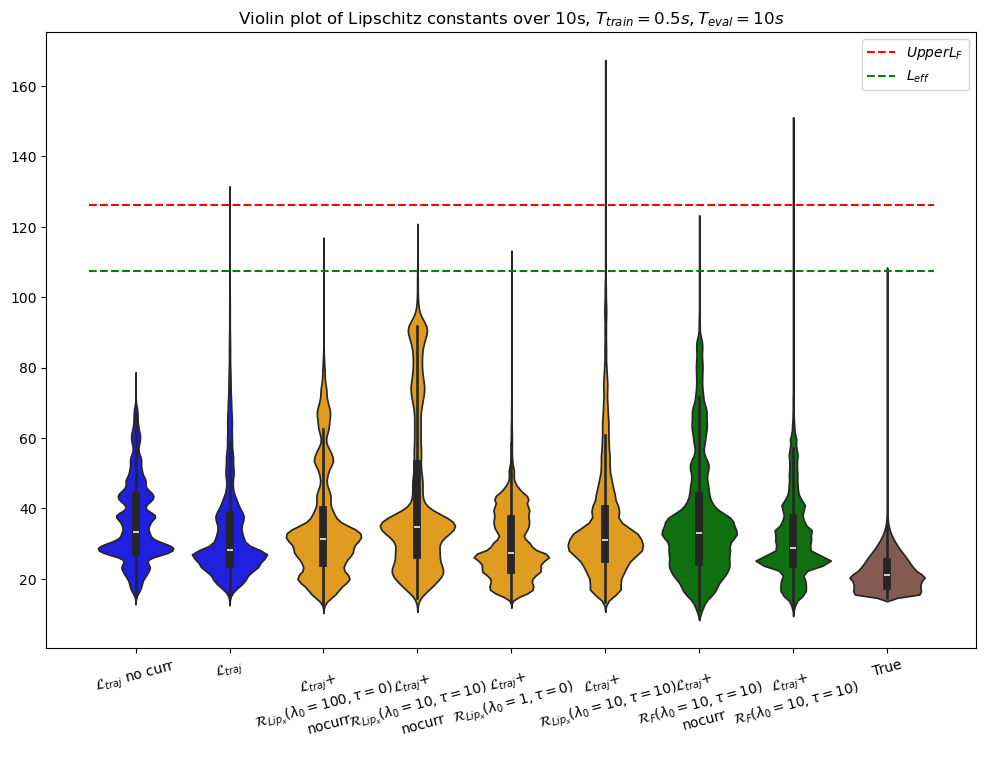

In [105]:
plt.figure(figsize=(12, 8))
palette = {
    r'$\mathcal{L}_{traj}$ no curr': 'blue',
    r'$\mathcal{L}_{traj}$': 'blue',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=100, \tau=0)$': 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    "True": '#8c564b'
}
sns.violinplot(pd.DataFrame({
    r'$\mathcal{L}_{traj}$ no curr': lip_data_none_aug05_nocurr,
    r'$\mathcal{L}_{traj}$': lip_data_none_aug05,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': lip_data_05_lipsupX_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': lip_data_05_lipsupX_l10_tau10_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': lip_data_05_lipsupX,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': lip_data_05_lipsupX_l10_tau10,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": lip_data_05_aph_l10_tau10_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': lip_data_05_aph_l10_tau10,
    # "1.0s": lip_data_none_aug1,
    # "1.0s liploss(X)": lip_data_1_lipsupX,
    "True": lip_data_lorenz_true,
}),
#alpha=0.5,
palette=palette)
plt.title(r"Violin plot of Lipschitz constants over 10s, $T_{train}=0.5s, T_{eval}=10s$")
plt.hlines(L_frob_lorenz, xmin=-0.5, xmax=8.5, color='red', linestyle='--', label=r"$Upper L_F$")
plt.hlines(L_effective.max(), xmin=-0.5, xmax=8.5, color='green', linestyle='--', label=r"$L_{eff}$") 
plt.xticks(rotation=15)
plt.legend()
plt.show()

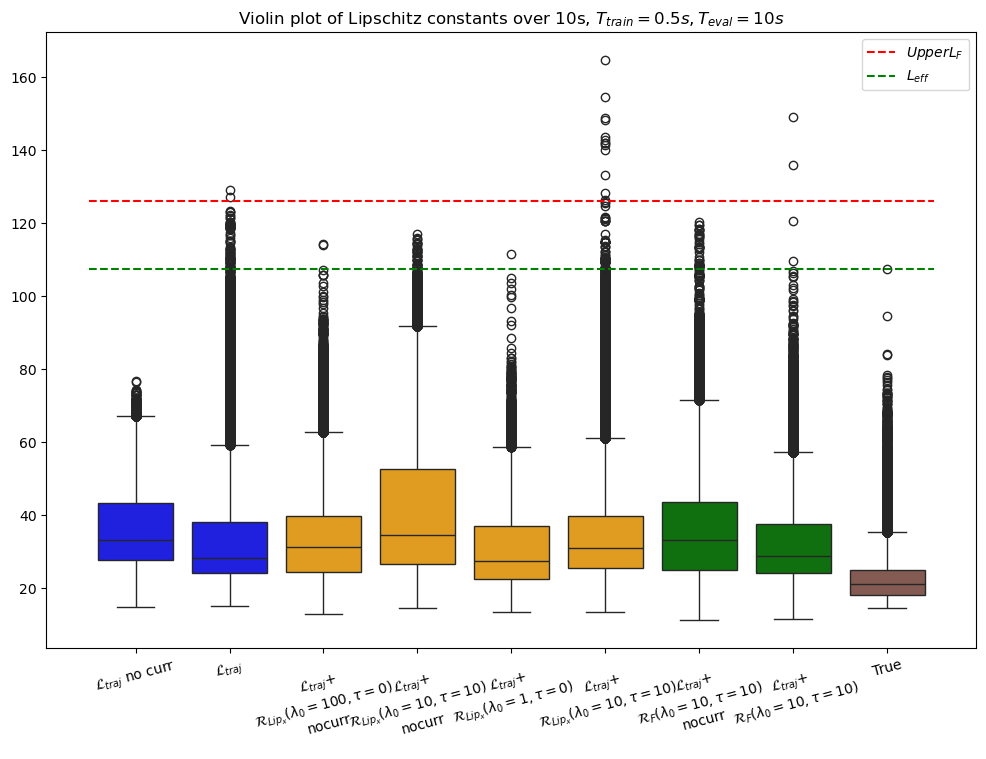

In [106]:
plt.figure(figsize=(12, 8))
palette = {
    r'$\mathcal{L}_{traj}$ no curr': 'blue',
    r'$\mathcal{L}_{traj}$': 'blue',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=100, \tau=0)$': 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    "True": '#8c564b'
}
sns.boxplot(pd.DataFrame({
    r'$\mathcal{L}_{traj}$ no curr': lip_data_none_aug05_nocurr,
    r'$\mathcal{L}_{traj}$': lip_data_none_aug05,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': lip_data_05_lipsupX_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': lip_data_05_lipsupX_l10_tau10_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': lip_data_05_lipsupX,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': lip_data_05_lipsupX_l10_tau10,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": lip_data_05_aph_l10_tau10_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': lip_data_05_aph_l10_tau10,
    # "1.0s": lip_data_none_aug1,
    # "1.0s liploss(X)": lip_data_1_lipsupX,
    "True": lip_data_lorenz_true,
}),
#alpha=0.5,
palette=palette)
plt.title(r"Violin plot of Lipschitz constants over 10s, $T_{train}=0.5s, T_{eval}=10s$")
plt.hlines(L_frob_lorenz, xmin=-0.5, xmax=8.5, color='red', linestyle='--', label=r"$Upper L_F$")
plt.hlines(L_effective.max(), xmin=-0.5, xmax=8.5, color='green', linestyle='--', label=r"$L_{eff}$") 
plt.xticks(rotation=15)
plt.legend()
plt.show()

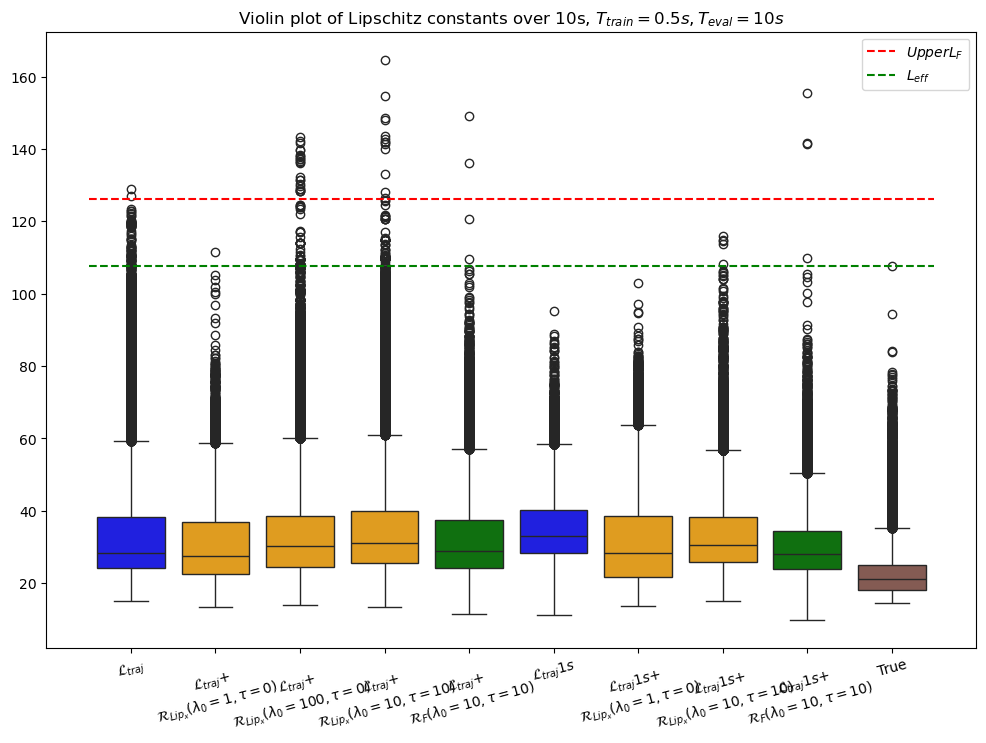

In [266]:
plt.figure(figsize=(12, 8))
palette = {
    #r'$\mathcal{L}_{traj}$ no curr': 'blue',
    r'$\mathcal{L}_{traj}$': 'blue',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=100, \tau=0)$': 'green',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    r'$\mathcal{L}_{traj} 1s$': 'blue',
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    "True": '#8c564b'
}
sns.boxplot(pd.DataFrame({
    #r'$\mathcal{L}_{traj}$ no curr': lip_data_none_aug05_nocurr,
    r'$\mathcal{L}_{traj}$': lip_data_none_aug05,
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': lip_data_05_lipsupX_nocurr,
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': lip_data_05_lipsupX_l10_tau10_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': lip_data_05_lipsupX,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$': lip_data_05_lipsupX_l100,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': lip_data_05_lipsupX_l10_tau10,
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": lip_data_05_aph_l10_tau10_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': lip_data_05_aph_l10_tau10,
    r'$\mathcal{L}_{traj} 1s$': lip_data_none_aug1,
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': lip_data_1_lipsupX,
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': lip_data_1_lipsupX_l10_tau10,
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': lip_data_1_aph_l10_tau10,
    # "1.0s": lip_data_none_aug1,
    # "1.0s liploss(X)": lip_data_1_lipsupX,
    "True": lip_data_lorenz_true,
}),
#alpha=0.5,
palette=palette)
plt.title(r"Violin plot of Lipschitz constants over 10s, $T_{train}=0.5s, T_{eval}=10s$")
plt.hlines(L_frob_lorenz, xmin=-0.5, xmax=9.5, color='red', linestyle='--', label=r"$Upper L_F$")
plt.hlines(L_effective.max(), xmin=-0.5, xmax=9.5, color='green', linestyle='--', label=r"$L_{eff}$") 
plt.xticks(rotation=15)
plt.legend()
plt.show()

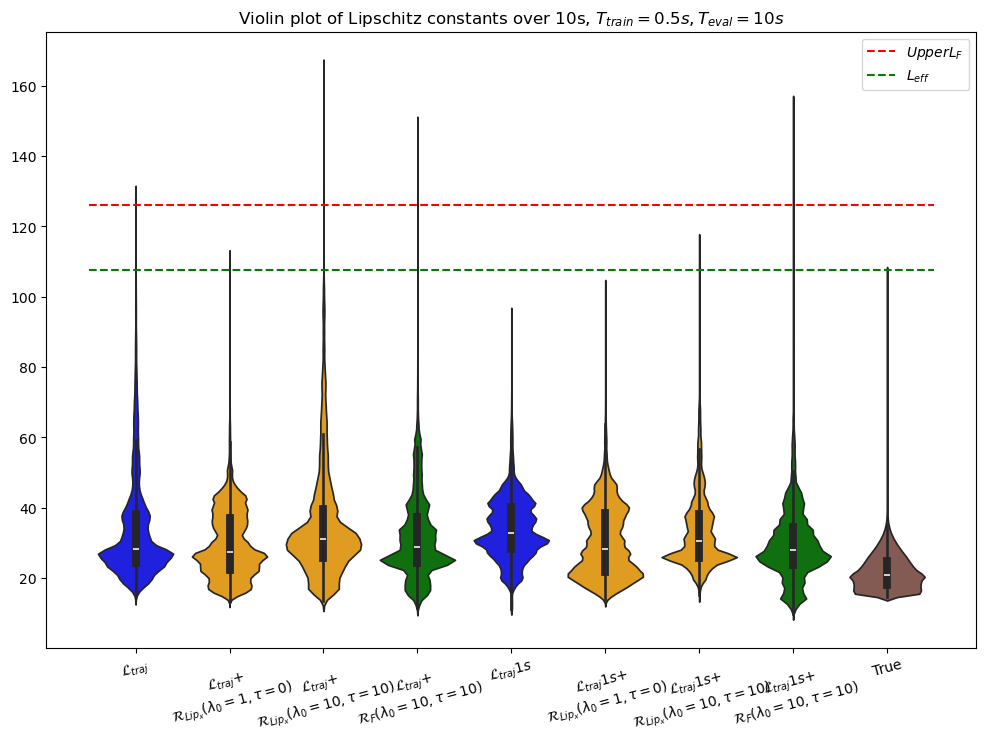

In [144]:
plt.figure(figsize=(12, 8))
palette = {
    #r'$\mathcal{L}_{traj}$ no curr': 'blue',
    r'$\mathcal{L}_{traj}$': 'blue',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=100, \tau=0)$': 'green',
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": 'green',
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    r'$\mathcal{L}_{traj} 1s$': 'blue',
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': 'orange',
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': 'orange',
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': 'green',
    "True": '#8c564b'
}
sns.violinplot(pd.DataFrame({
    #r'$\mathcal{L}_{traj}$ no curr': lip_data_none_aug05_nocurr,
    r'$\mathcal{L}_{traj}$': lip_data_none_aug05,
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=100, \tau=0)$'+'\n'+'nocurr': lip_data_05_lipsupX_nocurr,
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$'+'\n'+'nocurr': lip_data_05_lipsupX_l10_tau10_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': lip_data_05_lipsupX,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': lip_data_05_lipsupX_l10_tau10,
    #r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$'+'\n'+"nocurr": lip_data_05_aph_l10_tau10_nocurr,
    r'$\mathcal{L}_{traj}$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': lip_data_05_aph_l10_tau10,
    r'$\mathcal{L}_{traj} 1s$': lip_data_none_aug1,
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=1, \tau=0)$': lip_data_1_lipsupX,
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_{Lip_x}(\lambda_0=10, \tau=10)$': lip_data_1_lipsupX_l10_tau10,
    r'$\mathcal{L}_{traj} 1s$+'+'\n'+r'$\mathcal{R}_F(\lambda_0=10, \tau=10)$': lip_data_1_aph_l10_tau10,
    # "1.0s": lip_data_none_aug1,
    # "1.0s liploss(X)": lip_data_1_lipsupX,
    "True": lip_data_lorenz_true,
}),
#alpha=0.5,
palette=palette)
plt.title(r"Violin plot of Lipschitz constants over 10s, $T_{train}=0.5s, T_{eval}=10s$")
plt.hlines(L_frob_lorenz, xmin=-0.5, xmax=8.5, color='red', linestyle='--', label=r"$Upper L_F$")
plt.hlines(L_effective.max(), xmin=-0.5, xmax=8.5, color='green', linestyle='--', label=r"$L_{eff}$") 
plt.xticks(rotation=15)
plt.legend()
plt.show()

In [270]:
model_none_aug05(jnp.array([1.,2.,3.]))

Array([[ 1.       ,  1.0792826,  1.2306026, ..., -5.157468 , -5.157468 ,
        -5.157468 ],
       [ 2.       ,  3.0828857,  4.198916 , ..., -6.810112 , -6.810112 ,
        -6.810112 ],
       [ 3.       ,  2.6761832,  2.414254 , ..., 22.82364  , 22.82364  ,
        22.82364  ]], dtype=float32)